**Table of contents**<a id='toc0_'></a>    
- [DATASET ACCESS, CLEANING AND PREPROCESSING](#toc1_)    
  - [Import data](#toc1_1_)    
  - [Data Cleaning](#toc1_2_)    
    - [GC Cleaning](#toc1_2_1_)    
      - [Create GC Unique Table](#toc1_2_1_1_)    
    - [Clients Cleaning](#toc1_2_2_)    
      - [Age Cleaning](#toc1_2_2_1_)    
      - [Other Metrics](#toc1_2_2_2_)    
      - [OTs](#toc1_2_2_3_)    
    - [Call Data Cleaning](#toc1_2_3_)    
    - [Merging Datasets](#toc1_2_4_)    
  - [Data Preparation of reduced df](#toc1_3_)    
    - [Create dependent variables](#toc1_3_1_)    
    - [Feature Engineering](#toc1_3_2_)    
      - [Calls in the last 7 days](#toc1_3_2_1_)    
      - [Days since last call (Client)](#toc1_3_2_2_)    
      - [Tipification level 2](#toc1_3_2_3_)    
      - [Days since last call (GC - Group Key)](#toc1_3_2_4_)    
      - [Weekday or Weekend](#toc1_3_2_5_)    
      - [Time of day](#toc1_3_2_6_)    
      - [Topic Classification Entry at FT - PREVIOUS CALL](#toc1_3_2_7_)    
    - [Create Baseline Prediction Columns (Rule-Based Average Targets per Cat)](#toc1_3_3_)    
- [ITERATIVE LEARNING REFINEMENT](#toc2_)    
    - [Build Lable](#toc2_1_1_)    
    - [Train Simpler Model](#toc2_1_2_)    
    - [Measure Uncertainties](#toc2_1_3_)    
    - [Visualize](#toc2_1_4_)    
    - [Finalize working dataset](#toc2_1_5_)    
    - [Encode Categorical Variables](#toc2_1_6_)    
- [E2E MODELS](#toc3_)    
  - [Linear Regression](#toc3_1_)    
  - [XGBoost](#toc3_2_)    
  - [Neural Network](#toc3_3_)    
- [DEMO](#toc4_)    
- [SIMULATION](#toc5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[DATASET ACCESS, CLEANING AND PREPROCESSING](#toc0_)

## <a id='toc1_1_'></a>[Import data](#toc0_)

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import getpass


In [ ]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Avoid truncation of wide output
pd.set_option('display.max_colwidth', None)  # Avoid truncation of column content

In [ ]:
# Connection details
host = "172.20.20.4"
port = "5432"
database = "nos"
user = input("Username: ")
password = getpass.getpass("Insert Password:")

In [ ]:
# Create a SQLAlchemy engine
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}')

list_1 = [
    'masterdataclients_jan_may',
    'masterdataclients_jun_oct',
    'mastercalls_jan_feb',
    'mastercalls_mar_apr',
    'mastercalls_may_jul',
    'mastercalls_aug_oct',
    'masterdatagcs'
    ]
# Function to fetch data from a specific table
def fetch_table(table_name):
    query = f"SELECT * FROM nos2425.{table_name}  ;"
    return pd.read_sql_query(query, engine)

# Loop through the list, fetch each table, and assign it to a variable with the table name
for table_name in list_1:
    df = fetch_table(table_name)  # Fetch the table data

    # Dynamically create a variable with the table name to store the data
    globals()[table_name] = df


In [ ]:
client_df = pd.concat([masterdataclients_jan_may, masterdataclients_jun_oct], ignore_index=True)
call_df = pd.concat([mastercalls_jan_feb, mastercalls_mar_apr, mastercalls_may_jul, mastercalls_aug_oct], ignore_index=True)


## <a id='toc1_2_'></a>[Data Cleaning](#toc0_)

### <a id='toc1_2_1_'></a>[GC Cleaning](#toc0_)

In [ ]:
masterdatagcs.head()

,Column1,RESOURCE_KEY,RESOURCE_ID,LEG_START_TIME,COUNT_CALLS,MEAN_RPC,MEDIAN_RPC,MEAN_FTR,MEAN_TMC,MEDIAN_TMC,TOTAL_OTS,OTS_BY_CALL,COUNT_CALLS_IF,MEAN_RPC_IF,MEDIAN_RPC_IF,MEAN_FTR_IF,MEAN_TMC_IF,MEDIAN_TMC_IF,TOTAL_OTS_IF,OTS_BY_CALL_IF,COUNT_CALLS_OTHER,MEAN_RPC_OTHER,MEDIAN_RPC_OTHER,MEAN_FTR_OTHER,MEAN_TMC_OTHER,MEDIAN_TMC_OTHER,TOTAL_OTS_OTHER,OTS_BY_CALL_OTHER,COUNT_CALLS_VF,MEAN_RPC_VF,MEDIAN_RPC_VF,MEAN_FTR_VF,MEAN_TMC_VF,MEDIAN_TMC_VF,TOTAL_OTS_VF,OTS_BY_CALL_VF,COUNT_CALLS_TV,MEAN_RPC_TV,MEDIAN_RPC_TV,MEAN_FTR_TV,MEAN_TMC_TV,MEDIAN_TMC_TV,TOTAL_OTS_TV,OTS_BY_CALL_TV,COUNT_CALLS_MOVEL,MEAN_RPC_MOVEL,MEDIAN_RPC_MOVEL,MEAN_FTR_MOVEL,MEAN_TMC_MOVEL,MEDIAN_TMC_MOVEL,TOTAL_OTS_MOVEL,OTS_BY_CALL_MOVEL,COUNT_LEGS_14_DAYS,MEAN_DURATION_14_DAYS,MEDIAN_DURATION_14_DAYS,MEAN_RPC_14_DAYS,MEDIAN_RPC_14_DAYS,MEAN_FTR_14_DAYS,TOTAL_OTS_14_DAYS,COUNT_LEGS_30_DAYS,MEAN_DURATION_30_DAYS,MEDIAN_DURATION_30_DAYS,MEAN_RPC_30_DAYS,MEDIAN_RPC_30_DAYS,MEAN_FTR_30_DAYS,TOTAL_OTS_30_DAYS,COUNT_LEGS_IF_14_DAYS,MEAN_DURATION_IF_14_DAYS,MEDIAN_DURATION_IF_14_DAYS,MEAN_RPC_IF_14_DAYS,MEDIAN_RPC_IF_14_DAYS,MEAN_FTR_IF_14_DAYS,TOTAL_OTS_IF_14_DAYS,COUNT_LEGS_MOVEL_14_DAYS,MEAN_DURATION_MOVEL_14_DAYS,MEDIAN_DURATION_MOVEL_14_DAYS,MEAN_RPC_MOVEL_14_DAYS,MEDIAN_RPC_MOVEL_14_DAYS,MEAN_FTR_MOVEL_14_DAYS,TOTAL_OTS_MOVEL_14_DAYS,COUNT_LEGS_TV_14_DAYS,MEAN_DURATION_TV_14_DAYS,MEDIAN_DURATION_TV_14_DAYS,MEAN_RPC_TV_14_DAYS,MEDIAN_RPC_TV_14_DAYS,MEAN_FTR_TV_14_DAYS,TOTAL_OTS_TV_14_DAYS,COUNT_LEGS_VF_14_DAYS,MEAN_DURATION_VF_14_DAYS,MEDIAN_DURATION_VF_14_DAYS,MEAN_RPC_VF_14_DAYS,MEDIAN_RPC_VF_14_DAYS,MEAN_FTR_VF_14_DAYS,TOTAL_OTS_VF_14_DAYS,COUNT_LEGS_IF_30_DAYS,MEAN_DURATION_IF_30_DAYS,MEDIAN_DURATION_IF_30_DAYS,MEAN_RPC_IF_30_DAYS,MEDIAN_RPC_IF_30_DAYS,MEAN_FTR_IF_30_DAYS,TOTAL_OTS_IF_30_DAYS,COUNT_LEGS_MOVEL_30_DAYS,MEAN_DURATION_MOVEL_30_DAYS,MEDIAN_DURATION_MOVEL_30_DAYS,MEAN_RPC_MOVEL_30_DAYS,MEDIAN_RPC_MOVEL_30_DAYS,MEAN_FTR_MOVEL_30_DAYS,TOTAL_OTS_MOVEL_30_DAYS,COUNT_LEGS_TV_30_DAYS,MEAN_DURATION_TV_30_DAYS,MEDIAN_DURATION_TV_30_DAYS,MEAN_RPC_TV_30_DAYS,MEDIAN_RPC_TV_30_DAYS,MEAN_FTR_TV_30_DAYS,TOTAL_OTS_TV_30_DAYS,COUNT_LEGS_VF_30_DAYS,MEAN_DURATION_VF_30_DAYS,MEDIAN_DURATION_VF_30_DAYS,MEAN_RPC_VF_30_DAYS,MEDIAN_RPC_VF_30_DAYS,MEAN_FTR_VF_30_DAYS,TOTAL_OTS_VF_30_DAYS,MEAN_HANDOVERS_14_DAYS,MEDIAN_HANDOVERS_14_DAYS,MEAN_HANDOVERS_30_DAYS,MEDIAN_HANDOVERS_30_DAYS,MEAN_HANDOVERS_IF_14_DAYS,MEDIAN_HANDOVERS_IF_14_DAYS,MEAN_HANDOVERS_MOVEL_14_DAYS,MEDIAN_HANDOVERS_MOVEL_14_DAYS,MEAN_HANDOVERS_TV_14_DAYS,MEDIAN_HANDOVERS_TV_14_DAYS,MEAN_HANDOVERS_VF_14_DAYS,MEDIAN_HANDOVERS_VF_14_DAYS,MEAN_HANDOVERS_IF_30_DAYS,MEDIAN_HANDOVERS_IF_30_DAYS,MEAN_HANDOVERS_MOVEL_30_DAYS,MEDIAN_HANDOVERS_MOVEL_30_DAYS,MEAN_HANDOVERS_TV_30_DAYS,MEDIAN_HANDOVERS_TV_30_DAYS,MEAN_HANDOVERS_VF_30_DAYS,MEDIAN_HANDOVERS_VF_30_DAYS
0,0,11741170013,1174117,2024-01-02,3479,0.681524,1.0,0.164038,591.8416,481.0,566,0.16269,1079.0,0.648919,1.0,0.173,643.4541,552.0,271.0,0.251158,1067.0,0.652124,0.5,0.134144,431.71884,325.0,53.0,0.049672,138.0,0.833575,1.0,0.128019,722.7246,594.0,26.0,0.188406,1005.0,0.755046,1.0,0.177197,705.3393,601.0,215.0,0.21393,190.0,0.532456,0.666667,0.157018,502.54736,399.5,1.0,0.005263,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,11741170013,1174117,2024-01-03,3479,0.681524,1.0,0.164038,591.8416,481.0,566,0.16269,1079.0,0.648919,1.0,0.173,643.4541,552.0,271.0,0.251158,1067.0,0.652124,0.5,0.134144,431.71884,325.0,53.0,0.049672,138.0,0.833575,1.0,0.128019,722.7246,594.0,26.0,0.188406,1005.0,0.755046,1.0,0.177197,705.3393,601.0,215.0,0.21393,190.0,0.532456,0.666667,0.157018,502.54736,399.5,1.0,0.005263,16.0,685.25000,560.5,0.635417,0.833333,0.153846,2.0,1

In [ ]:
# Step 1: Start from original masterdatagcs
masterdatagcs_filtered = masterdatagcs.copy()

In [ ]:
# Step 2: Remove columns with 'MEDIAN' in the name
columns_to_keep = [col for col in masterdatagcs_filtered.columns if 'MEDIAN' not in col]
masterdatagcs_filtered = masterdatagcs_filtered[columns_to_keep]

In [ ]:
# Step 3: Drop irrelevant column RESOURCE_ID
if 'RESOURCE_ID' in masterdatagcs_filtered.columns:
    masterdatagcs_filtered = masterdatagcs_filtered.drop(columns=['RESOURCE_ID'])

In [ ]:
# Step 4: Revert FTR values (FTR = 1 - FTR)
ftr_columns = [col for col in masterdatagcs_filtered.columns if 'FTR' in col]
for col in ftr_columns:
    masterdatagcs_filtered[col] = 1 - masterdatagcs_filtered[col]

In [ ]:
# Remove index
masterdatagcs_filtered = masterdatagcs_filtered.reset_index(drop=True)

In [ ]:
# Display the cleaned dataset
masterdatagcs_filtered.head()

,Column1,RESOURCE_KEY,LEG_START_TIME,COUNT_CALLS,MEAN_RPC,MEAN_FTR,MEAN_TMC,TOTAL_OTS,OTS_BY_CALL,COUNT_CALLS_IF,MEAN_RPC_IF,MEAN_FTR_IF,MEAN_TMC_IF,TOTAL_OTS_IF,OTS_BY_CALL_IF,COUNT_CALLS_OTHER,MEAN_RPC_OTHER,MEAN_FTR_OTHER,MEAN_TMC_OTHER,TOTAL_OTS_OTHER,OTS_BY_CALL_OTHER,COUNT_CALLS_VF,MEAN_RPC_VF,MEAN_FTR_VF,MEAN_TMC_VF,TOTAL_OTS_VF,OTS_BY_CALL_VF,COUNT_CALLS_TV,MEAN_RPC_TV,MEAN_FTR_TV,MEAN_TMC_TV,TOTAL_OTS_TV,OTS_BY_CALL_TV,COUNT_CALLS_MOVEL,MEAN_RPC_MOVEL,MEAN_FTR_MOVEL,MEAN_TMC_MOVEL,TOTAL_OTS_MOVEL,OTS_BY_CALL_MOVEL,COUNT_LEGS_14_DAYS,MEAN_DURATION_14_DAYS,MEAN_RPC_14_DAYS,MEAN_FTR_14_DAYS,TOTAL_OTS_14_DAYS,COUNT_LEGS_30_DAYS,MEAN_DURATION_30_DAYS,MEAN_RPC_30_DAYS,MEAN_FTR_30_DAYS,TOTAL_OTS_30_DAYS,COUNT_LEGS_IF_14_DAYS,MEAN_DURATION_IF_14_DAYS,MEAN_RPC_IF_14_DAYS,MEAN_FTR_IF_14_DAYS,TOTAL_OTS_IF_14_DAYS,COUNT_LEGS_MOVEL_14_DAYS,MEAN_DURATION_MOVEL_14_DAYS,MEAN_RPC_MOVEL_14_DAYS,MEAN_FTR_MOVEL_14_DAYS,TOTAL_OTS_MOVEL_14_DAYS,COUNT_LEGS_TV_14_DAYS,MEAN_DURATION_TV_14_DAYS,MEAN_RPC_TV_14_DAYS,MEAN_FTR_TV_14_DAYS,TOTAL_OTS_TV_14_DAYS,COUNT_LEGS_VF_14_DAYS,MEAN_DURATION_VF_14_DAYS,MEAN_RPC_VF_14_DAYS,MEAN_FTR_VF_14_DAYS,TOTAL_OTS_VF_14_DAYS,COUNT_LEGS_IF_30_DAYS,MEAN_DURATION_IF_30_DAYS,MEAN_RPC_IF_30_DAYS,MEAN_FTR_IF_30_DAYS,TOTAL_OTS_IF_30_DAYS,COUNT_LEGS_MOVEL_30_DAYS,MEAN_DURATION_MOVEL_30_DAYS,MEAN_RPC_MOVEL_30_DAYS,MEAN_FTR_MOVEL_30_DAYS,TOTAL_OTS_MOVEL_30_DAYS,COUNT_LEGS_TV_30_DAYS,MEAN_DURATION_TV_30_DAYS,MEAN_RPC_TV_30_DAYS,MEAN_FTR_TV_30_DAYS,TOTAL_OTS_TV_30_DAYS,COUNT_LEGS_VF_30_DAYS,MEAN_DURATION_VF_30_DAYS,MEAN_RPC_VF_30_DAYS,MEAN_FTR_VF_30_DAYS,TOTAL_OTS_VF_30_DAYS,MEAN_HANDOVERS_14_DAYS,MEAN_HANDOVERS_30_DAYS,MEAN_HANDOVERS_IF_14_DAYS,MEAN_HANDOVERS_MOVEL_14_DAYS,MEAN_HANDOVERS_TV_14_DAYS,MEAN_HANDOVERS_VF_14_DAYS,MEAN_HANDOVERS_IF_30_DAYS,MEAN_HANDOVERS_MOVEL_30_DAYS,MEAN_HANDOVERS_TV_30_DAYS,MEAN_HANDOVERS_VF_30_DAYS
0,0,11741170013,2024-01-02,3479,0.681524,0.835962,591.8416,566,0.16269,1079.0,0.648919,0.827,643.4541,271.0,0.251158,1067.0,0.652124,0.865856,431.71884,53.0,0.049672,138.0,0.833575,0.871981,722.7246,26.0,0.188406,1005.0,0.755046,0.822803,705.3393,215.0,0.21393,190.0,0.532456,0.842982,502.54736,1.0,0.005263,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,11741170013,2024-01-03,3479,0.681524,0.835962,591.8416,566,0.16269,1079.0,0.648919,0.827,643.4541,271.0,0.251158,1067.0,0.652124,0.865856,431.71884,53.0,0.049672,138.0,0.833575,0.871981,722.7246,26.0,0.188406,1005.0,0.755046,0.822803,705.3393,215.0,0.21393,190.0,0.532456,0.842982,502.54736,1.0,0.005263,16.0,685.25000,0.635417,0.846154,2.0,16.0,685.25000,0.635417,0.846154,2.0,4.0,864.25000,0.750000,0.750000,1.0,2.0,311.50000,0.500000,0.500000,0.0,2.0,844.5000,0.500000,1.000000,1.0,1.0,443.0,0.50,1.0,0.0,4.0,864.25000,0.750000,0.750000,1.0,2.0,311.50000,0.500000,0.500000,0.0,2.0,844.5000,0.500000,1.000000,1.0,1.0,443.0,0.50,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,11741170013,2024-01-04,3479,0.681524,0.835962,591.8416,566,0.16269,1079.0,0.648919,0.827,643.4541,271.0,0.251158,1067.0,0.652124,0.865856,431.71884,53.0,0.049672,138.0,0.833575,0.871981,722.7246,26.0,0.188406,1005.0,0.755046,0.822803,705.3393,215.0,0.21393,190.0,0.532456,0.842982,502.54736,1.0,0.005263,24.0,727.45830,0.656944,0.750000,3.0,24.0,727.45830,0.656944,0.750000,3.0,5.0,964.20000,0.600000,0.800000,1.0,NaN,NaN,NaN,NaN,NaN,5.0,770.4000,0.600000,0.600000,1.0,2.0,720.0,0.55,1.0,1.0,5.0,964.20000,0.600000,0.800000,1.0,NaN,NaN,NaN,NaN,NaN,5.0,770.4000,0.600000,0.600000,1.0,2.0,720.0,0.55,1.0,1.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0
3,3,11741170013,2024-01-05,3479,0.681524,0.835962,591.8416,566,0.16269,1079.0,0.648919,0.827,643.4541,271.0,0.251158,1067.0,0.652124,0.865856,431.71884,53.0,0.049672,138.0,0.833575,0.871981,722.7246,26.0,0.188406,1005.0,0.755046,0.822803,705.3393,215.

In [ ]:
# Count NaNs in each column
na_counts = masterdatagcs_filtered.isna().sum()

# Display only columns with at least one NaN
na_counts = na_counts[na_counts > 0]
print(na_counts)

MEAN_FTR                            1
COUNT_CALLS_IF                      9
MEAN_RPC_IF                         9
MEAN_FTR_IF                         9
MEAN_TMC_IF                         9
TOTAL_OTS_IF                        9
OTS_BY_CALL_IF                      9
COUNT_CALLS_OTHER                   1
MEAN_RPC_OTHER                      1
MEAN_FTR_OTHER                     22
MEAN_TMC_OTHER                      1
TOTAL_OTS_OTHER                     1
OTS_BY_CALL_OTHER                   1
COUNT_CALLS_VF                    107
MEAN_RPC_VF                       107
MEAN_FTR_VF                       107
MEAN_TMC_VF                       107
TOTAL_OTS_VF                      107
OTS_BY_CALL_VF                    107
COUNT_CALLS_TV                      8
MEAN_RPC_TV                         8
MEAN_FTR_TV                         8
MEAN_TMC_TV                         8
TOTAL_OTS_TV                        8
OTS_BY_CALL_TV                      8
COUNT_CALLS_MOVEL                 155
MEAN_RPC_MOV

#### <a id='toc1_2_1_1_'></a>[Create GC Unique Table](#toc0_)

The output of this cleaning is the gcs_unique table which contains one row per GC, representing their overall performance. It includes key metrics like FTR, TMC, and call counts across categories.

In [ ]:
# Ensure LEG_START_TIME is datetime and extract date part
masterdatagcs_filtered['LEG_START_TIME'] = pd.to_datetime(masterdatagcs_filtered['LEG_START_TIME'])
masterdatagcs_filtered['LEG_START_DATE'] = masterdatagcs_filtered['LEG_START_TIME'].dt.date


In [ ]:
# Calculate DAYS_ACTIVE per RESOURCE_KEY
masterdatagcs_filtered['DAYS_ACTIVE'] = masterdatagcs_filtered.groupby('RESOURCE_KEY')['LEG_START_DATE'].transform('nunique')


In [ ]:
# Define the columns to keep (exclude LEG_START_TIME)
columns_to_keep = [
    "RESOURCE_KEY", "COUNT_CALLS", "DAYS_ACTIVE",
    "MEAN_RPC", "MEAN_FTR", "MEAN_TMC", "TOTAL_OTS", "OTS_BY_CALL",
    "COUNT_CALLS_IF", "MEAN_RPC_IF", "MEAN_FTR_IF", "MEAN_TMC_IF", "TOTAL_OTS_IF", "OTS_BY_CALL_IF",
    "COUNT_CALLS_OTHER", "MEAN_RPC_OTHER", "MEAN_FTR_OTHER", "MEAN_TMC_OTHER", "TOTAL_OTS_OTHER", "OTS_BY_CALL_OTHER",
    "COUNT_CALLS_VF", "MEAN_RPC_VF", "MEAN_FTR_VF", "MEAN_TMC_VF", "TOTAL_OTS_VF", "OTS_BY_CALL_VF",
    "COUNT_CALLS_TV", "MEAN_RPC_TV", "MEAN_FTR_TV", "MEAN_TMC_TV", "TOTAL_OTS_TV", "OTS_BY_CALL_TV",
    "COUNT_CALLS_MOVEL", "MEAN_RPC_MOVEL", "MEAN_FTR_MOVEL", "MEAN_TMC_MOVEL", "TOTAL_OTS_MOVEL", "OTS_BY_CALL_MOVEL"
]


In [ ]:
# Drop RESOURCE_KEY from columns_to_keep if it's there
columns_to_keep_no_key = [col for col in columns_to_keep if col != "RESOURCE_KEY"]


In [ ]:
def mode_agg(group):
    return group.mode().iloc[0] if not group.mode().empty else group.iloc[0]


In [ ]:
# Group and aggregate
gcs_unique = (
    masterdatagcs_filtered
    .groupby("RESOURCE_KEY")[columns_to_keep_no_key]
    .agg(mode_agg)
    .reset_index()  # now this works safely — RESOURCE_KEY comes back as a column
)


In [ ]:
# Output shape and preview
print("Shape of the resulting DataFrame:", gcs_unique.shape)

gcs_unique.head()

Shape of the resulting DataFrame: (653, 38)


,RESOURCE_KEY,COUNT_CALLS,DAYS_ACTIVE,MEAN_RPC,MEAN_FTR,MEAN_TMC,TOTAL_OTS,OTS_BY_CALL,COUNT_CALLS_IF,MEAN_RPC_IF,MEAN_FTR_IF,MEAN_TMC_IF,TOTAL_OTS_IF,OTS_BY_CALL_IF,COUNT_CALLS_OTHER,MEAN_RPC_OTHER,MEAN_FTR_OTHER,MEAN_TMC_OTHER,TOTAL_OTS_OTHER,OTS_BY_CALL_OTHER,COUNT_CALLS_VF,MEAN_RPC_VF,MEAN_FTR_VF,MEAN_TMC_VF,TOTAL_OTS_VF,OTS_BY_CALL_VF,COUNT_CALLS_TV,MEAN_RPC_TV,MEAN_FTR_TV,MEAN_TMC_TV,TOTAL_OTS_TV,OTS_BY_CALL_TV,COUNT_CALLS_MOVEL,MEAN_RPC_MOVEL,MEAN_FTR_MOVEL,MEAN_TMC_MOVEL,TOTAL_OTS_MOVEL,OTS_BY_CALL_MOVEL
0,11741170013,3479,178,0.681524,0.835962,591.84160,566,0.162690,1079.0,0.648919,0.827000,643.45410,271.0,0.251158,1067.0,0.652124,0.865856,431.71884,53.0,0.049672,138.0,0.833575,0.871981,722.72460,26.0,0.188406,1005.0,0.755046,0.822803,705.3393,215.0,0.21393,190.0,0.532456,0.842982,502.54736,1.0,0.005263
1,11741900049,1876,113,0.643456,0.832462,666.62210,419,0.223348,601.0,0.600751,0.814254,709.27454,167.0,0.277870,474.0,0.706495,0.848073,549.05273,21.0,0.044304,72.0,0.813657,0.925926,700.48610,8.0,0.111111,604.0,0.591075,0.817993,732.5844,222.0,0.36755,125.0,0.764800,0.896000,569.13600,1.0,0.008000
2,11741920010,2662,177,0.712828,0.825540,777.22955,372,0.139745,908.0,0.685738,0.809068,816.91960,161.0,0.177313,641.0,0.710045,0.836207,632.10767,21.0,0.032761,118.0,0.809322,0.827684,778.20337,15.0,0.127119,837.0,0.753196,0.831243,852.9068,175.0,0.20908,158.0,0.593882,0.857068,736.26580,0.0,0.000000
3,11743190006,163,12,0.625256,0.883463,679.68097,32,0.196319,37.0,0.677928,0.896396,829.35140,12.0,0.324324,60.0,0.633333,0.923077,522.31665,5.0,0.083333,8.0,0.687500,0.875000,647.37500,1.0,0.125000,50.0,0.626667,0.836000,743.9800,14.0,0.28000,8.0,0.250000,1.000000,798.12500,0.0,0.000000
4,11750000013,3295,173,0.692244,0.837657,587.90656,570,0.172989,1098.0,0.663420,0.832878,649.13570,259.0,0.235883,908.0,0.697690,0.854841,389.85352,54.0,0.059471,143.0,0.761655,0.846154,631.88810,29.0,0.202797,947.0,0.740589,0.833685,707.1098,228.0,0.24076,199.0,0.546482,0.832496,554.87940,0.0,0.000000


In [ ]:
# Define columns grouped by category
category_columns = {
    "IF": ["COUNT_CALLS_IF", "MEAN_RPC_IF", "MEAN_FTR_IF", "MEAN_TMC_IF", "TOTAL_OTS_IF", "OTS_BY_CALL_IF"],
    "OTHER": ["COUNT_CALLS_OTHER", "MEAN_RPC_OTHER", "MEAN_FTR_OTHER", "MEAN_TMC_OTHER", "TOTAL_OTS_OTHER", "OTS_BY_CALL_OTHER"],
    "VF": ["COUNT_CALLS_VF", "MEAN_RPC_VF", "MEAN_FTR_VF", "MEAN_TMC_VF", "TOTAL_OTS_VF", "OTS_BY_CALL_VF"],
    "TV": ["COUNT_CALLS_TV", "MEAN_RPC_TV", "MEAN_FTR_TV", "MEAN_TMC_TV", "TOTAL_OTS_TV", "OTS_BY_CALL_TV"],
    "MOVEL": ["COUNT_CALLS_MOVEL", "MEAN_RPC_MOVEL", "MEAN_FTR_MOVEL", "MEAN_TMC_MOVEL", "TOTAL_OTS_MOVEL", "OTS_BY_CALL_MOVEL"]
}

# Loop over each category and create binary flags, then fill NaNs with 0
for cat, cols in category_columns.items():
    # Create binary column: 0 if all values in category are NaN, 1 otherwise
    gcs_unique[f"CALLS_{cat}_BINARY"] = gcs_unique[cols].notna().any(axis=1).astype(int)

# Replace all NaNs in the DataFrame with 0
gcs_unique = gcs_unique.fillna(0)

# Optional: check if any NaNs remain
print("Remaining NaNs:\n", gcs_unique.isna().sum()[gcs_unique.isna().sum() > 0])

Remaining NaNs:
 Series([], dtype: int64)


In [ ]:
# Count NaNs per column in gcs_unique
na_counts = gcs_unique.isna().sum()
na_counts = na_counts[na_counts > 0]  # Show only columns with at least one NaN
na_counts

Series([], dtype: int64)

In [ ]:
# Count number of zeros in each column of gcs_unique
zero_counts = (gcs_unique == 0).sum()
zero_counts = zero_counts[zero_counts > 0]  # Show only columns with at least one zero
zero_counts

MEAN_FTR                2
TOTAL_OTS               3
OTS_BY_CALL             3
COUNT_CALLS_IF          2
MEAN_RPC_IF             5
MEAN_FTR_IF             2
MEAN_TMC_IF             2
TOTAL_OTS_IF           18
OTS_BY_CALL_IF         18
COUNT_CALLS_OTHER       1
MEAN_RPC_OTHER          1
MEAN_FTR_OTHER          8
MEAN_TMC_OTHER          1
TOTAL_OTS_OTHER        59
OTS_BY_CALL_OTHER      59
COUNT_CALLS_VF         23
MEAN_RPC_VF            27
MEAN_FTR_VF            23
MEAN_TMC_VF            23
TOTAL_OTS_VF           75
OTS_BY_CALL_VF         75
COUNT_CALLS_TV          3
MEAN_RPC_TV             6
MEAN_FTR_TV             4
MEAN_TMC_TV             3
TOTAL_OTS_TV           10
OTS_BY_CALL_TV         10
COUNT_CALLS_MOVEL      24
MEAN_RPC_MOVEL         31
MEAN_FTR_MOVEL         28
MEAN_TMC_MOVEL         24
TOTAL_OTS_MOVEL       535
OTS_BY_CALL_MOVEL     535
CALLS_IF_BINARY         2
CALLS_OTHER_BINARY      1
CALLS_VF_BINARY        23
CALLS_TV_BINARY         3
CALLS_MOVEL_BINARY     24
dtype: int64

### <a id='toc1_2_2_'></a>[Clients Cleaning](#toc0_)

In [ ]:
# Check the new client dataset for missing values
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

FTR_CALCULATED_MEAN_180_ASSUNTO_VF       1125799
PROP_OTS_VF_180                          1125791
LEG_DURATION_MEAN_180_ASSUNTO_VF         1125791
RPC_MEAN_180_ASSUNTO_VF                  1125791
FTR_CALCULATED_MEAN_365_ASSUNTO_VF       1120865
LEG_DURATION_MEAN_365_ASSUNTO_VF         1120857
PROP_OTS_VF_365                          1120857
RPC_MEAN_365_ASSUNTO_VF                  1120857
LEG_DURATION_MEAN_180_ASSUNTO_MOVEL      1120821
RPC_MEAN_180_ASSUNTO_MOVEL               1120821
FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL    1120821
PROP_OTS_MOVEL_180                       1120821
PROP_OTS_MOVEL_365                       1115715
LEG_DURATION_MEAN_365_ASSUNTO_MOVEL      1115715
FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL    1115715
RPC_MEAN_365_ASSUNTO_MOVEL               1115715
FTR_CALCULATED_MEAN_180_ASSUNTO_IF        900788
LEG_DURATION_MEAN_180_ASSUNTO_IF          900727
RPC_MEAN_180_ASSUNTO_IF                   900727
PROP_OTS_IF_180                           900727
FTR_CALCULATED_MEAN_

#### <a id='toc1_2_2_1_'></a>[Age Cleaning](#toc0_)

In [ ]:
# Investigate Age
missing_percentage = client_df['CLIENT_AGE_YEARS'].isnull().mean() * 100
print(f'Missing age percentage: {missing_percentage:.2f}%')

Missing age percentage: 17.49%


In [ ]:
# Ensure -1 and already missing (NaN) values are all treated as missing
client_df['Age_missing'] = ((client_df['CLIENT_AGE_YEARS'] == -1) |
                            (client_df['CLIENT_AGE_YEARS'].isna())).astype(int)

# Replace -1 explicitly with np.nan
client_df['CLIENT_AGE_YEARS'] = client_df['CLIENT_AGE_YEARS'].replace(-1, np.nan)

client_df['Age_missing'].value_counts(normalize=True)

Age_missing
0    0.825119
1    0.174881
Name: proportion, dtype: float64

In [ ]:
# Check for each PERSON_ID how many distinct age values (excluding NaNs) exist
age_counts = client_df.groupby('PERSON_ID')['CLIENT_AGE_YEARS'].nunique(dropna=True)

# Identify PERSON_IDs with at least one valid age value and at least one missing age value
persons_with_mixed_age = client_df.groupby('PERSON_ID').filter(
    lambda x: x['CLIENT_AGE_YEARS'].notna().any() and x['CLIENT_AGE_YEARS'].isna().any()
)['PERSON_ID'].nunique()

print(f"Number of PERSON_IDs with mixed missing/non-missing age values: {persons_with_mixed_age}")


Number of PERSON_IDs with mixed missing/non-missing age values: 35


In [ ]:
# Number of rows with missing age that could potentially be filled from another row
missing_age_rows_potentially_fillable = client_df[
    client_df['CLIENT_AGE_YEARS'].isna() &
    client_df['PERSON_ID'].isin(
        client_df.loc[client_df['CLIENT_AGE_YEARS'].notna(), 'PERSON_ID']
    )
].shape[0]

total_missing = client_df['CLIENT_AGE_YEARS'].isna().sum()

print(f"Rows with missing age potentially fillable: {missing_age_rows_potentially_fillable}")
print(f"Total rows with missing age: {total_missing}")
print(f"Percentage of potentially fillable rows: {100 * missing_age_rows_potentially_fillable / total_missing:.2f}%")


Rows with missing age potentially fillable: 55
Total rows with missing age: 205175
Percentage of potentially fillable rows: 0.03%


In [ ]:
# Fill rows
def fill_age(group):
    if group.dropna().empty:
        # If the group has no valid age values, just return the group unchanged.
        return group
    else:
        # Otherwise, fill missing values with the group's median.
        return group.fillna(group.median())

client_df['CLIENT_AGE_YEARS'] = client_df.groupby('PERSON_ID')['CLIENT_AGE_YEARS'].transform(fill_age)


In [ ]:
print("Remaining missing ages after transfer:", client_df['CLIENT_AGE_YEARS'].isnull().sum())


Remaining missing ages after transfer: 205120


In [ ]:
# Select only numerical columns from the DataFrame
numerical_client_df = client_df.select_dtypes(include=['number'])

# Compute the correlation matrix for numerical columns
corr_matrix = numerical_client_df.corr()

# Sort the correlations with respect to 'CLIENT_AGE_YEARS' in descending order
corr_with_missing_age = corr_matrix['Age_missing'].sort_values(ascending=False)

# Display the result
corr_with_missing_age

Age_missing                                   1.000000
FLG_EMPRESARIAL                               0.447765
FLG_BOX_2_HD_CABO                             0.203044
ARPU_CALCULATED                               0.141987
IF_UPLOAD_SPEED_KBPS_QTY                      0.137074
IF_DOWNLOAD_SPEED_MBPS_QTY                    0.131246
TV_SPTV_FLG                                   0.119504
TV_11SPORTS_FLG                               0.107731
TV_BTV_FLG                                    0.101281
PROP_CALLS_OTHER_180                          0.090393
PROP_CALLS_OTHER_365                          0.089282
IM_PROD_FLG                                   0.085839
PF_CLIENT_MONTHS                              0.082845
FLG_UNKNOWN                                   0.081685
NR_SAS                                        0.078695
SERVICES_QTY                                  0.072784
PROP_CALLS_MOVEL_365                          0.066945
PROP_CALLS_MOVEL_180                          0.064906
FLG_BOX_3_

Missing Age is highly correlating with B2B customers, which makes sense. 44% of empreserial consumers / or at least rows with those consumers, have missing ages. Therefore, going forward, we will impute the missing ages based on the medians per FLG_EMPRESERIAL group.

In [ ]:
# Just checking how many unique customers we have per group
# Count unique customers per FLG_EMPRESARIAL
unique_customers_per_flag = client_df.groupby('FLG_EMPRESARIAL')['PERSON_SK'].nunique()

# Display the result
print(unique_customers_per_flag)

FLG_EMPRESARIAL
0.0    511177
1.0     43070
Name: PERSON_SK, dtype: int64


In [ ]:
# Calculate median ages per group
median_age_b2b = client_df[client_df['FLG_EMPRESARIAL'] == 1]['CLIENT_AGE_YEARS'].median()
median_age_consumer = client_df[client_df['FLG_EMPRESARIAL'] == 0]['CLIENT_AGE_YEARS'].median()

In [ ]:
# B2B customers (FLG_EMPRESARIAL == 1)
client_df['CLIENT_AGE_YEARS'] = np.where(
    (client_df['CLIENT_AGE_YEARS'].isna()) & (client_df['FLG_EMPRESARIAL'] == 1),
    median_age_b2b,
    client_df['CLIENT_AGE_YEARS']
)

# Consumer customers (FLG_EMPRESARIAL == 0)
client_df['CLIENT_AGE_YEARS'] = np.where(
    (client_df['CLIENT_AGE_YEARS'].isna()) & (client_df['FLG_EMPRESARIAL'] == 0),
    median_age_consumer,
    client_df['CLIENT_AGE_YEARS']
)


In [ ]:
print("Remaining missing ages:", client_df['CLIENT_AGE_YEARS'].isnull().sum())  # Should print 0


Remaining missing ages: 56495


In [ ]:
print(client_df['FLG_EMPRESARIAL'].value_counts(dropna=False))


FLG_EMPRESARIAL
0.0    1005718
1.0      87244
NaN      80264
Name: count, dtype: int64


In [ ]:
# For customers with no flag, imputing global median age
global_median_age = client_df['CLIENT_AGE_YEARS'].median()

client_df['CLIENT_AGE_YEARS'] = np.where(
    client_df['CLIENT_AGE_YEARS'].isna(),
    global_median_age,
    client_df['CLIENT_AGE_YEARS']
)

In [ ]:
print("Remaining missing ages:", client_df['CLIENT_AGE_YEARS'].isnull().sum())  # Should print 0


Remaining missing ages: 0


#### <a id='toc1_2_2_2_'></a>[Other Metrics](#toc0_)

In [ ]:
# Check the new client dataset for missing values
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

FTR_CALCULATED_MEAN_180_ASSUNTO_VF       1125799
LEG_DURATION_MEAN_180_ASSUNTO_VF         1125791
RPC_MEAN_180_ASSUNTO_VF                  1125791
PROP_OTS_VF_180                          1125791
FTR_CALCULATED_MEAN_365_ASSUNTO_VF       1120865
PROP_OTS_VF_365                          1120857
RPC_MEAN_365_ASSUNTO_VF                  1120857
LEG_DURATION_MEAN_365_ASSUNTO_VF         1120857
RPC_MEAN_180_ASSUNTO_MOVEL               1120821
FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL    1120821
PROP_OTS_MOVEL_180                       1120821
LEG_DURATION_MEAN_180_ASSUNTO_MOVEL      1120821
PROP_OTS_MOVEL_365                       1115715
FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL    1115715
RPC_MEAN_365_ASSUNTO_MOVEL               1115715
LEG_DURATION_MEAN_365_ASSUNTO_MOVEL      1115715
FTR_CALCULATED_MEAN_180_ASSUNTO_IF        900788
RPC_MEAN_180_ASSUNTO_IF                   900727
PROP_OTS_IF_180                           900727
LEG_DURATION_MEAN_180_ASSUNTO_IF          900727
FTR_CALCULATED_MEAN_

In [ ]:
# ---------------------------
# Step 1. Define Your Metric Lists
# ---------------------------
# These lists include the columns you want to clean.
# For the 180-day (shorter-term) metrics:
metrics_180 = [
    'LEG_DURATION_MEAN_180_ASSUNTO_IF',
    'LEG_DURATION_MEAN_180_ASSUNTO_MOVEL',
    'LEG_DURATION_MEAN_180_ASSUNTO_OTHER',
    'LEG_DURATION_MEAN_180_ASSUNTO_TV',
    'LEG_DURATION_MEAN_180_ASSUNTO_VF',
    'LEG_DURATION_MEAN_180_TOTAL',
    'RPC_MEAN_180_ASSUNTO_IF',
    'RPC_MEAN_180_ASSUNTO_MOVEL',
    'RPC_MEAN_180_ASSUNTO_OTHER',
    'RPC_MEAN_180_ASSUNTO_TV',
    'RPC_MEAN_180_ASSUNTO_VF',
    'RPC_MEAN_180_TOTAL',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_IF',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_TV',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_VF',
    'FTR_CALCULATED_MEAN_180_TOTAL'
]

# For the 365-day (longer-term) metrics:
metrics_365 = [
    'LEG_DURATION_MEAN_365_ASSUNTO_IF',
    'LEG_DURATION_MEAN_365_ASSUNTO_MOVEL',
    'LEG_DURATION_MEAN_365_ASSUNTO_OTHER',
    'LEG_DURATION_MEAN_365_ASSUNTO_TV',
    'LEG_DURATION_MEAN_365_ASSUNTO_VF',
    'LEG_DURATION_MEAN_365_TOTAL',
    'RPC_MEAN_365_ASSUNTO_IF',
    'RPC_MEAN_365_ASSUNTO_MOVEL',
    'RPC_MEAN_365_ASSUNTO_OTHER',
    'RPC_MEAN_365_ASSUNTO_TV',
    'RPC_MEAN_365_ASSUNTO_VF',
    'RPC_MEAN_365_TOTAL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_IF',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_TV',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_VF',
    'FTR_CALCULATED_MEAN_365_TOTAL'
]


In [ ]:
# ---------------------------
# Step 2. Sort the DataFrame
# ---------------------------
# Sort by PERSON_ID and the date column (START_DATE) so that ffill and bfill work correctly.
client_df = client_df.sort_values(['PERSON_ID', 'START_DATE'])


In [ ]:
# ---------------------------
# Step 3. Define a Vectorized Fill Function
# ---------------------------
# This function uses ffill() followed by bfill() for rows where the metric is missing
# and the call count is 0. We use groupby().transform() to do this in a vectorized manner.
def fill_metric_vectorized(df, metric, count_col):
    # Create a mask for rows where the metric is missing and the count is 0.
    mask = (df[count_col] == 0) & (df[metric].isna())
    if mask.any():
        # Use groupby transform to generate a filled series using forward fill and backward fill.
        filled_series = df.groupby('PERSON_ID')[metric].transform(lambda x: x.ffill())
        # Update only the rows where the mask is True.
        df.loc[mask, metric] = filled_series[mask]
    return df

In [ ]:
# ---------------------------
# Step 4. Apply the Fill Function for Each Group of Metrics
# ---------------------------
# For 180-day metrics, we use the call count column 'LEG_IF_ID_COUNT_180_TOTAL'.
for metric in metrics_180:
    client_df = fill_metric_vectorized(client_df, metric, 'LEG_IF_ID_COUNT_180_TOTAL')

# For 365-day metrics, we use the call count column 'LEG_IF_ID_COUNT_365_TOTAL'.
for metric in metrics_365:
    client_df = fill_metric_vectorized(client_df, metric, 'LEG_IF_ID_COUNT_365_TOTAL')

# ---------------------------

In [ ]:
# ---------------------------
# Step 5. Validate the Imputation
# ---------------------------
# Check the number of missing values in one of the metrics, for example:
print("Missing in LEG_DURATION_MEAN_180_ASSUNTO_IF:",
      client_df['LEG_DURATION_MEAN_180_ASSUNTO_IF'].isna().sum())


Missing in LEG_DURATION_MEAN_180_ASSUNTO_IF: 899623


In [ ]:
# And inspect a sample of rows for a given client:
sample_client = client_df[client_df['PERSON_ID'] == client_df['PERSON_ID'].iloc[0]]
print(sample_client[['START_DATE', 'LEG_DURATION_MEAN_180_ASSUNTO_IF', 'LEG_IF_ID_COUNT_180_TOTAL']].head())


                     START_DATE  LEG_DURATION_MEAN_180_ASSUNTO_IF  \
376658  2024-01-31 00:00:00.000                               NaN   

        LEG_IF_ID_COUNT_180_TOTAL  
376658                        0.0  


In [ ]:
client_df.head()

,Column1,PERSON_SK,FISCAL_NUM,START_DATE,PERSON_ID,CA_COD,SA_COD,LEG_START_TIME_DAY,DAT_CRI_SA,DT_NASC,CLIENT_AGE_YEARS,CLIENT_ANTIQUITY_YEARS,NR_SAS,ARPU_CALCULATED,SERVICES_QTY,TV_PROD_FLG,IF_PROD_FLG,VF_PROD_FLG,VM_PROD_FLG,IM_PROD_FLG,TECH_COPPER_FLG,TECH_CABLE_FLG,TECH_FTTH_FLG,TECH_DTH_FLG,TECH_GSM_FLG,TV_SPTV_FLG,TV_BTV_FLG,TV_11SPORTS_FLG,TV_TVCINE_FLG,IF_DOWNLOAD_SPEED_MBPS_QTY,IF_UPLOAD_SPEED_KBPS_QTY,FLG_BOX_1_HD_SAT,FLG_BOX_1_HD_PLUS_DVR_SAT_TDT,FLG_BOX_2_HD_CABO,FLG_BOX_2_HD_PLUS_DVR_CABO,FLG_BOX_3_ULTRA_HD,FLG_NO_BOX,FLG_UNKNOWN,FLG_CONSUMER,FLG_EMPRESARIAL,FLG_ILHAS,FLG_INDEFINIDO,ARPU_CLIENT,PF_CLIENT_MONTHS,LEG_DURATION_MEAN_180_ASSUNTO_IF,LEG_DURATION_MEAN_180_ASSUNTO_MOVEL,LEG_DURATION_MEAN_180_ASSUNTO_OTHER,LEG_DURATION_MEAN_180_ASSUNTO_TV,LEG_DURATION_MEAN_180_ASSUNTO_VF,LEG_DURATION_MEAN_180_TOTAL,LEG_DURATION_MEAN_365_ASSUNTO_IF,LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,LEG_DURATION_MEAN_365_ASSUNTO_OTHER,LEG_DURATION_MEAN_365_ASSUNTO_TV,LEG_DURATION_MEAN_365_ASSUNTO_VF,LEG_DURATION_MEAN_365_TOTAL,RPC_MEAN_180_ASSUNTO_IF,RPC_MEAN_180_ASSUNTO_MOVEL,RPC_MEAN_180_ASSUNTO_OTHER,RPC_MEAN_180_ASSUNTO_TV,RPC_MEAN_180_ASSUNTO_VF,RPC_MEAN_180_TOTAL,RPC_MEAN_365_ASSUNTO_IF,RPC_MEAN_365_ASSUNTO_MOVEL,RPC_MEAN_365_ASSUNTO_OTHER,RPC_MEAN_365_ASSUNTO_TV,RPC_MEAN_365_ASSUNTO_VF,RPC_MEAN_365_TOTAL,FTR_CALCULATED_MEAN_180_ASSUNTO_IF,FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL,FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER,FTR_CALCULATED_MEAN_180_ASSUNTO_TV,FTR_CALCULATED_MEAN_180_ASSUNTO_VF,FTR_CALCULATED_MEAN_180_TOTAL,FTR_CALCULATED_MEAN_365_ASSUNTO_IF,FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,FTR_CALCULATED_MEAN_365_ASSUNTO_TV,FTR_CALCULATED_MEAN_365_ASSUNTO_VF,FTR_CALCULATED_MEAN_365_TOTAL,LEG_IF_ID_COUNT_180_ASSUNTO_IF,LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL,LEG_IF_ID_COUNT_180_ASSUNTO_OTHER,LEG_IF_ID_COUNT_180_ASSUNTO_TV,LEG_IF_ID_COUNT_180_ASSUNTO_VF,LEG_IF_ID_COUNT_180_TOTAL,LEG_IF_ID_COUNT_365_ASSUNTO_IF,LEG_IF_ID_COUNT_365_ASSUNTO_MOVEL,LEG_IF_ID_COUNT_365_ASSUNTO_OTHER,LEG_IF_ID_COUNT_365_ASSUNTO_TV,LEG_IF_ID_COUNT_365_ASSUNTO_VF,LEG_IF_ID_COUNT_365_TOTAL,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_180_TOTAL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF,CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL,CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER,CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV,CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF,CALL_IF_ID_NUNIQUE_180_TOTAL,CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,CALL_IF_ID_NUNIQUE_365_TOTAL,FLAG_OT_SUM_180_ASSUNTO_IF,FLAG_OT_SUM_180_ASSUNTO_MOVEL,FLAG_OT_SUM_180_ASSUNTO_OTHER,FLAG_OT_SUM_180_ASSUNTO_TV,FLAG_OT_SUM_180_ASSUNTO_VF,FLAG_OT_SUM_180_TOTAL,FLAG_OT_SUM_365_ASSUNTO_IF,FLAG_OT_SUM_365_ASSUNTO_MOVEL,FLAG_OT_SUM_365_ASSUNTO_OTHER,FLAG_OT_SUM_365_ASSUNTO_TV,FLAG_OT_SUM_365_ASSUNTO_VF,FLAG_OT_SUM_365_TOTAL,PROP_CALLS_IF_180,PROP_CALLS_IF_365,PROP_OTS_IF_180,PROP_OTS_IF_365,PROP_CALLS_OTHER_180,PROP_CALLS_OTHER_365,PROP_OTS_OTHER_180,PROP_OTS_OTHER_365,PROP_CALLS_TV_180,PROP_CALLS_TV_365,PROP_OTS_TV_180,PROP_OTS_TV_365,PROP_CALLS_VF_180,PROP_CALLS_VF_365,PROP_OTS_VF_180,PROP_OTS_VF_365,PROP_CALLS_MOVEL_180,PROP_CALLS_MOVEL_365,PROP_OTS_MOVEL_180,PROP_OTS_MOVEL_365,PROP_OTS_TOTAL_180,PROP_OTS_TOTAL_365,Age_missing
376658,139635,07+/iQGuL6MTIDgkWV8Yuy2QyUOHPWm8dmYrTzjnNsYM=,0J9g5l9ZgsFKdD9NvdVPaA8XvlO2pdpkJLygLF7sA8VM=,2024-01-31 00:00:00.000,0++/55V3HyceNFIOE5CoxKCpQsOP3du/tNKvRpHte8og=,0SYkJCS2h4FIXckZufMOOdLUR8jyqVtQo08dypU21c0A=,0SYkJCS2h4FIXckZufMOOdLUR8jyqV

In [ ]:
# Check to see how much missing data we have in the client dataset
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

PROP_OTS_VF_180                          1125791
FTR_CALCULATED_MEAN_180_ASSUNTO_VF       1125628
RPC_MEAN_180_ASSUNTO_VF                  1125620
LEG_DURATION_MEAN_180_ASSUNTO_VF         1125620
FTR_CALCULATED_MEAN_365_ASSUNTO_VF       1120865
PROP_OTS_VF_365                          1120857
RPC_MEAN_365_ASSUNTO_VF                  1120857
LEG_DURATION_MEAN_365_ASSUNTO_VF         1120857
PROP_OTS_MOVEL_180                       1120821
FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL    1120668
RPC_MEAN_180_ASSUNTO_MOVEL               1120668
LEG_DURATION_MEAN_180_ASSUNTO_MOVEL      1120668
PROP_OTS_MOVEL_365                       1115715
FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL    1115715
RPC_MEAN_365_ASSUNTO_MOVEL               1115715
LEG_DURATION_MEAN_365_ASSUNTO_MOVEL      1115715
PROP_OTS_IF_180                           900727
FTR_CALCULATED_MEAN_180_ASSUNTO_IF        899684
RPC_MEAN_180_ASSUNTO_IF                   899623
LEG_DURATION_MEAN_180_ASSUNTO_IF          899623
PROP_OTS_TV_180     

In [ ]:
# Check for negative values in antiquity
negative_antiquity = client_df[client_df['CLIENT_ANTIQUITY_YEARS'] < 0]
negative_antiquity[['PERSON_ID', 'CLIENT_ANTIQUITY_YEARS']].head(10)
negative_antiquity_count = negative_antiquity.shape[0]
negative_antiquity_count

1699

In [ ]:
missing_antiquity = client_df[client_df['CLIENT_ANTIQUITY_YEARS'].isnull()]
missing_antiquity_count = missing_antiquity.shape[0]
missing_antiquity_count

54152

In [ ]:
client_df.shape

(1173226, 151)

In [ ]:
# Check missing values in client_df
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

PROP_OTS_VF_180                          1125791
FTR_CALCULATED_MEAN_180_ASSUNTO_VF       1125628
RPC_MEAN_180_ASSUNTO_VF                  1125620
LEG_DURATION_MEAN_180_ASSUNTO_VF         1125620
FTR_CALCULATED_MEAN_365_ASSUNTO_VF       1120865
PROP_OTS_VF_365                          1120857
RPC_MEAN_365_ASSUNTO_VF                  1120857
LEG_DURATION_MEAN_365_ASSUNTO_VF         1120857
PROP_OTS_MOVEL_180                       1120821
FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL    1120668
RPC_MEAN_180_ASSUNTO_MOVEL               1120668
LEG_DURATION_MEAN_180_ASSUNTO_MOVEL      1120668
PROP_OTS_MOVEL_365                       1115715
FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL    1115715
RPC_MEAN_365_ASSUNTO_MOVEL               1115715
LEG_DURATION_MEAN_365_ASSUNTO_MOVEL      1115715
PROP_OTS_IF_180                           900727
FTR_CALCULATED_MEAN_180_ASSUNTO_IF        899684
RPC_MEAN_180_ASSUNTO_IF                   899623
LEG_DURATION_MEAN_180_ASSUNTO_IF          899623
PROP_OTS_TV_180     

In [ ]:
call_count_columns = [
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF",
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL",
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER",
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV",
    "CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF",
    "CALL_IF_ID_NUNIQUE_180_TOTAL",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV",
    "CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF",
    "CALL_IF_ID_NUNIQUE_365_TOTAL"
]

# For each metric in call_count_columns, Create a new flag column, where 0 indicates a missing value and 1 indicates a non-missing value
for col in call_count_columns:
    flag_col = f"Flag_{col}"
    client_df[flag_col] = np.where((client_df[col].isnull()) | (client_df[col] == 0), 0, 1)



In [ ]:
# --- Ensure relevant columns exist and are numeric (0/1) ---
subscription_cols_individual = ['IF_PROD_FLG', 'TV_PROD_FLG', 'VF_PROD_FLG']
subscription_cols_mobile = ['VM_PROD_FLG', 'IM_PROD_FLG']
all_subscription_cols_needed = subscription_cols_individual + subscription_cols_mobile

print("Checking and converting subscription columns...")
for col in all_subscription_cols_needed:
    if col in client_df.columns:
        # Ensure boolean True/False become 1/0, handle NaNs
        if client_df[col].dtype == 'bool' or client_df[col].dtype == 'object':
             # Convert potential string 'True'/'False' or boolean True/False
             client_df[col] = client_df[col].replace({'True': 1, 'False': 0, True: 1, False: 0})
        # Fill NaNs with 0 and ensure integer type
        client_df[col] = pd.to_numeric(client_df[col], errors='coerce').fillna(0).astype(int)
        print(f"Processed column: {col}")
    else:
        print(f"Warning: Subscription column {col} not found.")

# --- Calculate Total Subscribed Service Categories (Denominator) ---
print("\nCalculating total subscribed service categories...")

# Start with non-mobile categories that exist
active_individual_subs = [col for col in subscription_cols_individual if col in client_df.columns]
client_df['Num_Subscribed_Service_Categories'] = client_df[active_individual_subs].sum(axis=1)

# Check which mobile columns exist
has_vm = 'VM_PROD_FLG' in client_df.columns
has_im = 'IM_PROD_FLG' in client_df.columns

# Create a boolean Series indicating if *any* mobile service is subscribed to
subscribes_to_mobile = pd.Series(False, index=client_df.index)
if has_vm:
    subscribes_to_mobile = subscribes_to_mobile | (client_df['VM_PROD_FLG'] == 1)
if has_im:
    subscribes_to_mobile = subscribes_to_mobile | (client_df['IM_PROD_FLG'] == 1)

# Add 1 to the count if the customer subscribes to the Mobile category
client_df['Num_Subscribed_Service_Categories'] += subscribes_to_mobile.astype(int)
print("Denominator 'Num_Subscribed_Service_Categories' calculated.")
# print(client_df['Num_Subscribed_Service_Categories'].value_counts())


# --- Calculate Number of Subscribed Categories with Issues (Numerator) ---
print("\nCalculating number of subscribed categories with issues...")

# Define mappings and check flag existence
service_map_individual_180 = {
    'IF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF',
    'TV_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV',
    'VF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF',
}
mobile_call_flag_180 = 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL'
active_service_map_individual_180 = {k: v for k, v in service_map_individual_180.items() if k in client_df.columns and v in client_df.columns}
mobile_call_flag_180_exists = mobile_call_flag_180 in client_df.columns

service_map_individual_365 = {
    'IF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF',
    'TV_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV',
    'VF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF',
}
mobile_call_flag_365 = 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL'
active_service_map_individual_365 = {k: v for k, v in service_map_individual_365.items() if k in client_df.columns and v in client_df.columns}
mobile_call_flag_365_exists = mobile_call_flag_365 in client_df.columns

# --- 180 Days Numerator ---
client_df['Num_Issue_Service_Categories_180'] = 0
# Add issues for individual service categories
for sub_col, call_flag_col in active_service_map_individual_180.items():
    client_df['Num_Issue_Service_Categories_180'] += (client_df[sub_col] == 1) & (client_df[call_flag_col] == 1)

# Add issue for Mobile category (if subscribed to ANY mobile AND called about mobile)
if mobile_call_flag_180_exists:
    client_df['Num_Issue_Service_Categories_180'] += (subscribes_to_mobile & (client_df[mobile_call_flag_180] == 1))
# Convert boolean result back to integer for the column
client_df['Num_Issue_Service_Categories_180'] = client_df['Num_Issue_Service_Categories_180'].astype(int)
print("Numerator 'Num_Issue_Service_Categories_180' calculated.")
# print(client_df['Num_Issue_Service_Categories_180'].value_counts())

# --- 365 Days Numerator ---
client_df['Num_Issue_Service_Categories_365'] = 0
# Add issues for individual service categories
for sub_col, call_flag_col in active_service_map_individual_365.items():
    client_df['Num_Issue_Service_Categories_365'] += (client_df[sub_col] == 1) & (client_df[call_flag_col] == 1)

# Add issue for Mobile category (if subscribed to ANY mobile AND called about mobile)
if mobile_call_flag_365_exists:
    client_df['Num_Issue_Service_Categories_365'] += (subscribes_to_mobile & (client_df[mobile_call_flag_365] == 1))
# Convert boolean result back to integer for the column
client_df['Num_Issue_Service_Categories_365'] = client_df['Num_Issue_Service_Categories_365'].astype(int)
print("Numerator 'Num_Issue_Service_Categories_365' calculated.")
# print(client_df['Num_Issue_Service_Categories_365'].value_counts())


Checking and converting subscription columns...
Processed column: IF_PROD_FLG
Processed column: TV_PROD_FLG
Processed column: VF_PROD_FLG
Processed column: VM_PROD_FLG
Processed column: IM_PROD_FLG

Calculating total subscribed service categories...
Denominator 'Num_Subscribed_Service_Categories' calculated.

Calculating number of subscribed categories with issues...
Numerator 'Num_Issue_Service_Categories_180' calculated.
Numerator 'Num_Issue_Service_Categories_365' calculated.


In [ ]:
# --- Ensure relevant columns exist and are numeric (0/1) ---
subscription_cols_individual = ['IF_PROD_FLG', 'TV_PROD_FLG', 'VF_PROD_FLG']
subscription_cols_mobile = ['VM_PROD_FLG', 'IM_PROD_FLG']
all_subscription_cols_needed = subscription_cols_individual + subscription_cols_mobile

print("Checking and converting subscription columns...")
for col in all_subscription_cols_needed:
    if col in client_df.columns:
        # Ensure boolean True/False become 1/0, handle NaNs
        if client_df[col].dtype == 'bool' or client_df[col].dtype == 'object':
             # Convert potential string 'True'/'False' or boolean True/False
             client_df[col] = client_df[col].replace({'True': 1, 'False': 0, True: 1, False: 0})
        # Fill NaNs with 0 and ensure integer type
        client_df[col] = pd.to_numeric(client_df[col], errors='coerce').fillna(0).astype(int)
        print(f"Processed column: {col}")
    else:
        print(f"Warning: Subscription column {col} not found.")

# --- Calculate Total Subscribed Service Categories (Denominator) ---
print("\nCalculating total subscribed service categories...")

# Start with non-mobile categories that exist
active_individual_subs = [col for col in subscription_cols_individual if col in client_df.columns]
client_df['Num_Subscribed_Service_Categories'] = client_df[active_individual_subs].sum(axis=1)

# Check which mobile columns exist
has_vm = 'VM_PROD_FLG' in client_df.columns
has_im = 'IM_PROD_FLG' in client_df.columns

# Create a boolean Series indicating if *any* mobile service is subscribed to
subscribes_to_mobile = pd.Series(False, index=client_df.index)
if has_vm:
    subscribes_to_mobile = subscribes_to_mobile | (client_df['VM_PROD_FLG'] == 1)
if has_im:
    subscribes_to_mobile = subscribes_to_mobile | (client_df['IM_PROD_FLG'] == 1)

# Add 1 to the count if the customer subscribes to the Mobile category
client_df['Num_Subscribed_Service_Categories'] += subscribes_to_mobile.astype(int)
print("Denominator 'Num_Subscribed_Service_Categories' calculated.")
# print(client_df['Num_Subscribed_Service_Categories'].value_counts())


# --- Calculate Number of Subscribed Categories with Issues (Numerator) ---
print("\nCalculating number of subscribed categories with issues...")

# Define mappings and check flag existence
service_map_individual_180 = {
    'IF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF',
    'TV_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV',
    'VF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF',
}
mobile_call_flag_180 = 'Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL'
active_service_map_individual_180 = {k: v for k, v in service_map_individual_180.items() if k in client_df.columns and v in client_df.columns}
mobile_call_flag_180_exists = mobile_call_flag_180 in client_df.columns

service_map_individual_365 = {
    'IF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF',
    'TV_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV',
    'VF_PROD_FLG': 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF',
}
mobile_call_flag_365 = 'Flag_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL'
active_service_map_individual_365 = {k: v for k, v in service_map_individual_365.items() if k in client_df.columns and v in client_df.columns}
mobile_call_flag_365_exists = mobile_call_flag_365 in client_df.columns

# --- 180 Days Numerator ---
client_df['Num_Issue_Service_Categories_180'] = 0
# Add issues for individual service categories
for sub_col, call_flag_col in active_service_map_individual_180.items():
    client_df['Num_Issue_Service_Categories_180'] += (client_df[sub_col] == 1) & (client_df[call_flag_col] == 1)

# Add issue for Mobile category (if subscribed to ANY mobile AND called about mobile)
if mobile_call_flag_180_exists:
    client_df['Num_Issue_Service_Categories_180'] += (subscribes_to_mobile & (client_df[mobile_call_flag_180] == 1))
# Convert boolean result back to integer for the column
client_df['Num_Issue_Service_Categories_180'] = client_df['Num_Issue_Service_Categories_180'].astype(int)
print("Numerator 'Num_Issue_Service_Categories_180' calculated.")
# print(client_df['Num_Issue_Service_Categories_180'].value_counts())

# --- 365 Days Numerator ---
client_df['Num_Issue_Service_Categories_365'] = 0
# Add issues for individual service categories
for sub_col, call_flag_col in active_service_map_individual_365.items():
    client_df['Num_Issue_Service_Categories_365'] += (client_df[sub_col] == 1) & (client_df[call_flag_col] == 1)

# Add issue for Mobile category (if subscribed to ANY mobile AND called about mobile)
if mobile_call_flag_365_exists:
    client_df['Num_Issue_Service_Categories_365'] += (subscribes_to_mobile & (client_df[mobile_call_flag_365] == 1))
# Convert boolean result back to integer for the column
client_df['Num_Issue_Service_Categories_365'] = client_df['Num_Issue_Service_Categories_365'].astype(int)
print("Numerator 'Num_Issue_Service_Categories_365' calculated.")
# print(client_df['Num_Issue_Service_Categories_365'].value_counts())


Checking and converting subscription columns...
Processed column: IF_PROD_FLG
Processed column: TV_PROD_FLG
Processed column: VF_PROD_FLG
Processed column: VM_PROD_FLG
Processed column: IM_PROD_FLG

Calculating total subscribed service categories...
Denominator 'Num_Subscribed_Service_Categories' calculated.

Calculating number of subscribed categories with issues...
Numerator 'Num_Issue_Service_Categories_180' calculated.
Numerator 'Num_Issue_Service_Categories_365' calculated.


In [ ]:
client_df.head()

,Column1,PERSON_SK,FISCAL_NUM,START_DATE,PERSON_ID,CA_COD,SA_COD,LEG_START_TIME_DAY,DAT_CRI_SA,DT_NASC,CLIENT_AGE_YEARS,CLIENT_ANTIQUITY_YEARS,NR_SAS,ARPU_CALCULATED,SERVICES_QTY,TV_PROD_FLG,IF_PROD_FLG,VF_PROD_FLG,VM_PROD_FLG,IM_PROD_FLG,TECH_COPPER_FLG,TECH_CABLE_FLG,TECH_FTTH_FLG,TECH_DTH_FLG,TECH_GSM_FLG,TV_SPTV_FLG,TV_BTV_FLG,TV_11SPORTS_FLG,TV_TVCINE_FLG,IF_DOWNLOAD_SPEED_MBPS_QTY,IF_UPLOAD_SPEED_KBPS_QTY,FLG_BOX_1_HD_SAT,FLG_BOX_1_HD_PLUS_DVR_SAT_TDT,FLG_BOX_2_HD_CABO,FLG_BOX_2_HD_PLUS_DVR_CABO,FLG_BOX_3_ULTRA_HD,FLG_NO_BOX,FLG_UNKNOWN,FLG_CONSUMER,FLG_EMPRESARIAL,FLG_ILHAS,FLG_INDEFINIDO,ARPU_CLIENT,PF_CLIENT_MONTHS,LEG_DURATION_MEAN_180_ASSUNTO_IF,LEG_DURATION_MEAN_180_ASSUNTO_MOVEL,LEG_DURATION_MEAN_180_ASSUNTO_OTHER,LEG_DURATION_MEAN_180_ASSUNTO_TV,LEG_DURATION_MEAN_180_ASSUNTO_VF,LEG_DURATION_MEAN_180_TOTAL,LEG_DURATION_MEAN_365_ASSUNTO_IF,LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,LEG_DURATION_MEAN_365_ASSUNTO_OTHER,LEG_DURATION_MEAN_365_ASSUNTO_TV,LEG_DURATION_MEAN_365_ASSUNTO_VF,LEG_DURATION_MEAN_365_TOTAL,RPC_MEAN_180_ASSUNTO_IF,RPC_MEAN_180_ASSUNTO_MOVEL,RPC_MEAN_180_ASSUNTO_OTHER,RPC_MEAN_180_ASSUNTO_TV,RPC_MEAN_180_ASSUNTO_VF,RPC_MEAN_180_TOTAL,RPC_MEAN_365_ASSUNTO_IF,RPC_MEAN_365_ASSUNTO_MOVEL,RPC_MEAN_365_ASSUNTO_OTHER,RPC_MEAN_365_ASSUNTO_TV,RPC_MEAN_365_ASSUNTO_VF,RPC_MEAN_365_TOTAL,FTR_CALCULATED_MEAN_180_ASSUNTO_IF,FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL,FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER,FTR_CALCULATED_MEAN_180_ASSUNTO_TV,FTR_CALCULATED_MEAN_180_ASSUNTO_VF,FTR_CALCULATED_MEAN_180_TOTAL,FTR_CALCULATED_MEAN_365_ASSUNTO_IF,FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,FTR_CALCULATED_MEAN_365_ASSUNTO_TV,FTR_CALCULATED_MEAN_365_ASSUNTO_VF,FTR_CALCULATED_MEAN_365_TOTAL,LEG_IF_ID_COUNT_180_ASSUNTO_IF,LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL,LEG_IF_ID_COUNT_180_ASSUNTO_OTHER,LEG_IF_ID_COUNT_180_ASSUNTO_TV,LEG_IF_ID_COUNT_180_ASSUNTO_VF,LEG_IF_ID_COUNT_180_TOTAL,LEG_IF_ID_COUNT_365_ASSUNTO_IF,LEG_IF_ID_COUNT_365_ASSUNTO_MOVEL,LEG_IF_ID_COUNT_365_ASSUNTO_OTHER,LEG_IF_ID_COUNT_365_ASSUNTO_TV,LEG_IF_ID_COUNT_365_ASSUNTO_VF,LEG_IF_ID_COUNT_365_TOTAL,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_180_TOTAL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF,CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL,CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER,CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV,CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF,CALL_IF_ID_NUNIQUE_180_TOTAL,CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,CALL_IF_ID_NUNIQUE_365_TOTAL,FLAG_OT_SUM_180_ASSUNTO_IF,FLAG_OT_SUM_180_ASSUNTO_MOVEL,FLAG_OT_SUM_180_ASSUNTO_OTHER,FLAG_OT_SUM_180_ASSUNTO_TV,FLAG_OT_SUM_180_ASSUNTO_VF,FLAG_OT_SUM_180_TOTAL,FLAG_OT_SUM_365_ASSUNTO_IF,FLAG_OT_SUM_365_ASSUNTO_MOVEL,FLAG_OT_SUM_365_ASSUNTO_OTHER,FLAG_OT_SUM_365_ASSUNTO_TV,FLAG_OT_SUM_365_ASSUNTO_VF,FLAG_OT_SUM_365_TOTAL,PROP_CALLS_IF_180,PROP_CALLS_IF_365,PROP_OTS_IF_180,PROP_OTS_IF_365,PROP_CALLS_OTHER_180,PROP_CALLS_OTHER_365,PROP_OTS_OTHER_180,PROP_OTS_OTHER_365,PROP_CALLS_TV_180,PROP_CALLS_TV_365,PROP_OTS_TV_180,PROP_OTS_TV_365,PROP_CALLS_VF_180,PROP_CALLS_VF_365,PROP_OTS_VF_180,PROP_OTS_VF_365,PROP_CALLS_MOVEL_180,PROP_CALLS_MOVEL_365,PROP_OTS_MOVEL_180,PROP_OTS_MOVEL_365,PROP_OTS_TOTAL_180,PROP_OTS_TOTAL_365,Age_missing,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF,Flag_CALL_IF_ID_NUNIQUE_180_TOTAL,Flag_CALL_IF_ID_N

In [ ]:
time_frames = ['180', '365']
suffixes = ['IF', 'MOVEL', 'OTHER', 'TV', 'VF']

for tf in time_frames:
    # Fill TOTAL calls as the sum of all CALL_*_ASSUNTO_X columns for the time frame
    call_cols = [f'CALL_IF_ID_NUNIQUE_{tf}_ASSUNTO_{suffix}' for suffix in suffixes]
    total_col = f'CALL_IF_ID_NUNIQUE_{tf}_TOTAL'

    client_df[total_col] = client_df[call_cols].sum(axis=1)

    # Fill PROP_CALLS using the respective call column and total column
    for suffix in suffixes:
        call_col = f'CALL_IF_ID_NUNIQUE_{tf}_ASSUNTO_{suffix}'
        prop_col = f'PROP_CALLS_{suffix}_{tf}'

        if call_col in client_df.columns:
            client_df[prop_col] = np.where(
                client_df[call_col] > 0,
                client_df[call_col] / client_df[total_col],
                client_df[prop_col]  # keeps original value if condition not met
            )


In [ ]:
suffixes = ['IF', 'MOVEL', 'OTHER', 'TV', 'VF']

for suffix in suffixes:
    prop_col = f'PROP_CALLS_{suffix}_180'
    call_col = f'CALL_IF_ID_NUNIQUE_180_ASSUNTO_{suffix}'
    flag_col = f'Flag_{call_col}'

    df_to_check = client_df[client_df[prop_col].isna()]

    print(f"--- {suffix} ---")
    print(f"Shape of df_to_check: {df_to_check.shape}")
    print(f"Missing in {call_col}: {df_to_check[call_col].isna().sum()}")
    print(f"Missing in {flag_col}: {df_to_check[flag_col].isna().sum()}\n")


--- IF ---
Shape of df_to_check: (387312, 166)
Missing in CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF: 0
Missing in Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF: 0

--- MOVEL ---
Shape of df_to_check: (387433, 166)
Missing in CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL: 0
Missing in Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL: 0

--- OTHER ---
Shape of df_to_check: (387110, 166)
Missing in CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER: 0
Missing in Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER: 0

--- TV ---
Shape of df_to_check: (387314, 166)
Missing in CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV: 0
Missing in Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV: 0

--- VF ---
Shape of df_to_check: (387430, 166)
Missing in CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF: 0
Missing in Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF: 0



In [ ]:
# Check missing values in client_df
missing_values = client_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

PROP_OTS_VF_180                          1125791
FTR_CALCULATED_MEAN_180_ASSUNTO_VF       1125628
LEG_DURATION_MEAN_180_ASSUNTO_VF         1125620
RPC_MEAN_180_ASSUNTO_VF                  1125620
FTR_CALCULATED_MEAN_365_ASSUNTO_VF       1120865
LEG_DURATION_MEAN_365_ASSUNTO_VF         1120857
PROP_OTS_VF_365                          1120857
RPC_MEAN_365_ASSUNTO_VF                  1120857
PROP_OTS_MOVEL_180                       1120821
LEG_DURATION_MEAN_180_ASSUNTO_MOVEL      1120668
FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL    1120668
RPC_MEAN_180_ASSUNTO_MOVEL               1120668
PROP_OTS_MOVEL_365                       1115715
FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL    1115715
RPC_MEAN_365_ASSUNTO_MOVEL               1115715
LEG_DURATION_MEAN_365_ASSUNTO_MOVEL      1115715
PROP_OTS_IF_180                           900727
FTR_CALCULATED_MEAN_180_ASSUNTO_IF        899684
RPC_MEAN_180_ASSUNTO_IF                   899623
LEG_DURATION_MEAN_180_ASSUNTO_IF          899623
PROP_OTS_TV_180     

#### <a id='toc1_2_2_3_'></a>[OTs](#toc0_)

In [ ]:
metrics_180 = [
    'LEG_DURATION_MEAN_180_ASSUNTO_IF',
    'LEG_DURATION_MEAN_180_ASSUNTO_MOVEL',
    'LEG_DURATION_MEAN_180_ASSUNTO_OTHER',
    'LEG_DURATION_MEAN_180_ASSUNTO_TV',
    'LEG_DURATION_MEAN_180_ASSUNTO_VF',
    'LEG_DURATION_MEAN_180_TOTAL',
    'RPC_MEAN_180_ASSUNTO_IF',
    'RPC_MEAN_180_ASSUNTO_MOVEL',
    'RPC_MEAN_180_ASSUNTO_OTHER',
    'RPC_MEAN_180_ASSUNTO_TV',
    'RPC_MEAN_180_ASSUNTO_VF',
    'RPC_MEAN_180_TOTAL',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_IF',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_TV',
    'FTR_CALCULATED_MEAN_180_ASSUNTO_VF',
    'FTR_CALCULATED_MEAN_180_TOTAL'
]

# For the 365-day (longer-term) metrics:
metrics_365 = [
    'LEG_DURATION_MEAN_365_ASSUNTO_IF',
    'LEG_DURATION_MEAN_365_ASSUNTO_MOVEL',
    'LEG_DURATION_MEAN_365_ASSUNTO_OTHER',
    'LEG_DURATION_MEAN_365_ASSUNTO_TV',
    'LEG_DURATION_MEAN_365_ASSUNTO_VF',
    'LEG_DURATION_MEAN_365_TOTAL',
    'RPC_MEAN_365_ASSUNTO_IF',
    'RPC_MEAN_365_ASSUNTO_MOVEL',
    'RPC_MEAN_365_ASSUNTO_OTHER',
    'RPC_MEAN_365_ASSUNTO_TV',
    'RPC_MEAN_365_ASSUNTO_VF',
    'RPC_MEAN_365_TOTAL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_IF',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_TV',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_VF',
    'FTR_CALCULATED_MEAN_365_TOTAL'
]

additional_metrics = [
    'PROP_CALLS_IF_180', 'PROP_CALLS_IF_365',
    'PROP_OTS_IF_180', 'PROP_OTS_IF_365',
    'PROP_CALLS_OTHER_180', 'PROP_CALLS_OTHER_365',
    'PROP_OTS_OTHER_180', 'PROP_OTS_OTHER_365',
    'PROP_CALLS_TV_180', 'PROP_CALLS_TV_365',
    'PROP_OTS_TV_180', 'PROP_OTS_TV_365',
    'PROP_CALLS_VF_180', 'PROP_CALLS_VF_365',
    'PROP_OTS_VF_180', 'PROP_OTS_VF_365',
    'PROP_CALLS_MOVEL_180', 'PROP_CALLS_MOVEL_365',
    'PROP_OTS_MOVEL_180', 'PROP_OTS_MOVEL_365',
    'PROP_OTS_TOTAL_180', 'PROP_OTS_TOTAL_365'
]


In [ ]:
# --- NEW STEP: Fill Remaining NaNs with 0 or -1 ---

print("\nCreating copies for final NaN filling...")
# Create deep copies to avoid modifying the original or each other
client_df_filled_zero = client_df.copy(deep=True)
client_df_filled_minus_one = client_df.copy(deep=True)

# Combine all metric columns that need final filling
all_metrics_to_fill = metrics_180 + metrics_365 + additional_metrics

# Filter the list to only include columns that actually exist in the DataFrame
existing_metrics_to_fill = [col for col in all_metrics_to_fill if col in client_df.columns]
missing_metrics = [col for col in all_metrics_to_fill if col not in client_df.columns]
if missing_metrics:
    print(f"Warning: The following metric columns were not found and will be skipped: {missing_metrics}")


print(f"\nFilling remaining NaNs in {len(existing_metrics_to_fill)} metric columns with 0...")
# Fill remaining NaNs with 0 in the first copy
client_df_filled_zero[existing_metrics_to_fill] = client_df_filled_zero[existing_metrics_to_fill].fillna(0)
print("Filling with 0 complete.")

print(f"\nFilling remaining NaNs in {len(existing_metrics_to_fill)} metric columns with -1...")
# Fill remaining NaNs with -1 in the second copy
client_df_filled_minus_one[existing_metrics_to_fill] = client_df_filled_minus_one[existing_metrics_to_fill].fillna(-1)
print("Filling with -1 complete.")


# --- Verification (Optional but Recommended) ---
print("\nVerifying NaN counts after final filling...")

# Check a sample of columns in both DataFrames
sample_cols_to_check = [
    'LEG_DURATION_MEAN_180_ASSUNTO_IF',
    'RPC_MEAN_180_TOTAL',
    'FTR_CALCULATED_MEAN_365_ASSUNTO_TV',
    'LEG_DURATION_MEAN_365_TOTAL'
]

for col in sample_cols_to_check:
    if col in client_df_filled_zero.columns:
        nan_count_zero = client_df_filled_zero[col].isna().sum()
        nan_count_minus_one = client_df_filled_minus_one[col].isna().sum()
        print(f"NaNs in '{col}' (Zero DF): {nan_count_zero}")
        print(f"NaNs in '{col}' (Minus One DF): {nan_count_minus_one}")
        if nan_count_zero != 0 or nan_count_minus_one != 0:
             print(f"!! Potential issue: NaNs still present in {col} after filling.")
    else:
        print(f"Skipping verification for '{col}' as it was not found.")


# Display sample data from the new dataframes
print("\nSample data from client_df_filled_zero:")
print(client_df_filled_zero[sample_cols_to_check].head())

print("\nSample data from client_df_filled_minus_one:")
print(client_df_filled_minus_one[sample_cols_to_check].head())


Creating copies for final NaN filling...

Filling remaining NaNs in 58 metric columns with 0...
Filling with 0 complete.

Filling remaining NaNs in 58 metric columns with -1...
Filling with -1 complete.

Verifying NaN counts after final filling...
NaNs in 'LEG_DURATION_MEAN_180_ASSUNTO_IF' (Zero DF): 0
NaNs in 'LEG_DURATION_MEAN_180_ASSUNTO_IF' (Minus One DF): 0
NaNs in 'RPC_MEAN_180_TOTAL' (Zero DF): 0
NaNs in 'RPC_MEAN_180_TOTAL' (Minus One DF): 0
NaNs in 'FTR_CALCULATED_MEAN_365_ASSUNTO_TV' (Zero DF): 0
NaNs in 'FTR_CALCULATED_MEAN_365_ASSUNTO_TV' (Minus One DF): 0
NaNs in 'LEG_DURATION_MEAN_365_TOTAL' (Zero DF): 0
NaNs in 'LEG_DURATION_MEAN_365_TOTAL' (Minus One DF): 0

Sample data from client_df_filled_zero:
        LEG_DURATION_MEAN_180_ASSUNTO_IF  RPC_MEAN_180_TOTAL  \
376658                               0.0            0.000000   
456434                               0.0            1.000000   
350973                               0.0            0.777778   
239888              

In [ ]:
client_df_filled_zero.shape

(1173226, 166)

In [ ]:
# Check missing values in client_df
missing_values = client_df_filled_zero.isnull().sum()             # Count missing values per column
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values


PF_CLIENT_MONTHS                      159617
NR_SAS                                 80264
FLG_BOX_2_HD_CABO                      80264
ARPU_CALCULATED                        80264
TECH_COPPER_FLG                        80264
SERVICES_QTY                           80264
TECH_FTTH_FLG                          80264
TECH_DTH_FLG                           80264
TECH_GSM_FLG                           80264
TECH_CABLE_FLG                         80264
TV_BTV_FLG                             80264
TV_11SPORTS_FLG                        80264
TV_TVCINE_FLG                          80264
IF_DOWNLOAD_SPEED_MBPS_QTY             80264
IF_UPLOAD_SPEED_KBPS_QTY               80264
FLG_BOX_1_HD_SAT                       80264
FLG_BOX_1_HD_PLUS_DVR_SAT_TDT          80264
TV_SPTV_FLG                            80264
FLG_INDEFINIDO                         80264
FLG_BOX_2_HD_PLUS_DVR_CABO             80264
FLG_NO_BOX                             80264
FLG_BOX_3_ULTRA_HD                     80264
FLG_CONSUM

In [ ]:
# Check for rows where the Prop Calls TV is still NaN and the Call Count is also null
client_df[
    (client_df['PROP_CALLS_TV_180'].isna()) &
    (client_df['CALL_IF_ID_NUNIQUE_180_TOTAL'].isna())
][['CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV','CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL','CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER','CALL_IF_ID_NUNIQUE_180_TOTAL', 'PROP_CALLS_TV_180']].shape[0]

0

In [ ]:
# Check for rows where the Prop Calls TV is still NaN and the Call Count is also null
client_df[
    (client_df['PROP_CALLS_TV_180'].isna()) &
    (client_df['CALL_IF_ID_NUNIQUE_180_TOTAL'].isna())
][['CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV','CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL','CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER','CALL_IF_ID_NUNIQUE_180_TOTAL', 'PROP_CALLS_TV_180']].shape[0]

0

In [ ]:
# Investigate why FLAG_OT_SUM_180_TOTAL is still null
# Check for rows where the Prop Calls TV is still NaN and the Call Count is also null
client_df_filled_zero[
    (client_df_filled_zero['LEG_IF_ID_COUNT_180_TOTAL'].isna())
][['CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV','CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF','CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL','CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER','CALL_IF_ID_NUNIQUE_180_TOTAL', 'PROP_CALLS_TV_180']].shape

(620, 7)

In [ ]:
incident_columns = [
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF',
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL',
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER',
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV',
    'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF',
    'NR_INCIDENTS_PER_LEG_SUM_180_TOTAL',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV',
    'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF',
    'NR_INCIDENTS_PER_LEG_SUM_365_TOTAL',
]

In [ ]:
# Investigate why FLAG_OT_SUM_180_TOTAL is still null
# Check for rows where the Prop Calls TV is still NaN and the Call Count is also null
client_df_filled_zero[
    (client_df_filled_zero['NR_INCIDENTS_PER_LEG_SUM_180_TOTAL'].isna())
][incident_columns].head()

,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_180_TOTAL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_365_TOTAL
422143,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
597992,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
590730,4.0,0.0,0.0,1.0,0.0,NaN,4.0,0.0,0.0,1.0,0.0,NaN
15534,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
354752,4.0,0.0,0.0,0.0,0.0,NaN,4.0,0.0,0.0,0.0,0.0,NaN


In [ ]:
flag_ot_sum_columns = [
    'FLAG_OT_SUM_180_ASSUNTO_IF',
    'FLAG_OT_SUM_180_ASSUNTO_MOVEL',
    'FLAG_OT_SUM_180_ASSUNTO_OTHER',
    'FLAG_OT_SUM_180_ASSUNTO_TV',
    'FLAG_OT_SUM_180_ASSUNTO_VF',
    'FLAG_OT_SUM_180_TOTAL',
    'FLAG_OT_SUM_365_ASSUNTO_IF',
    'FLAG_OT_SUM_365_ASSUNTO_MOVEL',
    'FLAG_OT_SUM_365_ASSUNTO_OTHER',
    'FLAG_OT_SUM_365_ASSUNTO_TV',
    'FLAG_OT_SUM_365_ASSUNTO_VF',
    'FLAG_OT_SUM_365_TOTAL'
]


In [ ]:
# Investigate why FLAG_OT_SUM_180_TOTAL is still null
# Check for rows where the Prop Calls TV is still NaN and the Call Count is also null
client_df_filled_zero[
    (client_df_filled_zero['FLAG_OT_SUM_180_TOTAL'].isna())
][flag_ot_sum_columns].head()

,FLAG_OT_SUM_180_ASSUNTO_IF,FLAG_OT_SUM_180_ASSUNTO_MOVEL,FLAG_OT_SUM_180_ASSUNTO_OTHER,FLAG_OT_SUM_180_ASSUNTO_TV,FLAG_OT_SUM_180_ASSUNTO_VF,FLAG_OT_SUM_180_TOTAL,FLAG_OT_SUM_365_ASSUNTO_IF,FLAG_OT_SUM_365_ASSUNTO_MOVEL,FLAG_OT_SUM_365_ASSUNTO_OTHER,FLAG_OT_SUM_365_ASSUNTO_TV,FLAG_OT_SUM_365_ASSUNTO_VF,FLAG_OT_SUM_365_TOTAL
422143,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
597992,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
590730,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
15534,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
354752,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN


In [ ]:
# Check to see rows where PF_CLIENT_MONTHS is null
client_df_filled_zero[client_df_filled_zero['PF_CLIENT_MONTHS'].isna()].head()

,Column1,PERSON_SK,FISCAL_NUM,START_DATE,PERSON_ID,CA_COD,SA_COD,LEG_START_TIME_DAY,DAT_CRI_SA,DT_NASC,CLIENT_AGE_YEARS,CLIENT_ANTIQUITY_YEARS,NR_SAS,ARPU_CALCULATED,SERVICES_QTY,TV_PROD_FLG,IF_PROD_FLG,VF_PROD_FLG,VM_PROD_FLG,IM_PROD_FLG,TECH_COPPER_FLG,TECH_CABLE_FLG,TECH_FTTH_FLG,TECH_DTH_FLG,TECH_GSM_FLG,TV_SPTV_FLG,TV_BTV_FLG,TV_11SPORTS_FLG,TV_TVCINE_FLG,IF_DOWNLOAD_SPEED_MBPS_QTY,IF_UPLOAD_SPEED_KBPS_QTY,FLG_BOX_1_HD_SAT,FLG_BOX_1_HD_PLUS_DVR_SAT_TDT,FLG_BOX_2_HD_CABO,FLG_BOX_2_HD_PLUS_DVR_CABO,FLG_BOX_3_ULTRA_HD,FLG_NO_BOX,FLG_UNKNOWN,FLG_CONSUMER,FLG_EMPRESARIAL,FLG_ILHAS,FLG_INDEFINIDO,ARPU_CLIENT,PF_CLIENT_MONTHS,LEG_DURATION_MEAN_180_ASSUNTO_IF,LEG_DURATION_MEAN_180_ASSUNTO_MOVEL,LEG_DURATION_MEAN_180_ASSUNTO_OTHER,LEG_DURATION_MEAN_180_ASSUNTO_TV,LEG_DURATION_MEAN_180_ASSUNTO_VF,LEG_DURATION_MEAN_180_TOTAL,LEG_DURATION_MEAN_365_ASSUNTO_IF,LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,LEG_DURATION_MEAN_365_ASSUNTO_OTHER,LEG_DURATION_MEAN_365_ASSUNTO_TV,LEG_DURATION_MEAN_365_ASSUNTO_VF,LEG_DURATION_MEAN_365_TOTAL,RPC_MEAN_180_ASSUNTO_IF,RPC_MEAN_180_ASSUNTO_MOVEL,RPC_MEAN_180_ASSUNTO_OTHER,RPC_MEAN_180_ASSUNTO_TV,RPC_MEAN_180_ASSUNTO_VF,RPC_MEAN_180_TOTAL,RPC_MEAN_365_ASSUNTO_IF,RPC_MEAN_365_ASSUNTO_MOVEL,RPC_MEAN_365_ASSUNTO_OTHER,RPC_MEAN_365_ASSUNTO_TV,RPC_MEAN_365_ASSUNTO_VF,RPC_MEAN_365_TOTAL,FTR_CALCULATED_MEAN_180_ASSUNTO_IF,FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL,FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER,FTR_CALCULATED_MEAN_180_ASSUNTO_TV,FTR_CALCULATED_MEAN_180_ASSUNTO_VF,FTR_CALCULATED_MEAN_180_TOTAL,FTR_CALCULATED_MEAN_365_ASSUNTO_IF,FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,FTR_CALCULATED_MEAN_365_ASSUNTO_TV,FTR_CALCULATED_MEAN_365_ASSUNTO_VF,FTR_CALCULATED_MEAN_365_TOTAL,LEG_IF_ID_COUNT_180_ASSUNTO_IF,LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL,LEG_IF_ID_COUNT_180_ASSUNTO_OTHER,LEG_IF_ID_COUNT_180_ASSUNTO_TV,LEG_IF_ID_COUNT_180_ASSUNTO_VF,LEG_IF_ID_COUNT_180_TOTAL,LEG_IF_ID_COUNT_365_ASSUNTO_IF,LEG_IF_ID_COUNT_365_ASSUNTO_MOVEL,LEG_IF_ID_COUNT_365_ASSUNTO_OTHER,LEG_IF_ID_COUNT_365_ASSUNTO_TV,LEG_IF_ID_COUNT_365_ASSUNTO_VF,LEG_IF_ID_COUNT_365_TOTAL,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_180_TOTAL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF,CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL,CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER,CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV,CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF,CALL_IF_ID_NUNIQUE_180_TOTAL,CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,CALL_IF_ID_NUNIQUE_365_TOTAL,FLAG_OT_SUM_180_ASSUNTO_IF,FLAG_OT_SUM_180_ASSUNTO_MOVEL,FLAG_OT_SUM_180_ASSUNTO_OTHER,FLAG_OT_SUM_180_ASSUNTO_TV,FLAG_OT_SUM_180_ASSUNTO_VF,FLAG_OT_SUM_180_TOTAL,FLAG_OT_SUM_365_ASSUNTO_IF,FLAG_OT_SUM_365_ASSUNTO_MOVEL,FLAG_OT_SUM_365_ASSUNTO_OTHER,FLAG_OT_SUM_365_ASSUNTO_TV,FLAG_OT_SUM_365_ASSUNTO_VF,FLAG_OT_SUM_365_TOTAL,PROP_CALLS_IF_180,PROP_CALLS_IF_365,PROP_OTS_IF_180,PROP_OTS_IF_365,PROP_CALLS_OTHER_180,PROP_CALLS_OTHER_365,PROP_OTS_OTHER_180,PROP_OTS_OTHER_365,PROP_CALLS_TV_180,PROP_CALLS_TV_365,PROP_OTS_TV_180,PROP_OTS_TV_365,PROP_CALLS_VF_180,PROP_CALLS_VF_365,PROP_OTS_VF_180,PROP_OTS_VF_365,PROP_CALLS_MOVEL_180,PROP_CALLS_MOVEL_365,PROP_OTS_MOVEL_180,PROP_OTS_MOVEL_365,PROP_OTS_TOTAL_180,PROP_OTS_TOTAL_365,Age_missing,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF,Flag_CALL_IF_ID_NUNIQUE_180_TOTAL,Flag_CALL_IF_ID_N

In [ ]:
# Check to see rows where PF_CLIENT_MONTHS is null
client_df_filled_zero[client_df_filled_zero['IF_DOWNLOAD_SPEED_MBPS_QTY'].isna()].head()

,Column1,PERSON_SK,FISCAL_NUM,START_DATE,PERSON_ID,CA_COD,SA_COD,LEG_START_TIME_DAY,DAT_CRI_SA,DT_NASC,CLIENT_AGE_YEARS,CLIENT_ANTIQUITY_YEARS,NR_SAS,ARPU_CALCULATED,SERVICES_QTY,TV_PROD_FLG,IF_PROD_FLG,VF_PROD_FLG,VM_PROD_FLG,IM_PROD_FLG,TECH_COPPER_FLG,TECH_CABLE_FLG,TECH_FTTH_FLG,TECH_DTH_FLG,TECH_GSM_FLG,TV_SPTV_FLG,TV_BTV_FLG,TV_11SPORTS_FLG,TV_TVCINE_FLG,IF_DOWNLOAD_SPEED_MBPS_QTY,IF_UPLOAD_SPEED_KBPS_QTY,FLG_BOX_1_HD_SAT,FLG_BOX_1_HD_PLUS_DVR_SAT_TDT,FLG_BOX_2_HD_CABO,FLG_BOX_2_HD_PLUS_DVR_CABO,FLG_BOX_3_ULTRA_HD,FLG_NO_BOX,FLG_UNKNOWN,FLG_CONSUMER,FLG_EMPRESARIAL,FLG_ILHAS,FLG_INDEFINIDO,ARPU_CLIENT,PF_CLIENT_MONTHS,LEG_DURATION_MEAN_180_ASSUNTO_IF,LEG_DURATION_MEAN_180_ASSUNTO_MOVEL,LEG_DURATION_MEAN_180_ASSUNTO_OTHER,LEG_DURATION_MEAN_180_ASSUNTO_TV,LEG_DURATION_MEAN_180_ASSUNTO_VF,LEG_DURATION_MEAN_180_TOTAL,LEG_DURATION_MEAN_365_ASSUNTO_IF,LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,LEG_DURATION_MEAN_365_ASSUNTO_OTHER,LEG_DURATION_MEAN_365_ASSUNTO_TV,LEG_DURATION_MEAN_365_ASSUNTO_VF,LEG_DURATION_MEAN_365_TOTAL,RPC_MEAN_180_ASSUNTO_IF,RPC_MEAN_180_ASSUNTO_MOVEL,RPC_MEAN_180_ASSUNTO_OTHER,RPC_MEAN_180_ASSUNTO_TV,RPC_MEAN_180_ASSUNTO_VF,RPC_MEAN_180_TOTAL,RPC_MEAN_365_ASSUNTO_IF,RPC_MEAN_365_ASSUNTO_MOVEL,RPC_MEAN_365_ASSUNTO_OTHER,RPC_MEAN_365_ASSUNTO_TV,RPC_MEAN_365_ASSUNTO_VF,RPC_MEAN_365_TOTAL,FTR_CALCULATED_MEAN_180_ASSUNTO_IF,FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL,FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER,FTR_CALCULATED_MEAN_180_ASSUNTO_TV,FTR_CALCULATED_MEAN_180_ASSUNTO_VF,FTR_CALCULATED_MEAN_180_TOTAL,FTR_CALCULATED_MEAN_365_ASSUNTO_IF,FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,FTR_CALCULATED_MEAN_365_ASSUNTO_TV,FTR_CALCULATED_MEAN_365_ASSUNTO_VF,FTR_CALCULATED_MEAN_365_TOTAL,LEG_IF_ID_COUNT_180_ASSUNTO_IF,LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL,LEG_IF_ID_COUNT_180_ASSUNTO_OTHER,LEG_IF_ID_COUNT_180_ASSUNTO_TV,LEG_IF_ID_COUNT_180_ASSUNTO_VF,LEG_IF_ID_COUNT_180_TOTAL,LEG_IF_ID_COUNT_365_ASSUNTO_IF,LEG_IF_ID_COUNT_365_ASSUNTO_MOVEL,LEG_IF_ID_COUNT_365_ASSUNTO_OTHER,LEG_IF_ID_COUNT_365_ASSUNTO_TV,LEG_IF_ID_COUNT_365_ASSUNTO_VF,LEG_IF_ID_COUNT_365_TOTAL,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_180_TOTAL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF,CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL,CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER,CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV,CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF,CALL_IF_ID_NUNIQUE_180_TOTAL,CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,CALL_IF_ID_NUNIQUE_365_TOTAL,FLAG_OT_SUM_180_ASSUNTO_IF,FLAG_OT_SUM_180_ASSUNTO_MOVEL,FLAG_OT_SUM_180_ASSUNTO_OTHER,FLAG_OT_SUM_180_ASSUNTO_TV,FLAG_OT_SUM_180_ASSUNTO_VF,FLAG_OT_SUM_180_TOTAL,FLAG_OT_SUM_365_ASSUNTO_IF,FLAG_OT_SUM_365_ASSUNTO_MOVEL,FLAG_OT_SUM_365_ASSUNTO_OTHER,FLAG_OT_SUM_365_ASSUNTO_TV,FLAG_OT_SUM_365_ASSUNTO_VF,FLAG_OT_SUM_365_TOTAL,PROP_CALLS_IF_180,PROP_CALLS_IF_365,PROP_OTS_IF_180,PROP_OTS_IF_365,PROP_CALLS_OTHER_180,PROP_CALLS_OTHER_365,PROP_OTS_OTHER_180,PROP_OTS_OTHER_365,PROP_CALLS_TV_180,PROP_CALLS_TV_365,PROP_OTS_TV_180,PROP_OTS_TV_365,PROP_CALLS_VF_180,PROP_CALLS_VF_365,PROP_OTS_VF_180,PROP_OTS_VF_365,PROP_CALLS_MOVEL_180,PROP_CALLS_MOVEL_365,PROP_OTS_MOVEL_180,PROP_OTS_MOVEL_365,PROP_OTS_TOTAL_180,PROP_OTS_TOTAL_365,Age_missing,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_MOVEL,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_OTHER,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_TV,Flag_CALL_IF_ID_NUNIQUE_180_ASSUNTO_VF,Flag_CALL_IF_ID_NUNIQUE_180_TOTAL,Flag_CALL_IF_ID_N

In [ ]:
# Dictionary mapping total columns to the respective category columns
total_mapping = {
    "LEG_IF_ID_COUNT_180_TOTAL": [
        "LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL",
        "LEG_IF_ID_COUNT_180_ASSUNTO_OTHER",
        "LEG_IF_ID_COUNT_180_ASSUNTO_IF",
        "LEG_IF_ID_COUNT_180_ASSUNTO_VF"
    ],
    "LEG_IF_ID_COUNT_365_TOTAL": [
        "LEG_IF_ID_COUNT_365_ASSUNTO_MOVEL",
        "LEG_IF_ID_COUNT_365_ASSUNTO_OTHER",
        "LEG_IF_ID_COUNT_365_ASSUNTO_IF",
        "LEG_IF_ID_COUNT_365_ASSUNTO_VF"
    ],
    "NR_INCIDENTS_PER_LEG_SUM_180_TOTAL": [
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL",
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER",
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF",
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF",
        "NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV"
    ],
    "NR_INCIDENTS_PER_LEG_SUM_365_TOTAL": [
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL",
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER",
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF",
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF",
        "NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV"
    ],
    "FLAG_OT_SUM_180_TOTAL": [
        "FLAG_OT_SUM_180_ASSUNTO_MOVEL",
        "FLAG_OT_SUM_180_ASSUNTO_OTHER",
        "FLAG_OT_SUM_180_ASSUNTO_IF",
        "FLAG_OT_SUM_180_ASSUNTO_TV"
    ],
    "FLAG_OT_SUM_365_TOTAL": [
        "FLAG_OT_SUM_365_ASSUNTO_MOVEL",
        "FLAG_OT_SUM_365_ASSUNTO_OTHER",
        "FLAG_OT_SUM_365_ASSUNTO_IF",
        "FLAG_OT_SUM_365_ASSUNTO_TV"
    ]
}

# Iterate over each mapping entry and fill missing totals with the sum of their category columns.
for total_col, category_cols in total_mapping.items():
    print(f"Filling {total_col} using columns: {category_cols}")
    # Identify rows where the total column is missing (NaN)
    missing_mask = client_df_filled_zero[total_col].isna()
    # Replace missing values with the sum of the specified category columns for those rows
    client_df_filled_zero.loc[missing_mask, total_col] = client_df_filled_zero.loc[missing_mask, category_cols].sum(axis=1)

Filling LEG_IF_ID_COUNT_180_TOTAL using columns: ['LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL', 'LEG_IF_ID_COUNT_180_ASSUNTO_OTHER', 'LEG_IF_ID_COUNT_180_ASSUNTO_IF', 'LEG_IF_ID_COUNT_180_ASSUNTO_VF']
Filling LEG_IF_ID_COUNT_365_TOTAL using columns: ['LEG_IF_ID_COUNT_365_ASSUNTO_MOVEL', 'LEG_IF_ID_COUNT_365_ASSUNTO_OTHER', 'LEG_IF_ID_COUNT_365_ASSUNTO_IF', 'LEG_IF_ID_COUNT_365_ASSUNTO_VF']
Filling NR_INCIDENTS_PER_LEG_SUM_180_TOTAL using columns: ['NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL', 'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER', 'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF', 'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF', 'NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV']
Filling NR_INCIDENTS_PER_LEG_SUM_365_TOTAL using columns: ['NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL', 'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER', 'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF', 'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF', 'NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV']
Filling FLAG_OT_SUM_180_TOTAL using columns: ['FLAG_OT_S

In [ ]:
# Check missing values in client_df
missing_values = client_df_filled_zero.isnull().sum()             # Count missing values per column
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values


PF_CLIENT_MONTHS                 159617
NR_SAS                            80264
SERVICES_QTY                      80264
ARPU_CALCULATED                   80264
TECH_GSM_FLG                      80264
TECH_CABLE_FLG                    80264
TECH_FTTH_FLG                     80264
TECH_DTH_FLG                      80264
TV_BTV_FLG                        80264
TV_SPTV_FLG                       80264
TV_11SPORTS_FLG                   80264
TECH_COPPER_FLG                   80264
FLG_BOX_3_ULTRA_HD                80264
TV_TVCINE_FLG                     80264
IF_UPLOAD_SPEED_KBPS_QTY          80264
IF_DOWNLOAD_SPEED_MBPS_QTY        80264
FLG_BOX_1_HD_PLUS_DVR_SAT_TDT     80264
FLG_BOX_2_HD_CABO                 80264
FLG_BOX_2_HD_PLUS_DVR_CABO        80264
FLG_BOX_1_HD_SAT                  80264
FLG_EMPRESARIAL                   80264
FLG_NO_BOX                        80264
FLG_CONSUMER                      80264
FLG_UNKNOWN                       80264
FLG_INDEFINIDO                    80264


In [ ]:
missing_cols = [
    'IF_DOWNLOAD_SPEED_MBPS_QTY',
    'PF_CLIENT_MONTHS',
    'NR_SAS',
    'FLG_EMPRESARIAL',
    'FLG_CONSUMER',
    'FLG_UNKNOWN',
    'FLG_NO_BOX',
    'FLG_BOX_3_ULTRA_HD',
    'FLG_BOX_2_HD_PLUS_DVR_CABO',
    'FLG_BOX_2_HD_CABO',
    'FLG_BOX_1_HD_PLUS_DVR_SAT_TDT',
    'FLG_BOX_1_HD_SAT',
    'IF_UPLOAD_SPEED_KBPS_QTY',
    'TV_TVCINE_FLG',
    'FLG_INDEFINIDO',
    'TV_11SPORTS_FLG',
    'TV_BTV_FLG',
    'TV_SPTV_FLG',
    'TECH_GSM_FLG',
    'TECH_DTH_FLG',
    'TECH_FTTH_FLG',
    'TECH_CABLE_FLG',
    'TECH_COPPER_FLG',
    'SERVICES_QTY',
    'ARPU_CALCULATED',
    'FLG_ILHAS',
    'CLIENT_ANTIQUITY_YEARS',
    'ARPU_CLIENT'
]


In [ ]:
# Do forward fill to fill in the rest of the missing values
client_df_filled_zero = client_df_filled_zero.sort_values(['PERSON_ID', 'START_DATE'])


for metric in missing_cols:
    client_df_filled_zero[metric] = client_df_filled_zero.groupby('PERSON_ID')[metric].ffill()

In [ ]:
# Check missing values in client_df
missing_values = client_df_filled_zero.isnull().sum()             # Count missing values per column
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values


PF_CLIENT_MONTHS                 151033
NR_SAS                            79264
SERVICES_QTY                      79264
ARPU_CALCULATED                   79264
TECH_GSM_FLG                      79264
TECH_CABLE_FLG                    79264
TECH_FTTH_FLG                     79264
TECH_DTH_FLG                      79264
TV_BTV_FLG                        79264
TV_SPTV_FLG                       79264
TV_11SPORTS_FLG                   79264
TECH_COPPER_FLG                   79264
FLG_BOX_3_ULTRA_HD                79264
TV_TVCINE_FLG                     79264
IF_UPLOAD_SPEED_KBPS_QTY          79264
IF_DOWNLOAD_SPEED_MBPS_QTY        79264
FLG_BOX_1_HD_PLUS_DVR_SAT_TDT     79264
FLG_BOX_2_HD_CABO                 79264
FLG_BOX_2_HD_PLUS_DVR_CABO        79264
FLG_BOX_1_HD_SAT                  79264
FLG_EMPRESARIAL                   79264
FLG_NO_BOX                        79264
FLG_CONSUMER                      79264
FLG_UNKNOWN                       79264
FLG_INDEFINIDO                    79264


In [ ]:
# Create flag column for where PF_CLIENT_MONTHS is missing
missing_cols = [
    'IF_DOWNLOAD_SPEED_MBPS_QTY',
    'PF_CLIENT_MONTHS',
    'NR_SAS',
    'FLG_EMPRESARIAL',
    'FLG_CONSUMER',
    'FLG_UNKNOWN',
    'FLG_NO_BOX',
    'FLG_BOX_3_ULTRA_HD',
    'FLG_BOX_2_HD_PLUS_DVR_CABO',
    'FLG_BOX_2_HD_CABO',
    'FLG_BOX_1_HD_PLUS_DVR_SAT_TDT',
    'FLG_BOX_1_HD_SAT',
    'IF_UPLOAD_SPEED_KBPS_QTY',
    'TV_TVCINE_FLG',
    'FLG_INDEFINIDO',
    'TV_11SPORTS_FLG',
    'TV_BTV_FLG',
    'TV_SPTV_FLG',
    'TECH_GSM_FLG',
    'TECH_DTH_FLG',
    'TECH_FTTH_FLG',
    'TECH_CABLE_FLG',
    'TECH_COPPER_FLG',
    'SERVICES_QTY',
    'ARPU_CALCULATED',
    'FLG_ILHAS',
    'CLIENT_ANTIQUITY_YEARS',
    'ARPU_CLIENT'
]

# Check FLG_CONSUMER if it is blank, we take as a proxy for all columns. If this FLG_CONSUMER is blank, create a falg that all charachteristic columns are empty
flag_col = f"Flag_Charachteristics_Empty"
client_df_filled_zero[flag_col] = np.where((client_df_filled_zero['FLG_NO_BOX'].isna()), 1, 0) # Flag column should maybe be one if it is missing, and a 0 if not? my logic was if it was missing it would be a 0


# For each metric in call_count_columns, Create a new flag column, where 0 indicates a missing value and 1 indicates a non-missing value
for col in missing_cols:
    if col in ['PF_CLIENT_MONTHS', 'ARPU_CLIENT', 'CLIENT_ANTIQUITY_YEARS', 'ARPU_CALCULATED']:
      flag_col = f"Flag_{col}"
      client_df_filled_zero[flag_col] = np.where((client_df_filled_zero[col].isna()), 1, 0) # Flag column should maybe be one if it is missing, and a 0 if not? my logic was if it was missing it would be a 0
    client_df_filled_zero[col] = np.where((client_df_filled_zero[col].isna()), -1, client_df_filled_zero[col])


In [ ]:
# Check missing values in client_df
missing_values = client_df_filled_zero.isnull().sum()             # Count missing values per column
missing_values = missing_values[missing_values > 0]               # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)      # Sort by descending count
missing_values


Series([], dtype: int64)

In [ ]:
client_df_clean = client_df_filled_zero.copy()

### <a id='toc1_2_3_'></a>[Call Data Cleaning](#toc0_)

In [ ]:
# Check calls_df for missing values
missing_values = call_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

FTR_1_SUM                   870103
TOPIC_INCIDENT_COD_COUNT    870103
FTR_CALCULATED              870103
NR_RPC_0                    254355
NR_RPC_1                    254355
NR_INCIDENTS_PER_LEG        254355
dtype: int64

In [ ]:
call_df.shape

(2937781, 27)

In [ ]:
# Investigate some of the rows where there are missing vlaues
call_df[call_df['TOPIC_INCIDENT_COD_COUNT'].isnull()].head(10)

,Column1,LEG_IF_ID,PERSON_ID,PERSON_SK,CALL_IF_ID,GROUP_KEY,RESOURCE_KEY,NR_RPC_0,NR_RPC_1,NR_INCIDENTS_PER_LEG,CALL_START_TIME_DAT,CALL_END_TIME_DAT,LEG_START_TIME_DAT,LEG_END_TIME_DAT,LEG_DURATION_SEC_QTY,CALL_DURATION_SEQ_QTY,TOPIC_TIPIFICATION_LVL_1_DSC,TOPIC_TIPIFICATION_LVL_2_DSC,TOPIC_TIPIFICATION_LVL_3_DSC,TOPIC_CLASSIFIC_ENTRY_AT_FT,WORK_ORDER_ID,TIBCO_DIFFUSION_DAT,TOPIC_INCIDENT_COD_COUNT,FTR_1_SUM,FTR_CALCULATED,WORK_ORDER_SCHEDULE_END_DAT,FLAG_OT
5,515472,8605128837,0UTanuzIZ5dPVFExXhtSF+xsWREW0F+qmaJ0wABC1iqM=,0VTHe2dyCX8baypGwUmaTqZUPgChdmYJz+yKGBb//rUM=,1755865115,633770001,14421150001,0.0,0.0,1.0,2024-02-27 09:29:31.000,2024-02-27 09:48:37.000,2024-02-27 09:31:04,2024-02-27 09:38:52,469,1146,,,,OTHER,,,NaN,NaN,NaN,,0
14,515481,8602683857,0HDvzhaXhult1TUgAhWGCD1+RhKFO2dAY047o3LHZPmc=,0VU8UQzQkSAuH2V1hz/qBEkhzWsIYTEW7qGFjsGr3vyU=,1755456799,572970001,12132090114,0.0,0.0,1.0,2024-02-26 12:56:22.000,2024-02-26 13:18:00.000,2024-02-26 13:00:37,2024-02-26 13:04:16,219,1297,,,,OTHER,,,NaN,NaN,NaN,,0
15,515482,8587666969,0cxbCvu7bE5Zw43zb1Fz939sDeURwSqmyqvZAKbRYrQY=,0AE2MWvielecZNBnIywkHI5if22sOBHdOO37YY7q72WE=,1752836503,625990001,14147430001,0.0,0.0,1.0,2024-02-20 10:24:24.000,2024-02-20 10:54:32.000,2024-02-20 10:27:08,2024-02-20 10:54:32,1644,1807,,,,OTHER,,,NaN,NaN,NaN,,0
16,515483,8558950713,0cxbCvu7bE5Zw43zb1Fz939sDeURwSqmyqvZAKbRYrQY=,0AE2MWvielecZNBnIywkHI5if22sOBHdOO37YY7q72WE=,1747897313,499330151,11804370024,1.0,0.0,1.0,2024-02-08 12:24:36.000,2024-02-08 12:54:53.000,2024-02-08 12:26:36,2024-02-08 12:54:53,1696,1817,DESATIVAÇÃO,SERVIÇO BASE,PEDIDO DE CLT,OTHER,,,NaN,NaN,NaN,,0
18,515485,8557715509,0cxbCvu7bE5Zw43zb1Fz939sDeURwSqmyqvZAKbRYrQY=,0AE2MWvielecZNBnIywkHI5if22sOBHdOO37YY7q72WE=,1747691343,588010001,13922370002,0.0,0.0,1.0,2024-02-07 19:54:14.000,2024-02-07 20:07:47.000,2024-02-07 19:55:56,2024-02-07 20:00:00,244,813,,,,OTHER,,,NaN,NaN,NaN,,0
19,515486,8557741677,0cxbCvu7bE5Zw43zb1Fz939sDeURwSqmyqvZAKbRYrQY=,0AE2MWvielecZNBnIywkHI5if22sOBHdOO37YY7q72WE=,1747691343,547380011,14442360001,0.0,0.0,1.0,2024-02-07 19:54:14.000,2024-02-07 20:07:47.000,2024-02-07 20:00:06,2024-02-07 20:07:47,461,813,,,,OTHER,,,NaN,NaN,NaN,,0
22,515489,8558753797,0cxbCvu7bE5Zw43zb1Fz939sDeURwSqmyqvZAKbRYrQY=,0AE2MWvielecZNBnIywkHI5if22sOBHdOO37YY7q72WE=,1747866099,499330151,14302590001,1.0,0.0,1.0,2024-02-08 12:07:13.000,2024-02-08 12:22:10.000,2024-02-08 12:10:06,2024-02-08 12:22:10,724,896,DESATIVAÇÃO,SERVIÇO BASE,PEDIDO DE CLT,OTHER,,,NaN,NaN,NaN,,0
36,515503,8467820361,0UXxO0QccTE/wiWZ3FP2EJXTWhJjoJoQxNOde6z8TltU=,0Tu/jLYt0L6uvJZt1Uf6Nuj0eh2XUK036wNa/vRC71Lc=,1732355365,593230001,14417930002,NaN,NaN,NaN,2024-01-03 12:26:08.000,2024-01-03 12:26:29.000,2024-01-03 12:26:16,2024-01-03 12:26:29,13,21,,,,OTHER,,,NaN,NaN,NaN,,0
38,515505,8562910401,0BmDkjwWRg8GwzFr6FhEsXNtziBB7ZJFUNNhhMlQLJ9Y=,0VnPKheQRBirzcDJh6Z1T6F1s7gpiSzGLQ+cZduyT1ik=,1748583295,593230001,14201200001,NaN,NaN,NaN,2024-02-09 15:39:51.000,2024-02-09 15:41:02.000,2024-02-09 15:40:05,2024-02-09 15:41:02,57,70,,,,OTHER,,,NaN,NaN,NaN,,0
39,515506,8573079009,0wOb/JBeAWBXiuImX9deh1Z3s85Flj5x974aaU9LLYfY=,0U9oPtBgfoi0/Wi43u8I7abauVae8qSrrvEncW36PuXA=,1750327285,631410001,13961960002,0.0,1.0,1.0,2024-02-14 10:46:09.000,2024-02-14 10:55:29.000,2024-02-14 10:47:49,2024-02-14 10:55:29,459,560,INTERVENÇÕES,REAGENDAR INTERVENÇÃO,PEDIDO DE CLT,OTHER,,,NaN,NaN,NaN,,0


In [ ]:
call_df = call_df.dropna()
call_df.drop(columns=['PERSON_ID', 'GROUP_KEY', 'Column1'], inplace=True)

### <a id='toc1_2_4_'></a>[Merging Datasets](#toc0_)

In [ ]:
# Normalize the datetime values (set time to midnight) without changing the dtype
call_df['CALL_START_TIME_DAT_normalized'] = pd.to_datetime(call_df['CALL_START_TIME_DAT'], errors='coerce').dt.normalize()
client_df_clean['START_DATE_normalized'] = pd.to_datetime(client_df_clean['START_DATE'], errors='coerce').dt.normalize()


In [ ]:
# First, ensure both DataFrames are sorted by their date columns
call_df.sort_values(['CALL_START_TIME_DAT_normalized'], inplace=True)
client_df_clean.sort_values(['START_DATE_normalized'], inplace=True)


In [ ]:
for i in call_df.columns:
    if i not in ['RESOURCE_KEY', 'PERSON_SK']:
        call_df.rename(columns={i: f"call_{i}"}, inplace=True)

for i in client_df_clean.columns:
    if i not in ['PERSON_SK']:
        client_df_clean.rename(columns={i: f"client_{i}"}, inplace=True)

for i in gcs_unique.columns:
    if i not in ['RESOURCE_KEY']:
        gcs_unique.rename(columns={i: f"gc_{i}"}, inplace=True)


In [ ]:
merged = pd.merge_asof(
    call_df,
    client_df_clean,
    left_on='call_CALL_START_TIME_DAT_normalized',
    right_on='client_START_DATE_normalized',
    by='PERSON_SK',
    direction='backward'
)

In [ ]:
# Merge with GCS data on RESOURCE_KEY + Date
full_merged_df = merged.merge(
    gcs_unique,
    how='left',
    left_on=['RESOURCE_KEY'],
    right_on=['RESOURCE_KEY']
)

In [ ]:
full_merged_df.shape

(2067678, 238)

In [ ]:
# Check for missing values in the merged DataFrame
missing_values = full_merged_df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values

gc_OTS_BY_CALL_TV                                    859714
gc_TOTAL_OTS_TV                                      859714
gc_MEAN_TMC_TV                                       859714
gc_MEAN_FTR_TV                                       859714
gc_MEAN_RPC_TV                                       859714
gc_COUNT_CALLS_TV                                    859714
gc_OTS_BY_CALL_VF                                    859714
gc_TOTAL_OTS_VF                                      859714
gc_MEAN_TMC_VF                                       859714
gc_MEAN_FTR_VF                                       859714
gc_MEAN_RPC_VF                                       859714
gc_COUNT_CALLS_VF                                    859714
gc_OTS_BY_CALL_OTHER                                 859714
gc_TOTAL_OTS_OTHER                                   859714
gc_MEAN_TMC_OTHER                                    859714
gc_MEAN_FTR_OTHER                                    859714
gc_MEAN_RPC_OTHER                       

In [ ]:
# Drop rows where values are missing...
full_merged_df_filtered = full_merged_df.dropna()
# Check for missing values in the merged DataFrame
missing_values = full_merged_df_filtered.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter to only columns with missing values
missing_values = missing_values.sort_values(ascending=False)  # Sort by descending count
missing_values

Series([], dtype: int64)

In [ ]:
full_merged_df_filtered.shape

(1159470, 238)

In [ ]:
full_merged_df = full_merged_df_filtered.copy()

## <a id='toc1_3_'></a>[Data Preparation of reduced df](#toc0_)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, average_precision_score, ndcg_score
)
from scipy.stats import randint, uniform, spearmanr, kendalltau
import xgboost as xgb
from xgboost import XGBRegressor
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, average_precision_score, ndcg_score
)
from scipy.stats import spearmanr, kendalltau

In [3]:
full_merged_df.head()

,call_Column1,call_LEG_IF_ID,call_PERSON_ID,PERSON_SK,call_CALL_IF_ID,call_GROUP_KEY,RESOURCE_KEY,call_NR_RPC_0,call_NR_RPC_1,call_NR_INCIDENTS_PER_LEG,...,gc_MEAN_RPC_MOVEL,gc_MEAN_FTR_MOVEL,gc_MEAN_TMC_MOVEL,gc_TOTAL_OTS_MOVEL,gc_OTS_BY_CALL_MOVEL,gc_CALLS_IF_BINARY,gc_CALLS_OTHER_BINARY,gc_CALLS_VF_BINARY,gc_CALLS_TV_BINARY,gc_CALLS_MOVEL_BINARY
0,36638,8463855021,0bHNfEg1DVp9jlznvSVSMiuhp0dR92+avqbzXFLGMfqI=,0WGaYGXtjhvJ0MkepDRkU3CLfrDm2QkA2BIyVKpg9G9s=,1731720541,633770001,14110450002,0.0,1.0,1.0,...,0.800000,0.955556,787.20000,0.0,0.000000,1.0,1.0,1.0,1.0,1.0
1,508356,8463859229,0j5f0exNZ+9/YZgVntJp2ue+X7HJV5ROw3lE3w53vu+g=,0+NLuQd5HGa1dbSBW36yPiigTY88NmacX/4lMbB/fvRE=,1731721315,633770001,13561970002,1.0,1.0,2.0,...,0.610476,0.868571,775.01715,1.0,0.005714,1.0,1.0,1.0,1.0,1.0
2,392559,8463878137,0hTmJaDTA6m2OeqfkTN9r/eymy4YV1svKDDMRWv57Os0=,0zlUCUwA/NaQuzgNDfBGtpLAsWiXTNhO0yyU+Nj371TM=,1731724045,633770001,13367100003,1.0,1.0,2.0,...,0.815997,0.865248,470.99765,0.0,0.000000,1.0,1.0,1.0,1.0,1.0
3,104711,8463878221,0k5VF7bSf+zZzLng6eKJ8WUJn+83XeeIQEGf/gCY1bas=,0w4SJV+8+gsZkxXlFCFhWzYn0O9X/mn81YV/INRD0/Kw=,1731724065,633770001,14438100001,0.0,1.0,1.0,...,0.700000,0.766667,855.60000,1.0,0.200000,1.0,1.0,1.0,1.0,1.0
4,228363,8463846129,0r9x0fz+tMhuebxy5U7smhaPMrpbpU1OStTy+SdFv/zM=,0fSTxFFcOOem/0KEns/cV4cbLYQjHppCU9CRJeqH8xXQ=,1731719411,633760001,14195150002,0.0,1.0,1.0,...,0.683690,0.865110,856.29570,0.0,0.000000,1.0,1.0,1.0,1.0,1.0


### <a id='toc1_3_1_'></a>[Create dependent variables](#toc0_)

In [4]:
# Filter out rows with call_LEG_DURATION_SEC_QTY above 10800
full_merged_raw = full_merged_df.copy()
full_merged_df = full_merged_df[full_merged_df['call_LEG_DURATION_SEC_QTY'] <= 10800]

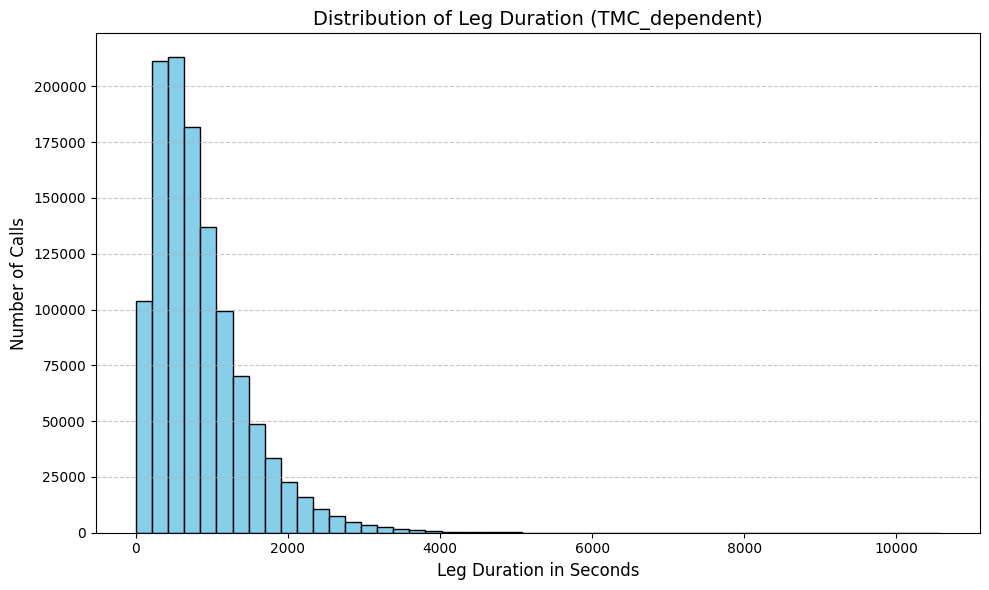

In [5]:
# Create TMC_dependent
full_merged_df['TMC_dependent'] = full_merged_df['call_LEG_DURATION_SEC_QTY']

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(full_merged_df['TMC_dependent'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of Leg Duration (TMC_dependent)', fontsize=14)
plt.xlabel('Leg Duration in Seconds', fontsize=12)
plt.ylabel('Number of Calls', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

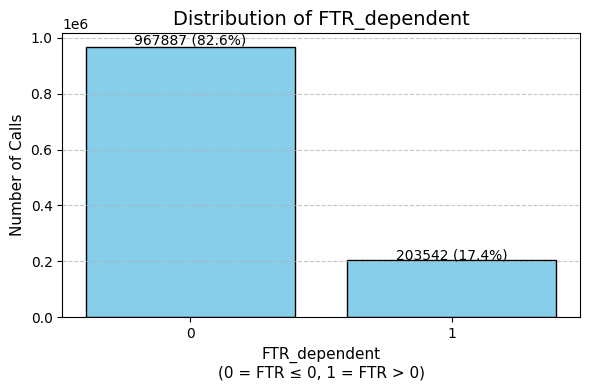

In [6]:
# Create FTR_dependent
full_merged_df['FTR_dependent'] = (full_merged_df['call_FTR_CALCULATED'] > 0).astype(int)

# Plot distribution
ftr_counts = full_merged_df['FTR_dependent'].value_counts().sort_index()
ftr_percent = ftr_counts / ftr_counts.sum() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(ftr_counts.index.astype(str), ftr_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of FTR_dependent', fontsize=14)
plt.xlabel('FTR_dependent\n(0 = FTR ≤ 0, 1 = FTR > 0)', fontsize=11)
plt.ylabel('Number of Calls', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add count and % labels
for i, (count, pct) in enumerate(zip(ftr_counts.values, ftr_percent)):
    plt.text(i, count + count*0.01, f'{count} ({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

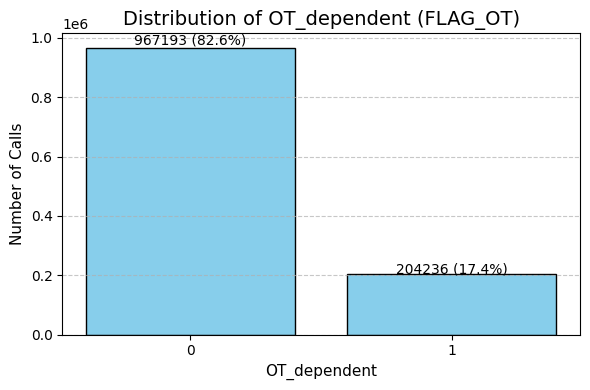

In [7]:
# Create OT_dependent
full_merged_df['OT_dependent'] = full_merged_df['call_FLAG_OT']

# Plot distribution
ot_counts = full_merged_df['OT_dependent'].value_counts().sort_index()
ot_percent = ot_counts / ot_counts.sum() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(ot_counts.index.astype(str), ot_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of OT_dependent (FLAG_OT)', fontsize=14)
plt.xlabel('OT_dependent', fontsize=11)
plt.ylabel('Number of Calls', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add count and % labels
for i, (count, pct) in enumerate(zip(ot_counts.values, ot_percent)):
    plt.text(i, count + count*0.01, f'{count} ({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [8]:
print(full_merged_df[['call_FTR_CALCULATED', 'call_FLAG_OT']].describe())
print(full_merged_df['FTR_dependent'].value_counts(normalize=True))
print(full_merged_df['OT_dependent'].value_counts(normalize=True))

       call_FTR_CALCULATED  call_FLAG_OT
count         1.171429e+06  1.171429e+06
mean          1.520785e-01  1.743477e-01
std           3.447430e-01  3.794084e-01
min           0.000000e+00  0.000000e+00
25%           0.000000e+00  0.000000e+00
50%           0.000000e+00  0.000000e+00
75%           0.000000e+00  0.000000e+00
max           1.000000e+00  1.000000e+00
FTR_dependent
0    0.826245
1    0.173755
Name: proportion, dtype: float64
OT_dependent
0    0.825652
1    0.174348
Name: proportion, dtype: float64


### <a id='toc1_3_2_'></a>[Feature Engineering](#toc0_)

In [9]:
# Convert call_CALL_START_TIME_DAT	call_CALL_END_TIME_DAT	call_LEG_START_TIME_DAT	call_LEG_END_TIME_DAT to datetime
full_merged_df["call_CALL_START_TIME_DAT"] = pd.to_datetime(full_merged_df["call_CALL_START_TIME_DAT"])
full_merged_df["call_CALL_END_TIME_DAT"] = pd.to_datetime(full_merged_df["call_CALL_END_TIME_DAT"])
full_merged_df["call_LEG_START_TIME_DAT"] = pd.to_datetime(full_merged_df["call_LEG_START_TIME_DAT"])
full_merged_df["call_LEG_END_TIME_DAT"] = pd.to_datetime(full_merged_df["call_LEG_END_TIME_DAT"])


In [10]:
# Feature Engineering
# 1. Calls in the last 7 days (0 for no, 1 for yes)
# 2. Days since last call (Client)
# 3. Tipicification level 2
# 4. Days since last call (GC)
# 5. Weekday or Weekend
# 6. Time of day (Morning, Afternoon, Evening, Night)


#### <a id='toc1_3_2_1_'></a>[Calls in the last 7 days](#toc0_)

In [11]:
# 1. Calls in the last 7 days (Client)
# This requires knowing the previous call time for the same client.
# First, sort by client and then by call time to correctly identify previous calls.
full_merged_df = full_merged_df.sort_values(by=['call_PERSON_ID', 'call_CALL_START_TIME_DAT'])

# Get the previous call time for each client
full_merged_df['previous_call_time_client'] = full_merged_df.groupby('call_PERSON_ID')['call_CALL_START_TIME_DAT'].shift(1)

# Calculate days since the previous call for that client
full_merged_df['days_since_prev_call_for_client'] = (full_merged_df['call_CALL_START_TIME_DAT'] - full_merged_df['previous_call_time_client']).dt.days

# Feature: 1 if there was a call from this client in the last 7 days (relative to the current call), 0 otherwise
# For the first call of a client, 'days_since_prev_call_for_client' will be NaN.
full_merged_df['client_called_in_last_7_days'] = full_merged_df['days_since_prev_call_for_client'].apply(lambda x: 1 if pd.notna(x) and x <= 7 else 0)

#### <a id='toc1_3_2_2_'></a>[Days since last call (Client)](#toc0_)

In [12]:
# 2. Days since last call (Client)
# This is essentially 'days_since_prev_call_for_client' calculated above.
# We might want to fill NaNs for clients with no prior calls (e.g., with -1 or a large number).
# For this example, let's keep it as is, or fill with a placeholder like -1.
full_merged_df['days_since_prev_call_for_client'] = full_merged_df['days_since_prev_call_for_client'].fillna(-1).astype(int)
full_merged_df['days_since_last_call_client'] = full_merged_df['days_since_prev_call_for_client'] # Or keep NaN if preferred


#### <a id='toc1_3_2_3_'></a>[Tipification level 2](#toc0_)

In [13]:
def enrich_with_lvl2_topic_features(df, person_col="PERSON_SK"):
    """
    Adds historical Level 2 topic features:
    - Lagged topic category
    - Cumulative topic counts
    - Proportions over client history
    - One-hot lag features
    - First-call flag
    """
    df = df.copy()

    # --- 1. 'TV' to 'TELEVISÃO' ---
    df["call_TOPIC_TIPIFICATION_LVL_2_DSC"] = df["call_TOPIC_TIPIFICATION_LVL_2_DSC"].replace("TV", "TELEVISÃO")

    # --- 2. Group Level 2 topics ---
    topics_to_keep_lvl2 = {
        "INTERNET FIXA", "TELEVISÃO", "BOX", "VOZ FIXA",
        "ADESÃO/ALTERAÇÃO", "SEM VOZ DE CLIENTE", "MAIS INFORMAÇÕES", "CARTÃO SIM/ESIM/TWIN"
    }
    df["TOPIC_LVL_2_GROUPED"] = df["call_TOPIC_TIPIFICATION_LVL_2_DSC"].apply(
        lambda x: x if x in topics_to_keep_lvl2 else "OUTROS"
    )

    # --- 3. Lagged topic (string-based), fill missing with 'NO_PREV_CALL' ---
    df["TOPIC_LVL_2_GROUPED_LAG1_STR"] = df.groupby(person_col)["TOPIC_LVL_2_GROUPED"].shift(1).fillna("NO_PREV_CALL")

    # --- 4. One-hot dummies for counting, drop dummy lag class ---
    lvl2_dummies = pd.get_dummies(df["TOPIC_LVL_2_GROUPED_LAG1_STR"], prefix="CNT_LVL2")
    lvl2_dummies = lvl2_dummies.drop(columns=[col for col in lvl2_dummies if "NO_PREV_CALL" in col], errors='ignore')

    # --- 5. Cumulative topic count ---
    lvl2_counts = lvl2_dummies.groupby(df[person_col]).cumsum()
    df = pd.concat([df, lvl2_counts], axis=1)

    # --- 6. Cumulative call number per client ---
    df["CUM_TOTAL_CALLS"] = df.groupby(person_col).cumcount()

    # --- 7. Proportional features ---
    for col in lvl2_counts.columns:
        df[col.replace("CNT_", "PROP_")] = lvl2_counts[col] / (df["CUM_TOTAL_CALLS"] + 1)

    # --- 8. One-hot encode lag string for model use (keep 'NO_PREV_CALL') ---
    lag1_l2_encoded = pd.get_dummies(df["TOPIC_LVL_2_GROUPED_LAG1_STR"], prefix="LAG1_LVL2", drop_first=False)
    df = pd.concat([df, lag1_l2_encoded.astype(int)], axis=1)

    # --- 9. First call flag ---
    df["IS_FIRST_CALL"] = (df["CUM_TOTAL_CALLS"] == 0).astype(int)

    return df

full_merged_df = enrich_with_lvl2_topic_features(full_merged_df)

In [14]:
features_to_include = [
    "IS_FIRST_CALL"
]

# Add all CNT_LVL2_* columns
features_to_include += [col for col in full_merged_df.columns if col.startswith("CNT_LVL2_")]

# Add all PROP_LVL2_* columns
features_to_include += [col for col in full_merged_df.columns if col.startswith("PROP_LVL2_")]

# Add all LAG1_LVL2_* columns
features_to_include += [col for col in full_merged_df.columns if col.startswith("LAG1_LVL2_")]

print("Features to include:")
for feature in features_to_include:
    print(feature)

Features to include:
IS_FIRST_CALL
CNT_LVL2_ADESÃO/ALTERAÇÃO
CNT_LVL2_BOX
CNT_LVL2_CARTÃO SIM/ESIM/TWIN
CNT_LVL2_INTERNET FIXA
CNT_LVL2_MAIS INFORMAÇÕES
CNT_LVL2_OUTROS
CNT_LVL2_SEM VOZ DE CLIENTE
CNT_LVL2_TELEVISÃO
CNT_LVL2_VOZ FIXA
PROP_LVL2_ADESÃO/ALTERAÇÃO
PROP_LVL2_BOX
PROP_LVL2_CARTÃO SIM/ESIM/TWIN
PROP_LVL2_INTERNET FIXA
PROP_LVL2_MAIS INFORMAÇÕES
PROP_LVL2_OUTROS
PROP_LVL2_SEM VOZ DE CLIENTE
PROP_LVL2_TELEVISÃO
PROP_LVL2_VOZ FIXA
LAG1_LVL2_ADESÃO/ALTERAÇÃO
LAG1_LVL2_BOX
LAG1_LVL2_CARTÃO SIM/ESIM/TWIN
LAG1_LVL2_INTERNET FIXA
LAG1_LVL2_MAIS INFORMAÇÕES
LAG1_LVL2_NO_PREV_CALL
LAG1_LVL2_OUTROS
LAG1_LVL2_SEM VOZ DE CLIENTE
LAG1_LVL2_TELEVISÃO
LAG1_LVL2_VOZ FIXA


#### <a id='toc1_3_2_4_'></a>[Days since last call (GC - Group Key)](#toc0_)

In [15]:
# 4. Days since last call (GC - Group Key)
# Similar to client, but grouping by 'RESOURCE_KEY'
full_merged_df = full_merged_df.sort_values(by=['RESOURCE_KEY', 'call_CALL_START_TIME_DAT']) # Ensure sort order for GC
full_merged_df['previous_call_time_gc'] = full_merged_df.groupby('RESOURCE_KEY')['call_CALL_START_TIME_DAT'].shift(1)
full_merged_df['days_since_last_call_gc'] = (full_merged_df['call_CALL_START_TIME_DAT'] - full_merged_df['previous_call_time_gc']).dt.days

# We might want to fill NaNs for clients with no prior calls (e.g., with -1 or a large number).
# For this example, let's keep it as is, or fill with a placeholder like -1.
full_merged_df['days_since_last_call_gc'] = full_merged_df['days_since_last_call_gc'].fillna(-1).astype(int) # Or keep NaN


#### <a id='toc1_3_2_5_'></a>[Weekday or Weekend](#toc0_)

In [16]:
# 5. Weekday or Weekend
# 0 is Monday, 6 is Sunday. So, 5 (Saturday) and 6 (Sunday) are weekends.
full_merged_df['day_of_week'] = full_merged_df['call_CALL_START_TIME_DAT'].dt.dayofweek
full_merged_df['is_weekend'] = full_merged_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0) # 1 for weekend, 0 for weekday
# Or as string categories:
full_merged_df['weekday_or_weekend_str'] = full_merged_df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

#### <a id='toc1_3_2_6_'></a>[Time of day](#toc0_)

In [17]:
# 6. Time of day (Morning, Afternoon, Evening, Night)
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'  # 5 AM to 11:59 AM
    elif 12 <= hour < 18:
        return 'Afternoon' # 12 PM to 5:59 PM
    elif 18 <= hour < 22:
        return 'Evening'   # 6 PM to 9:59 PM
    else:
        return 'Night'     # 10 PM to 4:59 AM

full_merged_df['hour_of_day'] = full_merged_df['call_CALL_START_TIME_DAT'].dt.hour
full_merged_df['time_of_day_str'] = full_merged_df['hour_of_day'].apply(get_time_of_day)

#### <a id='toc1_3_2_7_'></a>[Topic Classification Entry at FT - PREVIOUS CALL](#toc0_)

In [18]:
# Lagged feature: topic of the previous call per client
full_merged_df["PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT"] = (
    full_merged_df.groupby("PERSON_SK")["call_TOPIC_CLASSIFIC_ENTRY_AT_FT"].shift(1)
)

In [19]:
full_merged_df.head()

,call_Column1,call_LEG_IF_ID,call_PERSON_ID,PERSON_SK,call_CALL_IF_ID,call_GROUP_KEY,RESOURCE_KEY,call_NR_RPC_0,call_NR_RPC_1,call_NR_INCIDENTS_PER_LEG,...,LAG1_LVL2_VOZ FIXA,IS_FIRST_CALL,previous_call_time_gc,days_since_last_call_gc,day_of_week,is_weekend,weekday_or_weekend_str,hour_of_day,time_of_day_str,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT
2231,693119,8464046329,0S/WP6CbM730eF/9HQRkBY8mQbz6hp5kqKLj+Z1QszxE=,0K/zAFzNNbDThGL6zBqHU9wAkcJHtmOK3mg7pkJ94p+c=,1731747625,631410001,11741170013,1.0,0.0,1.0,...,0,1,NaT,-1,1,0,Weekday,8,Morning,NaN
3211,632503,8464267869,0EfQa6yf84/6c/yePV8rXdjIRJ53s2d5psyWPqGBOgaA=,0dprrzD5IhbFa1xdn9KfGvYI9LBRs+c/4/sn2qY/tz8U=,1731781743,631410001,11741170013,1.0,0.0,1.0,...,0,1,2024-01-02 08:23:19,0,1,0,Weekday,10,Morning,NaN
4300,655329,8464477041,0LMh52DVtn6ntNerhZLKIa/8bW1kOwHRhKvMCBS4XLcE=,0MrLgtZPFCvdfReKaPKV2OG4G3FsvWFLvynPcQI4p848=,1731814533,631410001,11741170013,0.0,1.0,1.0,...,0,1,2024-01-02 10:01:19,0,1,0,Weekday,10,Morning,NaN
5578,320865,8464570641,0TjgNugpUpEwcD/JYxkbPDerB5oHqxverdEnzEIwojHU=,0mFGMIaF22Ndc02butKRd26YciZ76vq38rOcyD5PpKcE=,1731831081,631410001,11741170013,0.0,1.0,1.0,...,0,1,2024-01-02 10:28:08,0,1,0,Weekday,10,Morning,NaN
3736,503754,8464613169,0Pkt5bCUNkwGeQLUERqhxZcO9+9ixfSB4+DjpcJqF5S8=,0AgnlhnrDQ3FMbfhktP10JaAmEiGA5k5RjG/oesYjPgc=,1731835337,631410001,11741170013,2.0,0.0,2.0,...,0,0,2024-01-02 10:58:29,0,1,0,Weekday,11,Morning,NaN


### <a id='toc1_3_3_'></a>[Create Baseline Prediction Columns (Rule-Based Average Targets per Cat)](#toc0_)

In [20]:
# Calculate average duration and resolution rate per call_TOPIC_CLASSIFIC_ENTRY_AT_FT
avg_duration = full_merged_df.groupby('call_TOPIC_CLASSIFIC_ENTRY_AT_FT')['call_CALL_DURATION_SEQ_QTY'].mean()
avg_resolution_rate = full_merged_df.groupby('call_TOPIC_CLASSIFIC_ENTRY_AT_FT')['FTR_dependent'].mean()#
avg_ot_rate = full_merged_df.groupby('call_TOPIC_CLASSIFIC_ENTRY_AT_FT')['OT_dependent'].mean()

# Create a DataFrame to hold the average duration and resolution rate
avg_resolution_df = pd.DataFrame({
    'avg_duration': avg_duration,
    'avg_resolution_rate': avg_resolution_rate,
    'avg_ot_rate': avg_ot_rate
}).reset_index()

# Rename the columns for clarity
avg_resolution_df.columns = ['call_TOPIC_CLASSIFIC_ENTRY_AT_FT', 'avg_duration', 'avg_resolution_rate', 'avg_ot_rate']

# Merge the average duration and resolution rate back into the main DataFrame
full_merged_df = full_merged_df.merge(avg_resolution_df, on='call_TOPIC_CLASSIFIC_ENTRY_AT_FT', how='left')

# Set random seed for reproducibility
np.random.seed(42)

# Create baseline predictions using a "manipulated coin flip"
full_merged_df["Predicted_FTR_BASELINE"] = full_merged_df["avg_resolution_rate"].apply(
    lambda x: 1 if np.random.rand() < x else 0
)

df_for_demo=full_merged_df.copy()

In [21]:
full_merged_df.columns.tolist()[-10:]

['day_of_week',
 'is_weekend',
 'weekday_or_weekend_str',
 'hour_of_day',
 'time_of_day_str',
 'PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT',
 'avg_duration',
 'avg_resolution_rate',
 'avg_ot_rate',
 'Predicted_FTR_BASELINE']

# <a id='toc2_'></a>[ITERATIVE LEARNING REFINEMENT](#toc0_)

### <a id='toc2_1_1_'></a>[Build Lable](#toc0_)

In [22]:
import numpy as np
import pandas as pd

# -----------------------------
# Fixed constants
# -----------------------------
RATE_PER_MIN = 0.35      # €/min to handle a call
OT_COST      = 22.0      # € cost if a technician is sent
OT_WEIGHT    = 0.50      # reduced OT scenario
HYBRID_ALPHA = 0.70      # 70% observed, 30% group mean
EPS          = 1e-9       # avoids log(0)

# -----------------------------
# Column names
# -----------------------------
COL_ID    = "call_LEG_IF_ID"
COL_TOPIC = "call_TOPIC_CLASSIFIC_ENTRY_AT_FT"
COL_DUR   = "TMC_dependent"
COL_FTR   = "FTR_dependent"
COL_OT    = "OT_dependent"

def build_reasonable_labels(full_merged_df: pd.DataFrame) -> pd.DataFrame:

    "Build robust per-call cost labels combining multiple scenario-based formulas"

    # ---- 1. Minimal clean DataFrame ----
    labels_base = pd.DataFrame({
        COL_ID:    full_merged_df[COL_ID],
        COL_TOPIC: full_merged_df[COL_TOPIC],
        "dur_obs": full_merged_df[COL_DUR].astype(float) / 60.0,
        COL_FTR:   full_merged_df[COL_FTR].astype(float),
        COL_OT:    full_merged_df[COL_OT].astype(float),
    })

    # ---- 2. Group means ----
    dur_group = labels_base.groupby(COL_TOPIC)["dur_obs"].transform("mean")
    ftr_group = labels_base.groupby(COL_TOPIC)[COL_FTR].transform("mean")
    rep_group = (1.0 - ftr_group).clip(0, 1)

    # ---- 3. Hybrid duration ----    bc observed durations jump around a lot (noise) while group means are smoother
    labels_base["dur_min_hybrid"] = (
        HYBRID_ALPHA * labels_base["dur_obs"] +
        (1 - HYBRID_ALPHA) * dur_group
    )

    # ---- 4. Build cost scenarios ---- i.e., What could the cost look like under slightly different modeling assumptions?
    dur_global = labels_base["dur_obs"].mean()

    labels_base["total_cost_raw"] = (
        labels_base["dur_obs"] * RATE_PER_MIN
        + (1.0 - labels_base[COL_FTR]) * labels_base["dur_obs"] * RATE_PER_MIN
        + labels_base[COL_OT] * OT_COST
    )

    labels_base["total_cost_avg_global"] = (
        labels_base["dur_obs"] * RATE_PER_MIN
        + (1.0 - labels_base[COL_FTR]) * dur_global * RATE_PER_MIN
        + labels_base[COL_OT] * OT_COST
    )

    labels_base["total_cost_avg_group"] = (
        labels_base["dur_obs"] * RATE_PER_MIN
        + (1.0 - labels_base[COL_FTR]) * dur_group * RATE_PER_MIN
        + labels_base[COL_OT] * OT_COST
    )

    labels_base["total_cost_softOT"] = (
        labels_base["dur_obs"] * RATE_PER_MIN
        + (1.0 - labels_base[COL_FTR]) * labels_base["dur_obs"] * RATE_PER_MIN
        + labels_base[COL_OT] * (OT_COST * OT_WEIGHT)
    )

    labels_base["total_cost_probRep"] = (
        labels_base["dur_obs"] * RATE_PER_MIN
        + rep_group * labels_base["dur_obs"] * RATE_PER_MIN
        + labels_base[COL_OT] * OT_COST
    )

    labels_base["total_cost_hybrid"] = (
        labels_base["dur_obs"] * RATE_PER_MIN
        + (1.0 - labels_base[COL_FTR]) * labels_base["dur_min_hybrid"] * RATE_PER_MIN
        + labels_base[COL_OT] * OT_COST
    )

    # ---- 5. Consensus label ---- i.e., average the 6 cost formulas to give a robust “best guess”.
    label_cols = [
        "total_cost_raw",
        "total_cost_avg_global",
        "total_cost_avg_group",
        "total_cost_softOT",
        "total_cost_probRep",
        "total_cost_hybrid",
    ]

    M = labels_base[label_cols].to_numpy(float)

    labels_base["label_mean_eur"] = np.nanmean(M, axis=1)
    labels_base["label_var_eur2"] = np.nanvar(M, axis=1)
    labels_base["label_std_eur"]  = np.sqrt(labels_base["label_var_eur2"] + EPS)

    # ---- 6. Sample weights ----  Rows where the formulas disagree get lower weight later when we train the helper model: noisy observations count less.
    labels_base["label_weight"] = 1.0 / (labels_base["label_var_eur2"] + 1e-6)
    cap = labels_base["label_weight"].quantile(0.99)
    labels_base["label_weight"] = labels_base["label_weight"].clip(upper=cap)

    # ---- 7. Log versions ----   LR works in log-space, because costs are skewed and log stabilizes variance.
    for c in label_cols + ["label_mean_eur"]:
        labels_base[f"{c}_log"] = np.log(np.clip(labels_base[c].to_numpy(float), EPS, None))

    print("\n[Step 1] Built labels. Summary:")
    print(labels_base[["label_mean_eur", "label_std_eur"]].describe().round(3))

    return labels_base


### <a id='toc2_1_2_'></a>[Train Simpler Model](#toc0_)

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor

def build_oof_predictions(
    labels_base: pd.DataFrame,
    n_splits: int = 5,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Step 2 of ILR.
    Train a simple tree-based model to predict log(label_mean_eur) using ONLY the topic
    (non-leaky context feature). Produce OUT-OF-FOLD predictions for each row.

    Returns a copy called 'labels_oof' with:
      - oof_pred_log: out-of-fold predicted log-cost
      - oof_resid_log: residual in log-space (true - predicted)
    """

    # ---------- 1) Copy + target in log-space ----------
    labels_oof = labels_base.copy()
    EPS = 1e-9

    if "label_mean_eur" not in labels_oof.columns:
        raise ValueError("labels_base must contain 'label_mean_eur' from Step 1.")

    y_log = np.log(
        np.clip(labels_oof["label_mean_eur"].astype(float).values, EPS, None)
    )

    # ---------- 2) Use ONLY safe context feature(s) ----------
    # For now: just the topic. This keeps ILR simple and non-leaky.
    FEATURE_COLS = ["call_TOPIC_CLASSIFIC_ENTRY_AT_FT"]
    feature_cols = [c for c in FEATURE_COLS if c in labels_oof.columns]

    if not feature_cols:
        raise ValueError("No valid feature columns found for OOF model.")

    X_cat = labels_oof[feature_cols].astype(str).fillna("NA")
    X = pd.get_dummies(X_cat, drop_first=False, dtype=float)
    Xv = X.to_numpy(dtype=float)

    # ---------- 3) Sample weights from Step 1 (optional but nice) ----------
    sample_w = None
    if "label_weight" in labels_oof.columns:
        sample_w = labels_oof["label_weight"].astype(float).values

    # ---------- 4) Out-of-fold setup ----------
    n = len(labels_oof)
    n_splits_eff = max(2, min(n_splits, n))
    kf = KFold(n_splits=n_splits_eff, shuffle=True, random_state=random_state)
    oof_pred_log = np.zeros(n, dtype=float)

    # ---------- 5) Simple helper model ----------
    gbr_params = dict(
        n_estimators=120,
        learning_rate=0.08,
        max_depth=3,
        random_state=random_state,
    )

    for tr_idx, va_idx in kf.split(Xv):
        model = GradientBoostingRegressor(**gbr_params)
        if sample_w is None:
            model.fit(Xv[tr_idx], y_log[tr_idx])
        else:
            model.fit(Xv[tr_idx], y_log[tr_idx], sample_weight=sample_w[tr_idx])

        oof_pred_log[va_idx] = model.predict(Xv[va_idx])

    # ---------- 6) Residuals & diagnostics ----------
    labels_oof["oof_pred_log"]  = oof_pred_log
    labels_oof["oof_resid_log"] = y_log - oof_pred_log

    print("\n[Step 2] OOF diagnostics (topic-only ILR helper):")
    print("  Features used:", feature_cols)
    print("  X shape:", X.shape)
    print("  y_log mean/std:",
          round(float(np.mean(y_log)), 4),
          round(float(np.std(y_log)), 4))
    print("  OOF resid mean/std:",
          round(float(np.mean(labels_oof['oof_resid_log'])), 4),
          round(float(np.std(labels_oof['oof_resid_log'])), 4))

    return labels_oof

# === ILR Step 1 + Step 2 ===
labels_base = build_reasonable_labels(full_merged_df)  # Step 1
labels_oof  = build_oof_predictions(labels_base, n_splits=5, random_state=42)   # Step 1

labels_oof[["label_mean_eur", "oof_pred_log", "oof_resid_log"]].head()



[Step 1] Built labels. Summary:
       label_mean_eur  label_std_eur
count     1171429.000    1171429.000
mean           12.488          1.821
std            10.052          1.455
min             0.040          0.011
25%             5.309          0.748
50%             8.629          1.317
75%            16.107          2.282
max           101.693         24.073

[Step 2] OOF diagnostics (topic-only ILR helper):
  Features used: ['call_TOPIC_CLASSIFIC_ENTRY_AT_FT']
  X shape: (1171429, 5)
  y_log mean/std: 2.2208 0.7945
  OOF resid mean/std: 0.2525 0.7774


,label_mean_eur,oof_pred_log,oof_resid_log
0,6.607991,1.777784,0.110495
1,0.485521,1.939696,-2.662228
2,12.602189,2.074312,0.459559
3,12.252524,1.943517,0.562215
4,27.166375,2.073656,1.228324


### <a id='toc2_1_3_'></a>[Measure Uncertainties](#toc0_)

In [24]:
import numpy as np
import pandas as pd

def refine_labels_ilr(
    labels_oof: pd.DataFrame,
    mode: str = "per_call",      # {"per_call","global","fixed"}
    fixed_alpha: float = 0.7,
    clip_alpha: tuple[float, float] = (0.05, 0.95),
) -> pd.DataFrame:
    """
    ILR refinement: blend log(original label) with OOF prediction using an alpha
    that depends on label vs model uncertainty.

    Input  (from Step 2): labels_oof with columns:
        - label_mean_eur
        - label_var_eur2
        - oof_pred_log
    Output: labels_refined with columns:
        - alpha_ilr, label_refined_log, label_refined_eur
    """
    EPS = 1e-9

    # --- 1) Pull what we need ---
    labels_refined = labels_oof.copy()
    y_eur = labels_refined["label_mean_eur"].astype(float).values
    y_log = np.log(np.clip(y_eur, EPS, None))                 # original log label
    yhat_log = labels_refined["oof_pred_log"].astype(float).values  # model's OOF prediction (log)

    # --- 2) Uncertainties ---
    # Model uncertainty: how spread the OOF residuals are (variance in log space)
    if "oof_resid_log" in labels_refined.columns:
        resid_log = labels_refined["oof_resid_log"].astype(float).values
    else:
        resid_log = y_log - yhat_log
    v_pred = float(np.var(resid_log))    # scalar

    # Label uncertainty: convert label variance (in €^2) to log-space via delta method
    if "label_var_eur2" not in labels_refined.columns:
        raise ValueError("labels_oof must contain 'label_var_eur2' from Step 1")
    v_label_eur2 = labels_refined["label_var_eur2"].astype(float).values
    v_label_log  = v_label_eur2 / (np.clip(y_eur, EPS, None) ** 2)  # elementwise

    # --- 3) Alpha (blend weight) ---
    if mode == "per_call":
        # row-wise alpha: trust the model more when label is noisy (v_label_log high)
        alpha = v_pred / (v_pred + np.maximum(v_label_log, 1e-12))   # vector
    elif mode == "global":
        # one alpha for everyone
        vg_label = float(np.mean(np.maximum(v_label_log, 1e-12)))    # scalar
        alpha = np.full_like(y_log, v_pred / (v_pred + vg_label), dtype=float)
    elif mode == "fixed":
        # constant alpha you choose
        alpha = np.full_like(y_log, float(fixed_alpha), dtype=float)
    else:
        raise ValueError("mode must be one of {'per_call','global','fixed'}")

    # Keep alphas reasonable (avoid extremes)
    a_lo, a_hi = clip_alpha
    alpha = np.clip(alpha, a_lo, a_hi)

    # --- 4) Blend in log-space and back-transform ---
    # refined_log = alpha * log(original) + (1 - alpha) * oof_pred_log
    refined_log = alpha * y_log + (1.0 - alpha) * yhat_log
    refined_eur = np.exp(refined_log)

    # --- 5) Save outputs + simple diagnostics ---
    labels_refined["alpha_ilr"]         = alpha
    labels_refined["label_refined_log"] = refined_log
    labels_refined["label_refined_eur"] = refined_eur

    print("\n[Step 3] ILR blend diagnostics")
    print("  mode:", mode)
    print("  model_uncert_var (v_pred):", round(v_pred, 6))
    print("  alpha summary:")
    print(pd.Series(alpha).describe().round(3))

    return labels_refined


In [25]:
labels_refined = refine_labels_ilr(labels_oof, mode="per_call")   # best default
labels_refined_fixed  = refine_labels_ilr(labels_oof, mode="fixed",  fixed_alpha=0.7)
labels_refined_global = refine_labels_ilr(labels_oof, mode="global")


[Step 3] ILR blend diagnostics
  mode: per_call
  model_uncert_var (v_pred): 0.60439
  alpha summary:
count    1171429.000
mean           0.908
std            0.090
min            0.306
25%            0.896
50%            0.950
75%            0.950
max            0.950
dtype: float64

[Step 3] ILR blend diagnostics
  mode: fixed
  model_uncert_var (v_pred): 0.60439
  alpha summary:
count    1171429.0
mean           0.7
std            0.0
min            0.7
25%            0.7
50%            0.7
75%            0.7
max            0.7
dtype: float64

[Step 3] ILR blend diagnostics
  mode: global
  model_uncert_var (v_pred): 0.60439
  alpha summary:
count    1171429.000
mean           0.909
std            0.000
min            0.909
25%            0.909
50%            0.909
75%            0.909
max            0.909
dtype: float64


### <a id='toc2_1_4_'></a>[Visualize](#toc0_)

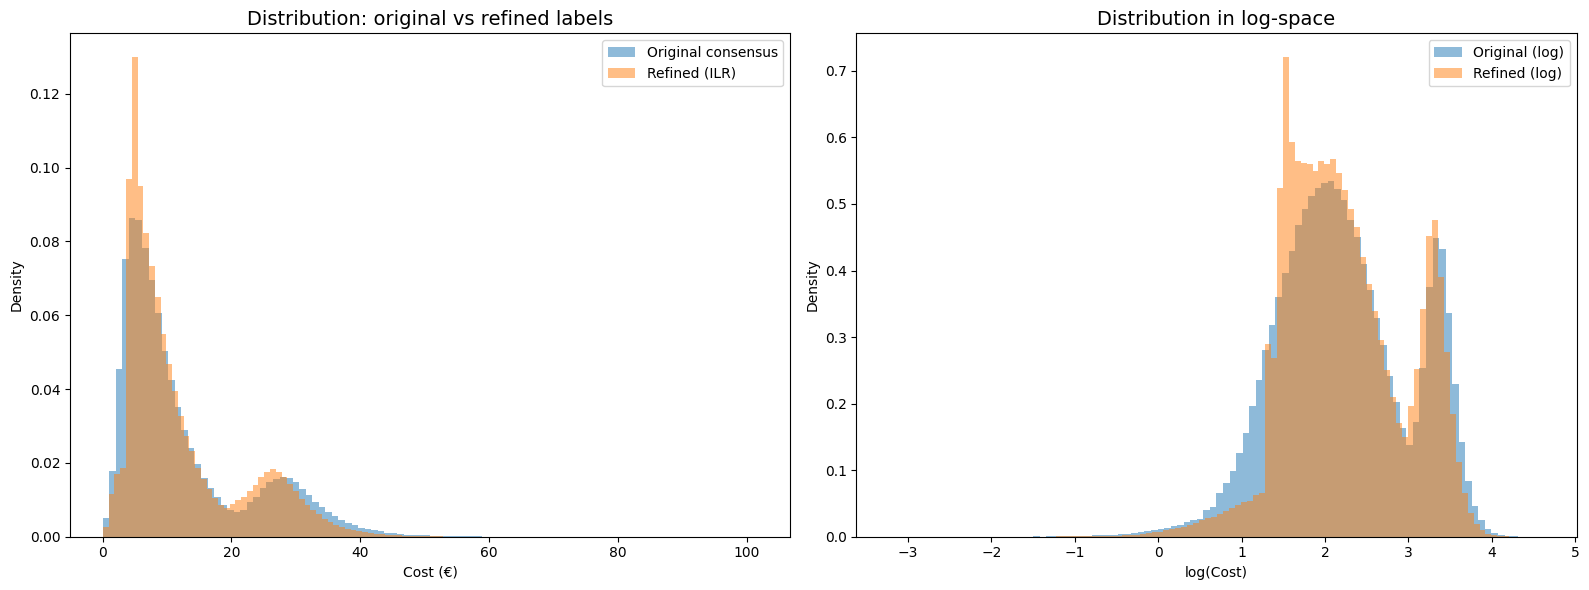

In [26]:
import matplotlib.pyplot as plt
import numpy as np

orig = labels_refined["label_mean_eur"]
ref  = labels_refined["label_refined_eur"]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- 1. Original vs Refined (euros) ---
axes[0].hist(orig, bins=100, alpha=0.5, label="Original consensus", density=True)
axes[0].hist(ref,  bins=100, alpha=0.5, label="Refined (ILR)", density=True)
axes[0].set_title("Distribution: original vs refined labels", fontsize=14)
axes[0].set_xlabel("Cost (€)")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- 2. Log-space comparison ---
axes[1].hist(np.log(orig + 1e-9), bins=100, alpha=0.5, label="Original (log)", density=True)
axes[1].hist(np.log(ref  + 1e-9), bins=100, alpha=0.5, label="Refined (log)", density=True)
axes[1].set_title("Distribution in log-space", fontsize=14)
axes[1].set_xlabel("log(Cost)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


In [27]:
# attach refined_log to dataframe
# Select only the ID and final label columns
labels_final = labels_refined[[COL_ID, "label_refined_eur", "label_refined_log", "alpha_ilr"]]

# Merge into your main dataset
full_merged_df = full_merged_df.merge(labels_final, on=COL_ID, how="left", validate="one_to_one")

#rename "label_refined_log" as "final_cost"
full_merged_df = full_merged_df.rename(columns={"label_refined_log": "final_cost"})
full_merged_df.head()


,call_Column1,call_LEG_IF_ID,call_PERSON_ID,PERSON_SK,call_CALL_IF_ID,call_GROUP_KEY,RESOURCE_KEY,call_NR_RPC_0,call_NR_RPC_1,call_NR_INCIDENTS_PER_LEG,...,hour_of_day,time_of_day_str,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT,avg_duration,avg_resolution_rate,avg_ot_rate,Predicted_FTR_BASELINE,label_refined_eur,final_cost,alpha_ilr
0,693119,8464046329,0S/WP6CbM730eF/9HQRkBY8mQbz6hp5kqKLj+Z1QszxE=,0K/zAFzNNbDThGL6zBqHU9wAkcJHtmOK3mg7pkJ94p+c=,1731747625,631410001,11741170013,1.0,0.0,1.0,...,8,Morning,NaN,985.872062,0.143321,0.029764,0,6.571584,1.882755,0.950000
1,632503,8464267869,0EfQa6yf84/6c/yePV8rXdjIRJ53s2d5psyWPqGBOgaA=,0dprrzD5IhbFa1xdn9KfGvYI9LBRs+c/4/sn2qY/tz8U=,1731781743,631410001,11741170013,1.0,0.0,1.0,...,10,Morning,NaN,1029.833972,0.158994,0.002568,0,0.652681,-0.426668,0.888866
2,655329,8464477041,0LMh52DVtn6ntNerhZLKIa/8bW1kOwHRhKvMCBS4XLcE=,0MrLgtZPFCvdfReKaPKV2OG4G3FsvWFLvynPcQI4p848=,1731814533,631410001,11741170013,0.0,1.0,1.0,...,10,Morning,NaN,1181.417774,0.175122,0.222987,0,12.315918,2.510893,0.950000
3,320865,8464570641,0TjgNugpUpEwcD/JYxkbPDerB5oHqxverdEnzEIwojHU=,0mFGMIaF22Ndc02butKRd26YciZ76vq38rOcyD5PpKcE=,1731831081,631410001,11741170013,0.0,1.0,1.0,...,10,Morning,NaN,1175.801916,0.192466,0.222782,0,11.912892,2.477621,0.950000
4,503754,8464613169,0Pkt5bCUNkwGeQLUERqhxZcO9+9ixfSB4+DjpcJqF5S8=,0AgnlhnrDQ3FMbfhktP10JaAmEiGA5k5RjG/oesYjPgc=,1731835337,631410001,11741170013,2.0,0.0,2.0,...,11,Morning,NaN,1181.417774,0.175122,0.222987,1,25.548121,3.240564,0.950000


### <a id='toc2_1_5_'></a>[Finalize working dataset](#toc0_)

In [28]:
# Save non-feature identifiers separately
id_columns = full_merged_df[['call_LEG_IF_ID', 'RESOURCE_KEY']]

In [29]:
# Create reduced_df by selecting specific columns (preserving original order)
# HERE YOU CAN SELECT THE COLUMNS BY # WHICH WILL THEN BE USED FOR MODELING (DEPENDENT VARIABLES CANNOT BE DESELECTED)

reduced_df = full_merged_df[[
    # "call_LEG_IF_ID",
    # "PERSON_SK",
    # "call_CALL_IF_ID",
    # "RESOURCE_KEY",
    # "call_NR_RPC_0",
    # "call_NR_RPC_1",
    # "call_NR_INCIDENTS_PER_LEG",
    # "call_CALL_START_TIME_DAT",
    # "call_CALL_END_TIME_DAT",
    # "call_LEG_START_TIME_DAT",
    # "call_LEG_END_TIME_DAT",
    # "call_LEG_DURATION_SEC_QTY",
    # "call_CALL_DURATION_SEQ_QTY",
    # "call_TOPIC_TIPIFICATION_LVL_1_DSC",
    # "call_TOPIC_TIPIFICATION_LVL_2_DSC",
    # "call_TOPIC_TIPIFICATION_LVL_3_DSC",
    "call_TOPIC_CLASSIFIC_ENTRY_AT_FT",
    # "call_WORK_ORDER_ID",
    # "call_TIBCO_DIFFUSION_DAT",
    # "call_TOPIC_INCIDENT_COD_COUNT",
    # "call_FTR_CALCULATED",
    # "call_WORK_ORDER_SCHEDULE_END_DAT",
    # "call_FLAG_OT",
    # "call_CALL_START_TIME_DAT_normalized",
    "gc_COUNT_CALLS",
    "gc_DAYS_ACTIVE",
    # "gc_MEAN_RPC",
    "gc_MEAN_FTR",
    "gc_MEAN_TMC",
    "gc_OTS_BY_CALL",
    "gc_COUNT_CALLS_IF",
    # "gc_MEAN_RPC_IF",
    "gc_MEAN_FTR_IF",
    "gc_MEAN_TMC_IF",
    "gc_TOTAL_OTS_IF",
    "gc_OTS_BY_CALL_IF",
    "gc_COUNT_CALLS_OTHER",
    # "gc_MEAN_RPC_OTHER",
    "gc_MEAN_FTR_OTHER",
    "gc_MEAN_TMC_OTHER",
    "gc_TOTAL_OTS_OTHER",
    "gc_OTS_BY_CALL_OTHER",
    "gc_COUNT_CALLS_VF",
    # "gc_MEAN_RPC_VF",
    "gc_MEAN_FTR_VF",
    "gc_MEAN_TMC_VF",
    "gc_TOTAL_OTS_VF",
    "gc_OTS_BY_CALL_VF",
    "gc_COUNT_CALLS_TV",
    # "gc_MEAN_RPC_TV",
    "gc_MEAN_FTR_TV",
    "gc_MEAN_TMC_TV",
    "gc_TOTAL_OTS_TV",
    "gc_OTS_BY_CALL_TV",
    "gc_COUNT_CALLS_MOVEL",
    # "gc_MEAN_RPC_MOVEL",
    "gc_MEAN_FTR_MOVEL",
    "gc_MEAN_TMC_MOVEL",
    "gc_TOTAL_OTS_MOVEL",
    "gc_OTS_BY_CALL_MOVEL",
    "gc_CALLS_IF_BINARY",
    "gc_CALLS_OTHER_BINARY",
    "gc_CALLS_VF_BINARY",
    "gc_CALLS_TV_BINARY",
    "gc_CALLS_MOVEL_BINARY",
    # "client_Column1",
    # "client_FISCAL_NUM",
    # "client_START_DATE",
    # "client_PERSON_ID",
    # "client_CA_COD",
    # "client_SA_COD",
    # "client_LEG_START_TIME_DAY",
    # "client_DAT_CRI_SA",
    # "client_DT_NASC",
    "client_CLIENT_AGE_YEARS",
    "client_CLIENT_ANTIQUITY_YEARS",
    "client_NR_SAS",
    "client_ARPU_CALCULATED",
    "client_ARPU_CLIENT",
    "client_PF_CLIENT_MONTHS",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_IF",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_MOVEL",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_OTHER",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_TV",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_VF",
    # "client_LEG_DURATION_MEAN_180_TOTAL",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_IF",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_TV",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_VF",
    "client_LEG_DURATION_MEAN_365_TOTAL",
    # "client_RPC_MEAN_180_ASSUNTO_IF",
    # "client_RPC_MEAN_180_ASSUNTO_MOVEL",
    # "client_RPC_MEAN_180_ASSUNTO_OTHER",
    # "client_RPC_MEAN_180_ASSUNTO_TV",
    # "client_RPC_MEAN_180_ASSUNTO_VF",
    # "client_RPC_MEAN_180_TOTAL",
    "client_RPC_MEAN_365_ASSUNTO_IF",
    "client_RPC_MEAN_365_ASSUNTO_MOVEL",
    "client_RPC_MEAN_365_ASSUNTO_OTHER",
    "client_RPC_MEAN_365_ASSUNTO_TV",
    "client_RPC_MEAN_365_ASSUNTO_VF",
    "client_RPC_MEAN_365_TOTAL",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_IF",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_TV",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_VF",
    # "client_FTR_CALCULATED_MEAN_180_TOTAL",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF",
    "client_FTR_CALCULATED_MEAN_365_TOTAL",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_IF",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_OTHER",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_TV",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_VF",
    # "client_LEG_IF_ID_COUNT_180_TOTAL",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF",
    "client_CALL_IF_ID_NUNIQUE_365_TOTAL",
    "client_Age_missing",
    #"TMC_dependent",
    #"FTR_dependent",
    #"OT_dependent",
    #'previous_call_time_client',
    # 'days_since_last_call_client',
    # "calls_in_last_7_days_client", # number of calls in the last 7 days
    'days_since_prev_call_for_client', # days since last call for the client
    'client_called_in_last_7_days', # 1 if there was a call from this client in the last 7 days, 0 otherwise
    #'previous_call_time_gc',
    'days_since_last_call_gc',	# days since last call for the Resource Key
    # 'day_of_week'	,
    'is_weekend' ,	# 1 for weekend, 0 for weekday
    # 'weekday_or_weekend_str',	# Weekday or Weekend
    'hour_of_day',	# hour of the day (0-23)
    # 'time_of_day_str',     # Time of day (Morning, Afternoon, Evening, Night)
    'IS_FIRST_CALL',
    'CNT_LVL2_ADESÃO/ALTERAÇÃO',
    'CNT_LVL2_BOX',
    'CNT_LVL2_CARTÃO SIM/ESIM/TWIN',
    'CNT_LVL2_INTERNET FIXA',
    'CNT_LVL2_MAIS INFORMAÇÕES',
    'CNT_LVL2_OUTROS',
    'CNT_LVL2_SEM VOZ DE CLIENTE',
    'CNT_LVL2_TELEVISÃO',
    'CNT_LVL2_VOZ FIXA',
    'PROP_LVL2_ADESÃO/ALTERAÇÃO',
    'PROP_LVL2_BOX',
    'PROP_LVL2_CARTÃO SIM/ESIM/TWIN',
    'PROP_LVL2_INTERNET FIXA',
    'PROP_LVL2_MAIS INFORMAÇÕES',
    'PROP_LVL2_OUTROS',
    'PROP_LVL2_SEM VOZ DE CLIENTE',
    'PROP_LVL2_TELEVISÃO',
    'PROP_LVL2_VOZ FIXA',
    'LAG1_LVL2_ADESÃO/ALTERAÇÃO',
    'LAG1_LVL2_BOX',
    'LAG1_LVL2_CARTÃO SIM/ESIM/TWIN',
    'LAG1_LVL2_INTERNET FIXA',
    'LAG1_LVL2_MAIS INFORMAÇÕES',
    # 'LAG1_LVL2_NO_PREV_CALL',
    'LAG1_LVL2_OUTROS',
    'LAG1_LVL2_SEM VOZ DE CLIENTE',
    'LAG1_LVL2_TELEVISÃO',
    'LAG1_LVL2_VOZ FIXA',
    'avg_duration',
    "avg_resolution_rate",
    'Predicted_FTR_BASELINE',
    'avg_ot_rate',
    "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT",
    "final_cost"
]].copy()
reduced_df=reduced_df.dropna()
print(reduced_df.shape)
reduced_df.head()

(609788, 112)


,call_TOPIC_CLASSIFIC_ENTRY_AT_FT,gc_COUNT_CALLS,gc_DAYS_ACTIVE,gc_MEAN_FTR,gc_MEAN_TMC,gc_OTS_BY_CALL,gc_COUNT_CALLS_IF,gc_MEAN_FTR_IF,gc_MEAN_TMC_IF,gc_TOTAL_OTS_IF,...,LAG1_LVL2_OUTROS,LAG1_LVL2_SEM VOZ DE CLIENTE,LAG1_LVL2_TELEVISÃO,LAG1_LVL2_VOZ FIXA,avg_duration,avg_resolution_rate,Predicted_FTR_BASELINE,avg_ot_rate,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT,final_cost
429,VF,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,...,0,0,0,0,1167.983641,0.155596,1,0.143853,IF,1.481740
446,OTHER,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,...,0,0,0,0,985.872062,0.143321,0,0.029764,IF,1.440080
485,IF,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,...,0,0,0,0,1175.801916,0.192466,0,0.222782,IF,1.540823
829,IF,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,...,0,0,0,0,1175.801916,0.192466,0,0.222782,TV,1.483806
1203,IF,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,...,0,0,1,0,1175.801916,0.192466,0,0.222782,TV,3.148492


### <a id='toc2_1_6_'></a>[Encode Categorical Variables](#toc0_)

In [30]:
# Identify categorical columns to encode
categorical_cols = ["call_TOPIC_CLASSIFIC_ENTRY_AT_FT", "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT"]

# One-hot encode all specified categorical columns
encoded_df = pd.get_dummies(reduced_df[categorical_cols], drop_first=True)

# Drop original categorical columns and concatenate one-hot encoded columns
final_df = pd.concat([reduced_df.drop(columns=categorical_cols), encoded_df], axis=1)

# Drop object-type columns that might still exist (e.g., accidentally retained IDs or strings)
final_df = final_df.select_dtypes(exclude=['object'])

# Check result
print("final_df created with shape:", final_df.shape)
final_df.head()


final_df created with shape: (609788, 118)


,gc_COUNT_CALLS,gc_DAYS_ACTIVE,gc_MEAN_FTR,gc_MEAN_TMC,gc_OTS_BY_CALL,gc_COUNT_CALLS_IF,gc_MEAN_FTR_IF,gc_MEAN_TMC_IF,gc_TOTAL_OTS_IF,gc_OTS_BY_CALL_IF,...,avg_ot_rate,final_cost,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF
429,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,0.251158,...,0.143853,1.481740,False,False,False,True,False,False,False,False
446,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,0.251158,...,0.029764,1.440080,False,True,False,False,False,False,False,False
485,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,0.251158,...,0.222782,1.540823,False,False,False,False,False,False,False,False
829,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,0.251158,...,0.222782,1.483806,False,False,False,False,False,False,True,False
1203,3479.0,178.0,0.835962,591.8416,0.16269,1079.0,0.827,643.4541,271.0,0.251158,...,0.222782,3.148492,False,False,False,False,False,False,True,False


# <a id='toc3_'></a>[E2E MODELS](#toc0_)

## <a id='toc3_1_'></a>[Linear Regression](#toc0_)

R2_log: 0.09233327284917126
RMSE_log: 0.6960948319725362

R² after back-transforming both the true and predicted values to the original euro scale
R2_orig_naive: -0.0032180830918158154

R² on the original euro scale, with Duan smearing correction
R2_orig_smear: 0.080262518964062
MAE_orig_smear: 6.835358062810687
RMSE_orig_smear: 8.71134102066646

Ranking metrics
- Spearman ρ: 0.299
- Kendall τ: 0.201
- AUC(bottom10%): 0.703
- AP(bottom10%):  0.244
- Pairwise ranking accuracy: 59.53%


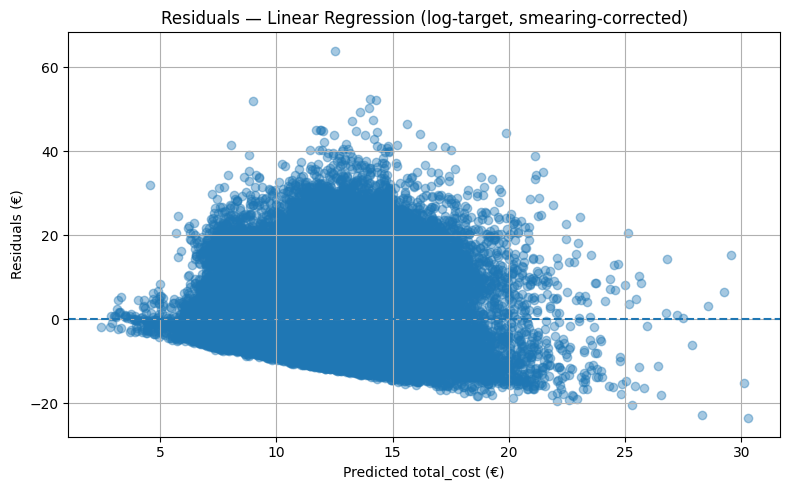

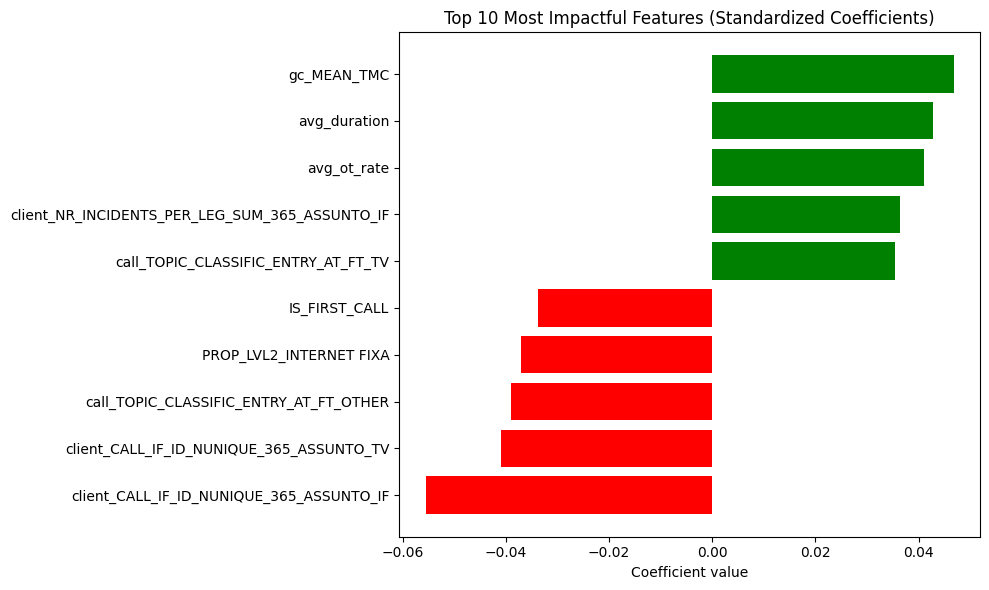

In [33]:
# ====== Linear Regression version (simple + efficient) ======
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, average_precision_score, ndcg_score
)
from scipy.stats import spearmanr, kendalltau

# --- Data prep ---
df = final_df.copy()
y  = df["final_cost"]
X  = df.drop(columns=["final_cost"])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Model ---
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Fit on train
pipe.fit(X_train, y_train)
best_model_lr = pipe

# --- Predictions & log-space metrics ---
y_score      = best_model_lr.predict(X_test)
yhat_log_tr  = best_model_lr.predict(X_train)
print("R2_log:",   r2_score(y_test, y_score))
print("RMSE_log:", np.sqrt(mean_squared_error(y_test, y_score)))

# --- Back-transform (euros): naive ---
y_true_eur = np.exp(y_test.to_numpy())
y_pred_eur = np.exp(y_score)
print("\nR² after back-transforming both the true and predicted values to the original euro scale")
print("R2_orig_naive:", r2_score(y_true_eur, y_pred_eur))

# --- Duan smearing (calibrated euros) ---
smear     = np.mean(np.exp(y_train - yhat_log_tr))
y_pred_bc = y_pred_eur * smear
print("\nR² on the original euro scale, with Duan smearing correction")
print("R2_orig_smear:",  r2_score(y_true_eur, y_pred_bc))
print("MAE_orig_smear:", mean_absolute_error(y_true_eur, y_pred_bc))
print("RMSE_orig_smear:", np.sqrt(mean_squared_error(y_true_eur, y_pred_bc)))

# --- Ranking metrics ---
print("\nRanking metrics")
rho,  _ = spearmanr(y_score, y_test)
tau,  _ = kendalltau(y_score, y_test)
print(f"- Spearman ρ: {rho:.3f}")
print(f"- Kendall τ: {tau:.3f}")

# Bottom-cost tail (bottom 10%)
q10 = np.quantile(y_true_eur, 0.10)
y_bottom = (y_true_eur <= q10).astype(int)
auc = roc_auc_score(y_bottom, -y_score)
ap  = average_precision_score(y_bottom, -y_score)
print(f"- AUC(bottom10%): {auc:.3f}")
print(f"- AP(bottom10%):  {ap:.3f}")

# Pairwise ranking accuracy
rng = np.random.default_rng(42)
n = len(y_score); m = min(10_000, max(1000, n//2))
i = rng.integers(0, n, size=m); j = rng.integers(0, n, size=m)
pairwise_acc = (((y_test.values[i] > y_test.values[j]) & (y_score[i] > y_score[j])) |
                ((y_test.values[i] < y_test.values[j]) & (y_score[i] < y_score[j]))).mean()
print(f"- Pairwise ranking accuracy: {pairwise_acc:.2%}")

# --- Residuals plot (euros; smearing-corrected) ---
resid = y_true_eur - y_pred_bc
plt.figure(figsize=(8,5))
plt.scatter(y_pred_bc, resid, alpha=0.4)
plt.axhline(0, ls="--")
plt.xlabel("Predicted total_cost (€)")
plt.ylabel("Residuals (€)")
plt.title("Residuals — Linear Regression (log-target, smearing-corrected)")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Coefficients ---

import matplotlib.pyplot as plt
lin_model = best_model_lr.named_steps["model"]
coefs = pd.Series(lin_model.coef_, index=X_train.columns)
top10_abs = coefs.abs().sort_values(ascending=False).head(10)
top10 = coefs[top10_abs.index]          # restore signed values
top10_sorted = top10.sort_values()
colors = ["green" if v > 0 else "red" for v in top10_sorted.values]
plt.figure(figsize=(10, 6))
plt.barh(top10_sorted.index, top10_sorted.values, color=colors)
plt.xlabel("Coefficient value")
plt.title("Top 10 Most Impactful Features (Standardized Coefficients)")
plt.tight_layout()
plt.show()


## <a id='toc3_2_'></a>[XGBoost](#toc0_)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, average_precision_score, ndcg_score
)
from scipy.stats import randint, uniform, spearmanr, kendalltau
import xgboost as xgb
from xgboost import XGBRegressor

In [35]:
df = final_df.copy()
y  = (df["final_cost"].astype(float))   # log1p target for skew
X  = df.drop(columns=["final_cost"])


# Train/test split + small validation for ES
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# --- Model (simple, deterministic) ---
xgb_log = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    eval_metric="rmse",
    early_stopping_rounds=50,
    reg_lambda=1.0,
    reg_alpha=0.0,
)

param_dist = {
    "n_estimators":      randint(600, 2000),   # ES will stop earlier
    "learning_rate":     uniform(0.02, 0.10),
    "max_depth":         randint(3, 9),
    "min_child_weight":  randint(1, 7),
    "subsample":         uniform(0.7, 0.3),   # [0.7, 1.0)
    "colsample_bytree":  uniform(0.7, 0.3),   # [0.7, 1.0)
    "reg_lambda":        uniform(0.5, 2.0),   # L2: [0.5, 2.5)
    "reg_alpha":         uniform(0.0, 0.5),   # L1: [0.0, 0.5)
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=xgb_log,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    random_state=42,
)

# Fit search on TRAIN; reuse your fixed validation set for ES
rs.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

best_model_xgb = rs.best_estimator_
predict_kwargs = {}
if hasattr(best_model_xgb, "best_iteration") and best_model_xgb.best_iteration is not None:
    predict_kwargs["iteration_range"] = (0, best_model_xgb.best_iteration + 1)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


In [36]:
#  --- Predictions & log-space metrics ---
y_score = best_model_xgb.predict(X_test, **predict_kwargs)
yhat_log_tr  = best_model_xgb.predict(X_train)
print("R2_log:",   r2_score(y_test, y_score))
print("RMSE_log:", np.sqrt(mean_squared_error(y_test, y_score)))

# Back-transform (euros):  Naive back-transform (biasy, for reference)
y_true_eur = np.exp(y_test.to_numpy())
y_pred_eur = np.exp(y_score)
print("\nR² after back-transforming both the true and predicted values to the original euro scale")
print("R2_orig_naive:", r2_score(y_true_eur, y_pred_eur))

# Duan smearing (calibrated euros)
smear     = np.mean(np.exp(y_train - yhat_log_tr))   # average exp(residual in log space)
y_pred_bc = y_pred_eur * smear
print("\nR² on the original euro scale, but with Duan smearing applied to the predictions to correct from bias of the naive back-transform")
print("R2_orig_smear:",  r2_score(y_true_eur, y_pred_bc))
print("MAE_orig_smear:", mean_absolute_error(y_true_eur, y_pred_bc))
print("RMSE_orig_smear:", np.sqrt(mean_squared_error(y_true_eur, y_pred_bc)))

# --- Ranking metrics ---
print("\nRanking metrics")
# Spearman/Kendall on log-space scores (order-invariant)
rho,  _ = spearmanr(y_score, y_test)
tau,  _ = kendalltau(y_score, y_test)
print("- Spearman measures how well the predicted order matches the true order")
print(f"    Spearman ρ: {rho:.3f}")
print("- Kendall measures the ordinal association between all possible pairs")
print(f"    Kendall τ: {tau:.3f}")

# Retrieve bottom-cost tail (bottom 10% by actual €)
q10 = np.quantile(y_true_eur, 0.10)
y_bottom = (y_true_eur <= q10).astype(int)
auc = roc_auc_score(y_bottom, -y_score)
ap = average_precision_score(y_bottom, -y_score)
print("- AUC (bottom 10%) measures how well the model can identify the most less expensive cases")
print(f"    AUC(bottom%): {auc:.3f}")
print("- AP (Average Precision, bottom 10%) tells how well the model ranks the bottom 10% less expensive cases near the bottom of its predictions")
print(f"    AP(bottom10%): {ap:.3f}")


# Pairwise ranking accuracy (log-space)
rng = np.random.default_rng(42)
n = len(y_score); m = min(10_000, max(1000, n//2))
i = rng.integers(0, n, size=m); j = rng.integers(0, n, size=m)
pairwise_acc = (((y_test.values[i] > y_test.values[j]) & (y_score[i] > y_score[j])) |
                ((y_test.values[i] < y_test.values[j]) & (y_score[i] < y_score[j]))).mean()
print(f"- Pairwise ranking accuracy: {pairwise_acc:.2%}")

R2_log: 0.1083642276892075
RMSE_log: 0.6899203317261127

R² after back-transforming both the true and predicted values to the original euro scale
R2_orig_naive: 0.008824226011854064

R² on the original euro scale, but with Duan smearing applied to the predictions to correct from bias of the naive back-transform
R2_orig_smear: 0.09189940086886472
MAE_orig_smear: 6.742091226661581
RMSE_orig_smear: 8.656055928014625

Ranking metrics
- Spearman measures how well the predicted order matches the true order
    Spearman ρ: 0.324
- Kendall measures the ordinal association between all possible pairs
    Kendall τ: 0.219
- AUC (bottom 10%) measures how well the model can identify the most less expensive cases
    AUC(bottom%): 0.714
- AP (Average Precision, bottom 10%) tells how well the model ranks the bottom 10% less expensive cases near the bottom of its predictions
    AP(bottom10%): 0.263
- Pairwise ranking accuracy: 60.28%


/tmp/ipython-input-3047831371.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=True)


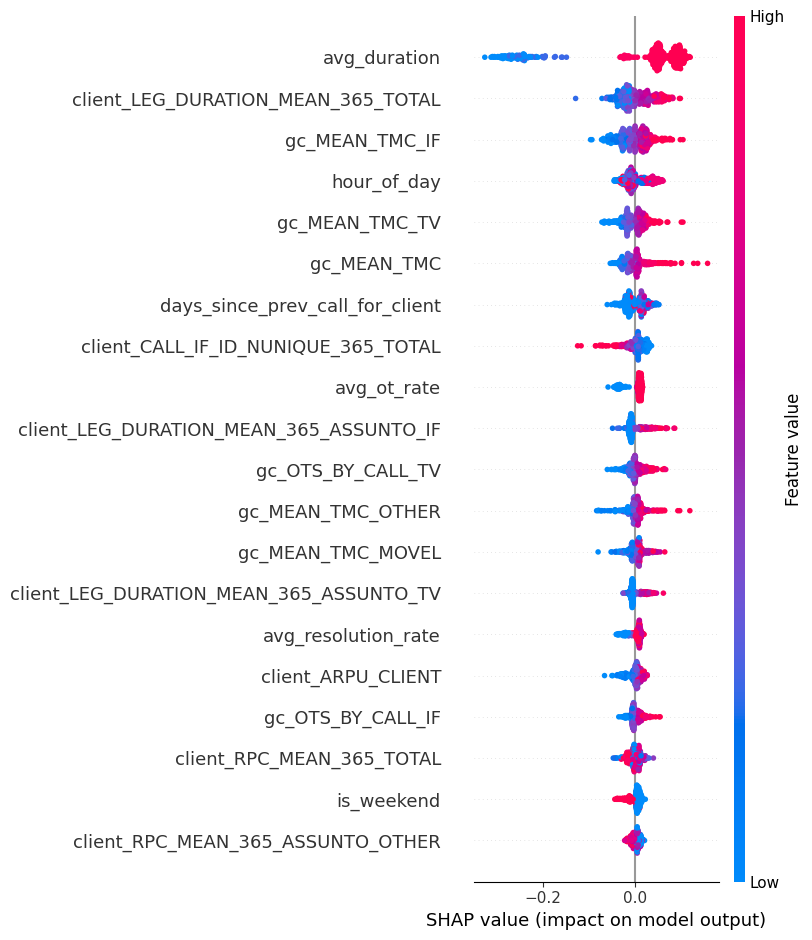

/tmp/ipython-input-3047831371.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, plot_type="bar", show=True)


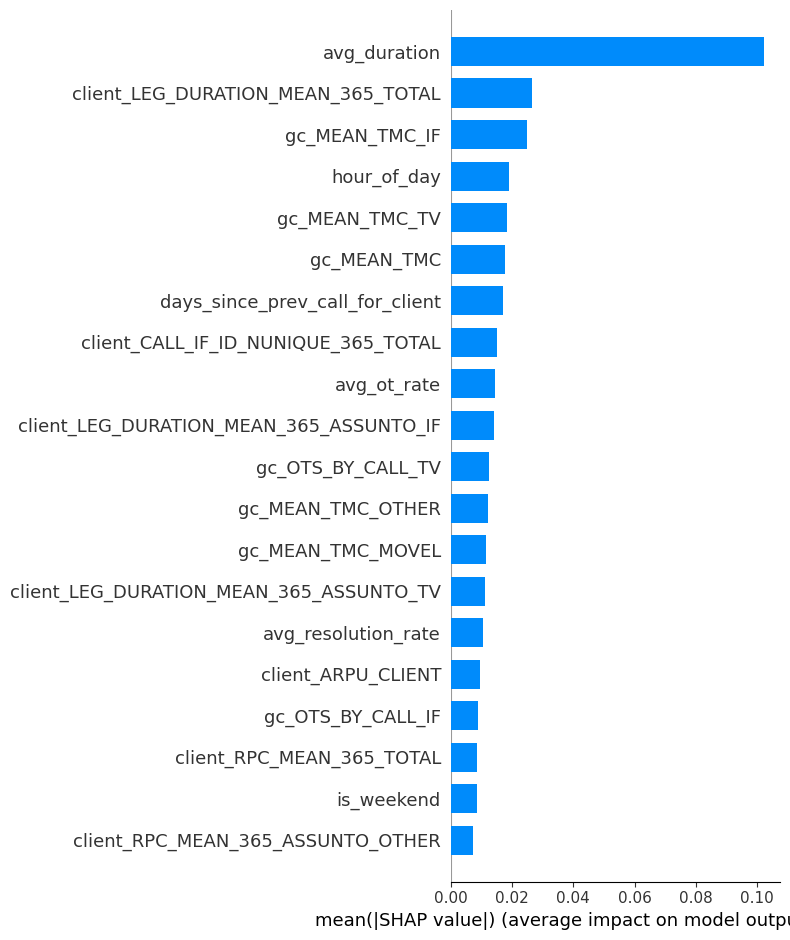

In [37]:
import shap

# initialize JS for notebook plots (won't break anything if not in notebook)
shap.initjs()

# 1. Use a sample for speed (XGBoost SHAP scales linearly; 500 is enough)
X_shap = X_test.sample(500, random_state=42)

# 2. Build SHAP TreeExplainer using your trained best_model
explainer = shap.TreeExplainer(best_model_xgb)

# 3. Compute SHAP values (log-space predictions because your model predicts log-cost)
shap_values = explainer.shap_values(X_shap)

# 4. Summary (beeswarm) plot — GLOBAL FEATURE IMPORTANCE
shap.summary_plot(shap_values, X_shap, show=True)

# 5.Bar plot
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=True)


## <a id='toc3_3_'></a>[Neural Network](#toc0_)

In [38]:
# ====== MLP for log-cost regression (Keras only) ======
import numpy as np
import pandas as pd
import math
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

rng_seed = 42

# ---------- Data ----------
df = final_df.copy()

# final_cost = log(cost in €) from ILR
y = df["final_cost"].astype(float)
X = df.drop(columns=["final_cost"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rng_seed
)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train, y_train, test_size=0.2, random_state=rng_seed
)

# ---------- Scale numerics ----------
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_va_s = scaler.transform(X_va)
X_te_s = scaler.transform(X_test)


def print_metrics(y_true_log, y_pred_log, label="VAL"):
    # log-space
    rmse_log = math.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log  = mean_absolute_error(y_true_log, y_pred_log)
    r2_log   = r2_score(y_true_log, y_pred_log)

    # original euro scale (using exp, not expm1)
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"[{label}]  LOG:  RMSE={rmse_log:.4f}  MAE={mae_log:.4f}  R2={r2_log:.4f}")
    print(f"[{label}] EURO: RMSE={rmse:.2f}   MAE={mae:.2f}   R2={r2:.4f}")


# ---------- Keras MLP model ----------
tf.random.set_seed(rng_seed)
np.random.seed(rng_seed)

l2_reg = regularizers.l2(1e-4)  # weight decay

inp = keras.Input(shape=(X_tr_s.shape[1],), name="num_in")

# Input normalisation
x = layers.BatchNormalization()(inp)

# Hidden block 1
x = layers.Dense(128, activation="swish", kernel_regularizer=l2_reg)(x)
x = layers.Dropout(0.2)(x)

# Hidden block 2
x = layers.Dense(128, activation="swish", kernel_regularizer=l2_reg)(x)
x = layers.Dropout(0.2)(x)

# Hidden block 3
x = layers.Dense(64, activation="swish", kernel_regularizer=l2_reg)(x)
x = layers.Dropout(0.2)(x)

# Hidden block 4
x = layers.Dense(32, activation="swish", kernel_regularizer=l2_reg)(x)

# Linear output for log-cost
out = layers.Dense(1, activation=None, kernel_regularizer=l2_reg, name="y_reg")(x)

model = keras.Model(inp, out)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="mse"
)

cb = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )
]

batch_size = min(512, max(32, X_tr_s.shape[0] // 16))

history = model.fit(
    X_tr_s, y_tr,
    validation_data=(X_va_s, y_va),
    epochs=200,
    batch_size=batch_size,
    verbose=0,
    callbacks=cb
)

# ---------- Basic metrics ----------
y_va_pred = model.predict(X_va_s, verbose=0).ravel()
y_te_pred = model.predict(X_te_s, verbose=0).ravel()

print_metrics(y_va, y_va_pred, label="VAL")
print_metrics(y_test, y_te_pred, label="TEST")


# ---------- Unified predict in log-space ----------
def predict_log(X_s):
    # Only Keras model is used
    return model.predict(X_s, verbose=0).ravel()


y_score = predict_log(X_te_s)

# Use same train subset used for NN training for Duan smearing if needed
X_tr_s_full = X_tr_s
y_tr_full   = y_tr.to_numpy()
yhat_log_tr = predict_log(X_tr_s_full)


[VAL]  LOG:  RMSE=0.6936  MAE=0.5608  R2=0.1037
[VAL] EURO: RMSE=9.12   MAE=6.35   R2=0.0072
[TEST]  LOG:  RMSE=0.6913  MAE=0.5586  R2=0.1049
[TEST] EURO: RMSE=9.04   MAE=6.30   R2=0.0087


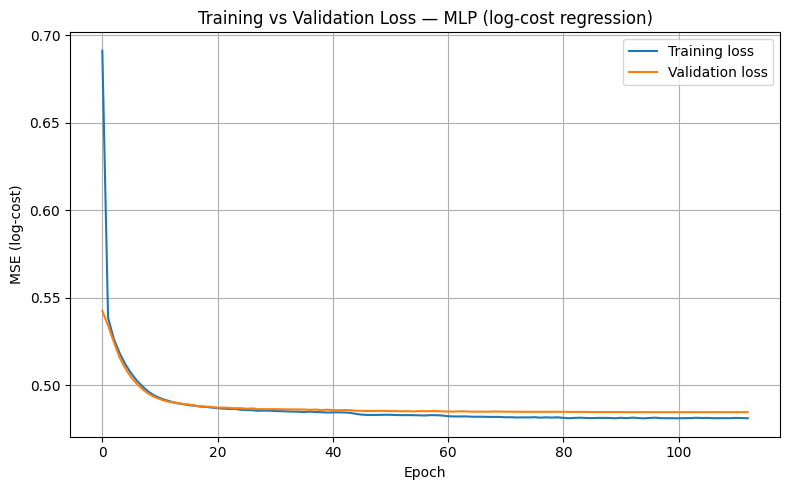

In [39]:
import matplotlib.pyplot as plt

# --------- Plot training vs validation loss ----------
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (log-cost)")
plt.title("Training vs Validation Loss — MLP (log-cost regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# --- Log-space metrics ---
print("R2_log:",   r2_score(y_test, y_score))
print("RMSE_log:", np.sqrt(mean_squared_error(y_test, y_score)))

# --- Naive back-transform to euros ---
y_true_eur = np.exp(y_test.to_numpy())
y_pred_eur = np.exp(y_score)
print("\nR² in euros (naive exp):")
print("R2_orig_naive:", r2_score(y_true_eur, y_pred_eur))

# --- Duan smearing ---
smear = float(np.mean(np.exp(y_tr_full - yhat_log_tr)))
y_pred_bc = y_pred_eur * smear
print("\nR²/MAE/RMSE in euros with Duan smearing:")
print("R2_orig_smear:",  r2_score(y_true_eur, y_pred_bc))
print("MAE_orig_smear:", mean_absolute_error(y_true_eur, y_pred_bc))
print("RMSE_orig_smear:", np.sqrt(mean_squared_error(y_true_eur, y_pred_bc)))

# --- Ranking metrics ---
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import roc_auc_score, average_precision_score, ndcg_score

print("\nRanking metrics")
rho,  _ = spearmanr(y_score, y_test)
tau,  _ = kendalltau(y_score, y_test)
print(f"- Spearman ρ: {rho:.3f}")
print(f"- Kendall  τ: {tau:.3f}")

q10 = np.quantile(y_true_eur, 0.10)
y_bottom = (y_true_eur <= q10).astype(int)
auc = roc_auc_score(y_bottom, -y_score)
ap  = average_precision_score(y_bottom, -y_score)
print(f"- AUC (bottom 10%): {auc:.3f}")
print(f"- AP  (bottom 10%): {ap:.3f}")

rng = np.random.default_rng(42)
n = len(y_score)
m = min(10_000, max(1000, n // 2))
i = rng.integers(0, n, size=m)
j = rng.integers(0, n, size=m)
pairwise_acc = (
    ((y_test.values[i] > y_test.values[j]) & (y_score[i] > y_score[j])) |
    ((y_test.values[i] < y_test.values[j]) & (y_score[i] < y_score[j]))
).mean()
print(f"- Pairwise ranking accuracy: {pairwise_acc:.2%}")


R2_log: 0.10489147717328551
RMSE_log: 0.6912625798059169

R² in euros (naive exp):
R2_orig_naive: 0.00867185837572182

R²/MAE/RMSE in euros with Duan smearing:
R2_orig_smear: 0.08831595035750284
MAE_orig_smear: 6.777805062630466
RMSE_orig_smear: 8.673117918597438

Ranking metrics
- Spearman ρ: 0.319
- Kendall  τ: 0.215
- AUC (bottom 10%): 0.712
- AP  (bottom 10%): 0.260
- Pairwise ranking accuracy: 60.49%


  0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipython-input-1283604218.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_arr, X_te_sample, feature_names=feature_names, plot_type="bar")


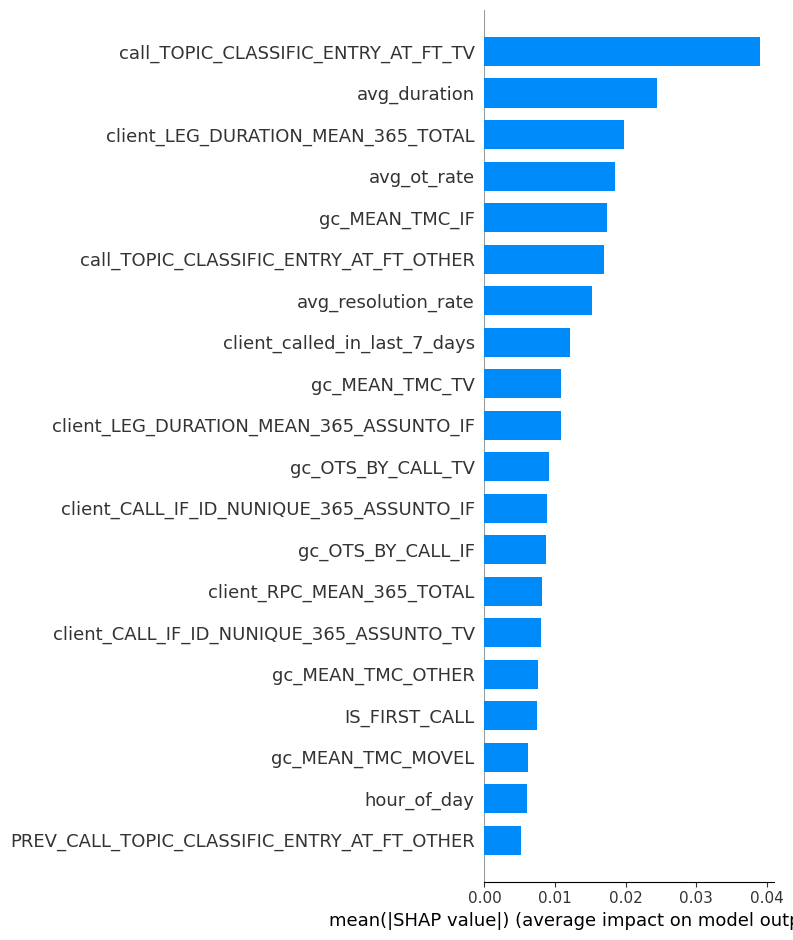

/tmp/ipython-input-1283604218.py:40: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_arr, X_te_sample, feature_names=feature_names)


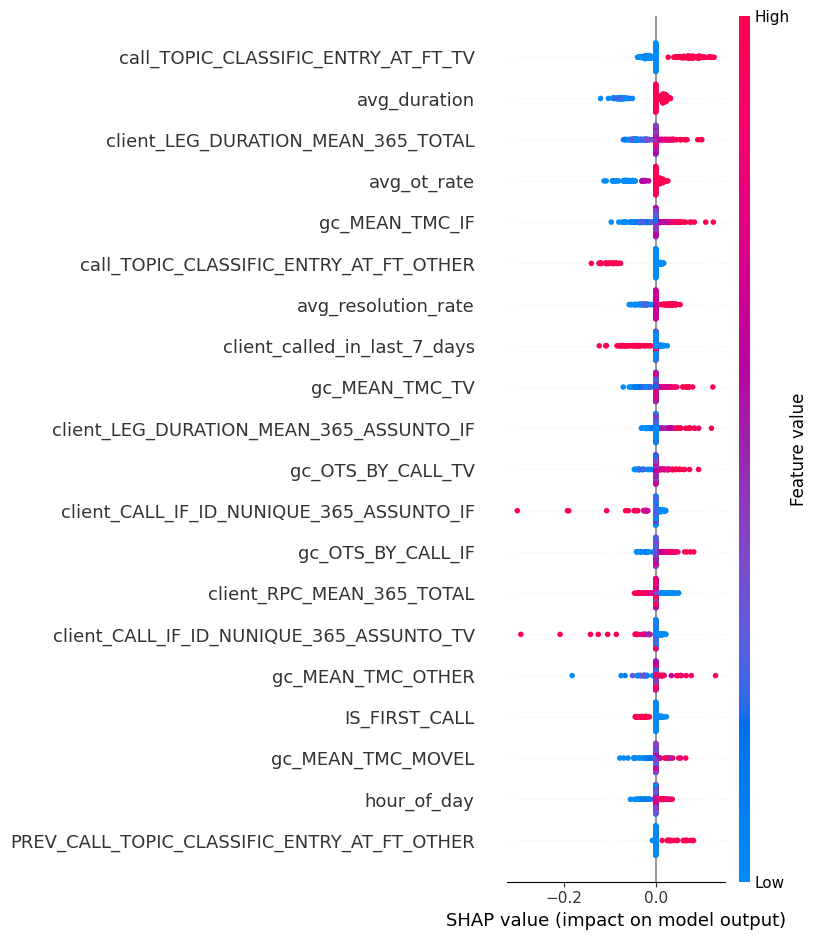

In [41]:
# SHAP values for Keras MLP
import shap
import numpy as np

shap.initjs()

# ---- 1. Summarise background using KMeans ----
K = 30  # number of cluster centroids; 20–50 is standard for tabular regressions
background = shap.kmeans(X_tr_s, K)

# ---- 2. Define prediction wrapper ----
def model_predict_logcost(X_batch):
    return model.predict(X_batch, verbose=0).ravel()

# ---- 3. Create Kernel SHAP explainer ----
explainer = shap.KernelExplainer(model_predict_logcost, background)

# ---- 4. Subsample test set for SHAP estimation ----
test_size = min(200, X_te_s.shape[0])  # 200 is plenty
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_te_s.shape[0], size=test_size, replace=False)
X_te_sample = X_te_s[sample_idx]

# ---- 5. Compute SHAP values (log-cost scale) ----
shap_values = explainer.shap_values(X_te_sample)

# Unpack if returned as list
if isinstance(shap_values, list):
    shap_values_arr = shap_values[0]
else:
    shap_values_arr = shap_values

# ---- 6. Plots ----
feature_names = X_test.columns

# Global importance
shap.summary_plot(shap_values_arr, X_te_sample, feature_names=feature_names, plot_type="bar")

# Beeswarm
shap.summary_plot(shap_values_arr, X_te_sample, feature_names=feature_names)

# <a id='toc4_'></a>[DEMO](#toc0_)

In [ ]:
df_for_demo.head()

,call_Column1,call_LEG_IF_ID,call_PERSON_ID,PERSON_SK,call_CALL_IF_ID,call_GROUP_KEY,RESOURCE_KEY,call_NR_RPC_0,call_NR_RPC_1,call_NR_INCIDENTS_PER_LEG,...,day_of_week,is_weekend,weekday_or_weekend_str,hour_of_day,time_of_day_str,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT,avg_duration,avg_resolution_rate,avg_ot_rate,Predicted_FTR_BASELINE
0,693119,8464046329,0S/WP6CbM730eF/9HQRkBY8mQbz6hp5kqKLj+Z1QszxE=,0K/zAFzNNbDThGL6zBqHU9wAkcJHtmOK3mg7pkJ94p+c=,1731747625,631410001,11741170013,1.0,0.0,1.0,...,1,0,Weekday,8,Morning,NaN,985.872062,0.143321,0.029764,0
1,632503,8464267869,0EfQa6yf84/6c/yePV8rXdjIRJ53s2d5psyWPqGBOgaA=,0dprrzD5IhbFa1xdn9KfGvYI9LBRs+c/4/sn2qY/tz8U=,1731781743,631410001,11741170013,1.0,0.0,1.0,...,1,0,Weekday,10,Morning,NaN,1029.833972,0.158994,0.002568,0
2,655329,8464477041,0LMh52DVtn6ntNerhZLKIa/8bW1kOwHRhKvMCBS4XLcE=,0MrLgtZPFCvdfReKaPKV2OG4G3FsvWFLvynPcQI4p848=,1731814533,631410001,11741170013,0.0,1.0,1.0,...,1,0,Weekday,10,Morning,NaN,1181.417774,0.175122,0.222987,0
3,320865,8464570641,0TjgNugpUpEwcD/JYxkbPDerB5oHqxverdEnzEIwojHU=,0mFGMIaF22Ndc02butKRd26YciZ76vq38rOcyD5PpKcE=,1731831081,631410001,11741170013,0.0,1.0,1.0,...,1,0,Weekday,10,Morning,NaN,1175.801916,0.192466,0.222782,0
4,503754,8464613169,0Pkt5bCUNkwGeQLUERqhxZcO9+9ixfSB4+DjpcJqF5S8=,0AgnlhnrDQ3FMbfhktP10JaAmEiGA5k5RjG/oesYjPgc=,1731835337,631410001,11741170013,2.0,0.0,2.0,...,1,0,Weekday,11,Morning,NaN,1181.417774,0.175122,0.222987,1


In [ ]:
# Start from raw df
df_raw = df_for_demo.copy()

# Categorical columns to one-hot encode
categorical_cols = ["call_TOPIC_CLASSIFIC_ENTRY_AT_FT",
                    "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT"]

# ID columns we want to KEEP (not features, but needed for the demo)
id_cols = ["PERSON_SK", "RESOURCE_KEY"]

# 1) One-hot encode the categorical columns on the full df
df_encoded = pd.get_dummies(df_raw, columns=categorical_cols, drop_first=True)

# 2) Drop non-ID object columns (strings we don't need as features)
obj_cols = df_encoded.select_dtypes(include="object").columns
cols_to_drop = [c for c in obj_cols if c not in id_cols]

df_for_demo_encoded_final = df_encoded.drop(columns=cols_to_drop)

print("final_df created with shape:", df_for_demo_encoded_final.shape)
df_for_demo_encoded_final.head()

final_df created with shape: (1171429, 280)


,call_Column1,call_LEG_IF_ID,PERSON_SK,call_CALL_IF_ID,call_GROUP_KEY,RESOURCE_KEY,call_NR_RPC_0,call_NR_RPC_1,call_NR_INCIDENTS_PER_LEG,call_CALL_START_TIME_DAT,...,avg_ot_rate,Predicted_FTR_BASELINE,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF
0,693119,8464046329,0K/zAFzNNbDThGL6zBqHU9wAkcJHtmOK3mg7pkJ94p+c=,1731747625,631410001,11741170013,1.0,0.0,1.0,2024-01-02 08:23:19,...,0.029764,0,False,True,False,False,False,False,False,False
1,632503,8464267869,0dprrzD5IhbFa1xdn9KfGvYI9LBRs+c/4/sn2qY/tz8U=,1731781743,631410001,11741170013,1.0,0.0,1.0,2024-01-02 10:01:19,...,0.002568,0,True,False,False,False,False,False,False,False
2,655329,8464477041,0MrLgtZPFCvdfReKaPKV2OG4G3FsvWFLvynPcQI4p848=,1731814533,631410001,11741170013,0.0,1.0,1.0,2024-01-02 10:28:08,...,0.222987,0,False,False,True,False,False,False,False,False
3,320865,8464570641,0mFGMIaF22Ndc02butKRd26YciZ76vq38rOcyD5PpKcE=,1731831081,631410001,11741170013,0.0,1.0,1.0,2024-01-02 10:58:29,...,0.222782,0,False,False,False,False,False,False,False,False
4,503754,8464613169,0AgnlhnrDQ3FMbfhktP10JaAmEiGA5k5RjG/oesYjPgc=,1731835337,631410001,11741170013,2.0,0.0,2.0,2024-01-02 11:18:01,...,0.222987,1,False,False,True,False,False,False,False,False


In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

# ======================================================
# 0. BASE DATAFRAME FOR THE DEMO
# ======================================================
full_df = df_for_demo_encoded_final.copy()

# ======================================================
# 1. CLIENT, GC AND CALL TABLES
# ======================================================

# Identify client- and GC-level columns
client_cols = [c for c in full_df.columns if c.startswith("client_")]
gc_cols     = [c for c in full_df.columns if c.startswith("gc_")]

# Call/context columns we may use for the scenario
call_cols = [
    "call_TOPIC_CLASSIFIC_ENTRY_AT_FT",
    "days_since_prev_call_for_client",
    "client_called_in_last_7_days",
    "days_since_last_call_gc",
    "is_weekend",
    "hour_of_day",
    "IS_FIRST_CALL",
    "CNT_LVL2_ADESÃO/ALTERAÇÃO",
    "CNT_LVL2_BOX",
    "CNT_LVL2_CARTÃO SIM/ESIM/TWIN",
    "CNT_LVL2_INTERNET FIXA",
    "CNT_LVL2_MAIS INFORMAÇÕES",
    "CNT_LVL2_OUTROS",
    "CNT_LVL2_SEM VOZ DE CLIENTE",
    "CNT_LVL2_TELEVISÃO",
    "CNT_LVL2_VOZ FIXA",
    "PROP_LVL2_ADESÃO/ALTERAÇÃO",
    "PROP_LVL2_BOX",
    "PROP_LVL2_CARTÃO SIM/ESIM/TWIN",
    "PROP_LVL2_INTERNET FIXA",
    "PROP_LVL2_MAIS INFORMAÇÕES",
    "PROP_LVL2_OUTROS",
    "PROP_LVL2_SEM VOZ DE CLIENTE",
    "PROP_LVL2_TELEVISÃO",
    "PROP_LVL2_VOZ FIXA",
    "LAG1_LVL2_ADESÃO/ALTERAÇÃO",
    "LAG1_LVL2_BOX",
    "LAG1_LVL2_CARTÃO SIM/ESIM/TWIN",
    "LAG1_LVL2_INTERNET FIXA",
    "LAG1_LVL2_MAIS INFORMAÇÕES",
    "LAG1_LVL2_OUTROS",
    "LAG1_LVL2_SEM VOZ DE CLIENTE",
    "LAG1_LVL2_TELEVISÃO",
    "LAG1_LVL2_VOZ FIXA",
    "avg_duration",
    "avg_resolution_rate",
    "Predicted_FTR_BASELINE",
    "avg_ot_rate",
    "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT",
]

# Keep only those that actually exist
call_cols = [c for c in call_cols if c in full_df.columns]

# Add unique identifiers
client_cols = ["PERSON_SK"] + client_cols
gc_cols     = ["RESOURCE_KEY"] + gc_cols

clients_df = (
    full_df[client_cols]
    .drop_duplicates(subset="PERSON_SK")
    .reset_index(drop=True)
)
gcs_df = (
    full_df[gc_cols]
    .drop_duplicates(subset="RESOURCE_KEY")
    .reset_index(drop=True)
)
call_df = (
    full_df[call_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("clients_df shape:", clients_df.shape)
print("gcs_df shape:", gcs_df.shape)
print("call_df shape:", call_df.shape)

# ======================================================
# 2. GET THE TRUE FEATURE LIST FROM THE TRAINED MODEL
# ======================================================

# This is the *canonical* list of features XGBoost expects
model_feature_cols = list(best_model_xgb.get_booster().feature_names)

print("\nNumber of model features:", len(model_feature_cols))

# Sanity check: what is missing in df_for_demo?
missing_in_df = [c for c in model_feature_cols if c not in full_df.columns]
if missing_in_df:
    print("WARNING: These model features are not found in df_for_demo:", missing_in_df)

# Helper lists by level
client_feature_cols = [c for c in model_feature_cols if c.startswith("client_")]
gc_feature_cols     = [c for c in model_feature_cols if c.startswith("gc_")]
call_feature_cols   = [
    c for c in model_feature_cols
    if c not in client_feature_cols and c not in gc_feature_cols
]

# ======================================================
# 3. OPTIONAL: PREDICT KWARGS (EARLY STOPPING)
# ======================================================
predict_kwargs = {}
if hasattr(best_model_xgb, "best_iteration") and best_model_xgb.best_iteration is not None:
    predict_kwargs["iteration_range"] = (0, best_model_xgb.best_iteration + 1)

# ======================================================
# 4. DEMO FUNCTION
# ======================================================

def build_matching_scenario(num_candidates=100, random_state=None):
    """
    1. Pick a random historical call (client + call context) from full_df
    2. Combine that with N random GCs from gcs_df
    3. Predict log-cost and euro cost with best_model_xgb
    4. Return:
       - base_call (the sampled call row)
       - candidates_df (all GC combinations with predictions)
       - best_row (the chosen GC with lowest predicted cost, random tie-break)
    """

    # --- 1. Random base call (has PERSON_SK and call context) ---
    base_call = full_df.sample(n=1, random_state=random_state).iloc[0]

    person_sk = base_call["PERSON_SK"]

    # Client row
    client_row = clients_df.loc[clients_df["PERSON_SK"] == person_sk]
    if client_row.empty:
        client_values = base_call
    else:
        client_values = client_row.iloc[0]

    # --- 2. Sample GCs ---
    n_candidates = min(num_candidates, len(gcs_df))
    gcs_sample = gcs_df.sample(n=n_candidates, random_state=random_state)

    rows = []

    for _, gc_row in gcs_sample.iterrows():
        fv = {}

        # Build one feature vector with EXACTLY the model's columns
        for col in model_feature_cols:
            if col in gc_feature_cols and col in gc_row.index:
                fv[col] = gc_row[col]                      # GC-level
            elif col in client_feature_cols and col in client_values.index:
                fv[col] = client_values[col]               # client-level
            elif col in call_feature_cols and col in base_call.index:
                fv[col] = base_call[col]                   # call/context-level
            else:
                fv[col] = 0                                # unseen / missing indicator

        # Keep GC identifier for interpretation (not used as feature)
        fv["RESOURCE_KEY"] = gc_row["RESOURCE_KEY"]
        rows.append(fv)

    candidates_df = pd.DataFrame(rows)

    # --- 3. Ensure dtypes are numeric where needed ---
    # (Usually model_feature_cols are already numeric; but just in case:)
    for col in model_feature_cols:
        if candidates_df[col].dtype == "object":
            candidates_df[col] = pd.to_numeric(candidates_df[col], errors="coerce").fillna(0)

    # --- 4. Predict with XGBoost using EXACT feature order ---
    X_demo = candidates_df[model_feature_cols]
    y_pred_log = best_model_xgb.predict(X_demo, **predict_kwargs)
    candidates_df["pred_log_cost"] = y_pred_log
    candidates_df["pred_cost_eur"] = np.exp(y_pred_log)

    # --- 5. Select best GC (lowest predicted cost, random tie-break) ---
    min_cost = candidates_df["pred_cost_eur"].min()
    best_rows = candidates_df[candidates_df["pred_cost_eur"] == min_cost]
    best_row = best_rows.sample(n=1, random_state=random_state).iloc[0]

    return base_call, candidates_df, best_row

# ======================================================
# 5. RUN THE DEMO
# ======================================================

print("\n============================")
print("Running demo scenario...")
print("============================")

base_call, candidates_df, best_gc = build_matching_scenario(
    num_candidates=100,
    random_state=42
)

print("\n=== Random incoming call (client + call context) ===")
cols_to_show = [
    c for c in [
        "PERSON_SK",
        "call_TOPIC_CLASSIFIC_ENTRY_AT_FT",
        "hour_of_day",
        "is_weekend",
        "IS_FIRST_CALL",
    ]
    if c in base_call.index
]
print(base_call[cols_to_show])

print("\n=== Best GC selected by model ===")
print(
    best_gc[
        [
            "RESOURCE_KEY",
            "pred_log_cost",
            "pred_cost_eur",
        ]
    ]
)

print("\nTop 5 cheapest GCs:")
display(
    candidates_df.sort_values("pred_cost_eur").head(5)[
        ["RESOURCE_KEY", "pred_cost_eur", "pred_log_cost"]
    ]
)


clients_df shape: (561641, 166)
gcs_df shape: (652, 43)
call_df shape: (349465, 37)

Number of model features: 117

Running demo scenario...

=== Random incoming call (client + call context) ===
PERSON_SK        0QSsRkOd34qxIQTJTAmDJ2pFEpXwaydVJBf4LcGyCZf8=
hour_of_day                                                 14
is_weekend                                                   0
IS_FIRST_CALL                                                0
Name: 934455, dtype: object

=== Best GC selected by model ===
RESOURCE_KEY     11942180012.0
pred_log_cost         2.053138
pred_cost_eur         7.792319
Name: 29, dtype: object

Top 5 cheapest GCs:


,RESOURCE_KEY,pred_cost_eur,pred_log_cost
29,1.194218e+10,7.792319,2.053138
13,1.340510e+10,7.924796,2.069997
21,1.336710e+10,7.992980,2.078564
72,1.329910e+10,7.998068,2.079200
4,1.337512e+10,8.626880,2.154883


# <a id='toc5_'></a>[SIMULATION](#toc0_)

In [ ]:
import numpy as np
import pandas as pd

def build_scenarios_table_e2e(
    num_calls=1000,
    num_candidates=100,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    # 1) Sample calls
    sampled_calls = full_df.sample(n=num_calls, random_state=random_state)
    sampled_indices = sampled_calls.index.tolist()

    rows = []

    for scenario_id, idx in enumerate(sampled_indices):
        base_call = full_df.loc[idx]
        person_sk = base_call["PERSON_SK"]

        # Client row
        client_row = clients_df.loc[clients_df["PERSON_SK"] == person_sk]
        if client_row.empty:
            client_values = base_call
        else:
            client_values = client_row.iloc[0]

        # Sample GCs for this call
        n_cand = min(num_candidates, len(gcs_df))
        # Different random seed per scenario
        gcs_sample = gcs_df.sample(
            n=n_cand,
            random_state=int(rng.integers(0, 1_000_000))
        )

        for _, gc_row in gcs_sample.iterrows():
            fv = {}
            # Build feature vector exactly like in your demo
            for col in model_feature_cols:
                if col in gc_feature_cols and col in gc_row.index:
                    fv[col] = gc_row[col]                      # GC-level
                elif col in client_feature_cols and col in client_values.index:
                    fv[col] = client_values[col]               # client-level
                elif col in call_feature_cols and col in base_call.index:
                    fv[col] = base_call[col]                   # call/context-level
                else:
                    fv[col] = 0                                # missing → 0

            fv["RESOURCE_KEY"] = gc_row["RESOURCE_KEY"]
            fv["scenario_id"] = scenario_id   # identifies the call
            rows.append(fv)

    scenarios_df = pd.DataFrame(rows)
    return scenarios_df


In [ ]:
scenarios_df_e2e = build_scenarios_table_e2e(
    num_calls=2000,
    num_candidates=50,
    random_state=42
)

print(scenarios_df_e2e.shape)
scenarios_df_e2e.head()

In [ ]:
# Ensure feature order
X_e2e = scenarios_df_e2e[model_feature_cols].copy()

# Just in case: convert objects to numeric
for col in X_e2e.columns:
    if X_e2e[col].dtype == "object":
        X_e2e[col] = pd.to_numeric(X_e2e[col], errors="coerce").fillna(0)

# Predict log-cost and euro cost
y_pred_log = best_model_xgb.predict(X_e2e, **predict_kwargs)
scenarios_df_e2e["pred_log_cost_e2e"] = y_pred_log
scenarios_df_e2e["pred_cost_eur_e2e"] = np.exp(y_pred_log)

# For each scenario (call), pick the GC with minimum predicted cost
idx_min = scenarios_df_e2e.groupby("scenario_id")["pred_cost_eur_e2e"].idxmin()
best_per_call_e2e = scenarios_df_e2e.loc[idx_min].copy()

# Aggregate
total_cost_e2e = best_per_call_e2e["pred_cost_eur_e2e"].sum()
avg_cost_per_call_e2e = best_per_call_e2e["pred_cost_eur_e2e"].mean()

print(f"Number of simulated calls: {best_per_call_e2e.shape[0]}")
print(f"Total predicted cost (E2E): {total_cost_e2e:,.2f} €")
print(f"Average predicted cost per call (E2E): {avg_cost_per_call_e2e:,.2f} €")
